<a href="https://colab.research.google.com/github/DIFACQUIM/antiviral_ML/blob/main/2_curation_standardization/02_Curation_and_standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **Packages**: installation and importation
---


In [ ]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
import numpy as np
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
        from tqdm import tqdm
        pbar.update(20)
        !pip install matplotlib, seaborn, pandas
        '''Librerías gráficas'''
        import matplotlib.pyplot as plt
        from IPython.display import display, SVG, HTML
        import seaborn as sns
        !pip install rdkit
        from rdkit import Chem
        from rdkit.Chem import Draw, Descriptors
        from rdkit.Chem.rdmolops import RemoveStereochemistry

        pbar.update(40)
        import pandas as pd
        %config Completer.use_jedi = False
        import json
        !pip install chembl_webresource_client
        from chembl_webresource_client.new_client import new_client
        from chembl_webresource_client.utils import utils
        from pathlib import Path

        !pip install molvs
        !pip install datamol
        import datamol as dm
        from matplotlib_venn import venn3, venn3_circles, venn3_unweighted
        dm.disable_rdkit_log()
        from molvs.standardize import Standardizer
        from molvs.charge import Uncharger, Reionizer
        from molvs.fragment import LargestFragmentChooser
        from molvs.tautomer import TautomerCanonicalizer
        from rdkit.Chem.rdmolops import GetFormalCharge, RemoveStereochemistry
        from rdkit import RDConfig
        from rdkit import Chem, DataStructs
        from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors, Descriptors3D, rdMolDescriptors, Scaffolds,MACCSkeys
        from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
        from rdkit.DataManip.Metric.rdMetricMatrixCalc import GetTanimotoSimMat, GetTanimotoDistMat
        PandasTools.RenderImagesInAllDataFrames(images=True)
        from rdkit.Chem.Draw import IPythonConsole
        from google.colab import drive
        drive.mount('/content/drive')
        pbar.update(10)

  0%|          | 0/100 [00:00<?, ?it/s]

---

# **1. BD curing of antiviral compounds:**


---

In [ ]:
path_dataframe= '/content/drive/MyDrive/Proyectos/Chemo-viral_space_of_natural_products/Files/DataFrames/'
targets=pd.read_excel(path_dataframe+'1_viraltargets_from_ChEMBL.xlsx', index_col=0)
print(len(targets))
viral_compounds=pd.read_excel(path_dataframe+'2_compounds_against_viraltargets_from_ChEMBL.xlsx', index_col=0)
print(len(viral_compounds))
reports_per_targets = pd.read_excel(path_dataframe+'3_reports_per_targets.xlsx', index_col=0)
print(len(reports_per_targets))

529
75994
530


In [ ]:
viral_compounds_with_targets_info = pd.merge(viral_compounds,targets, on= 'target_chembl_id', how='left')
print(f'Amount of reports: {len(viral_compounds_with_targets_info)}')
viral_compounds_with_targets_info[0:2]

Amount of reports: 75994


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_pref_name,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id
0,72419,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(O)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '18.53', 'le': '0.37', 'lle': '8.47', ...",CHEMBL291345,nM,4000.0,...,Neuraminidase,M,4.000000e-06,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044
1,72420,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(NC(=N)N)C=C(C(=O)O)OC1C(O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '27.08', 'le': '0.53', 'lle': '12.58',...",CHEMBL157939,nM,1.0,...,Neuraminidase,M,1.000000e-09,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044


In [ ]:
viral_compounds_with_targets_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75994 entries, 0 to 75993
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   activity_id         75994 non-null  int64  
 1   assay_chembl_id     75994 non-null  object 
 2   assay_description   75994 non-null  object 
 3   canonical_smiles    75904 non-null  object 
 4   document_chembl_id  75994 non-null  object 
 5   document_journal    70058 non-null  object 
 6   ligand_efficiency   43888 non-null  object 
 7   molecule_chembl_id  75994 non-null  object 
 8   standard_units      69758 non-null  object 
 9   standard_value      69103 non-null  float64
 10  target_chembl_id    75994 non-null  object 
 11  target_organism     75994 non-null  object 
 12  target_pref_name    75994 non-null  object 
 13  units               65332 non-null  object 
 14  value               69103 non-null  float64
 15  cross_references    75994 non-null  object 
 16  orga

In [ ]:
nan_values_standard_units = viral_compounds_with_targets_info['standard_value'].isna()
nan_rows_standard_units = viral_compounds_with_targets_info[nan_values_standard_units]
print(len(nan_rows_standard_units))

nan_values_units = viral_compounds_with_targets_info['value'].isna()
nan_rows_units = viral_compounds_with_targets_info[nan_values_standard_units]
print(len(nan_rows_units))
#Nan standard_units: 6236
#Nan standard_value: 62689136

6891
6891


In [ ]:
viral_compounds_with_targets_info = viral_compounds_with_targets_info.dropna(subset=['standard_value', 'standard_units'])
print(len(viral_compounds_with_targets_info))
#There are a total of 67622 entries with IC50 values and their respective units

67622


## **1.1 Units**

Units to preserve:	nM, uM, mM, M, µM, nm


In [ ]:
def get_unique_units(df, column):
    # Initialize an empty dictionary to store unique units and their counts
    unique_units_dict = {}
    for units in df[column]:
        # Skip NaN values
        if pd.notnull(units):
            for unit in units.split(','):
                # Strip leading/trailing whitespace
                unit = unit.strip()
                # Add unit to dictionary and increment count
                unique_units_dict[unit] = unique_units_dict.get(unit, 0) + 1
    # Convert the dictionary to a DataFrame
    unique_units_df = pd.DataFrame(list(unique_units_dict.items()), columns=['Unit', 'Count'])
    return unique_units_df

In [ ]:
# Get unique units from the standard_units column
unique_units_df = get_unique_units(viral_compounds_with_targets_info, 'standard_units')
unique_units_df = unique_units_df.sort_values(by='Count', ascending=False).reset_index(drop=True)
units = unique_units_df['Unit'].unique()

print(f"Cantidad total de reportes: {sum(unique_units_df['Count'])},\n Cantidad de unidades (std) diferentes: {len(unique_units_df)}")
print(units)
unique_units_df

Cantidad total de reportes: 67622,
 Cantidad de unidades (std) diferentes: 79
['nM' '%' 'uM' 'ug.mL-1' 'M-1 s-1' 'degrees C' 'ug ml-1' 's-1'
 'milli optical density/minute' '/s' 'M-1.s-1' '/M/s' 'hr' 'kJ/mol'
 'min-1' '/uM/s' 'kcal/mol' 'M-1 min-1' 'pM' 'kCal mol-1' 'mol/g'
 'M-1-s-1' '/uM/min' "10'-5OD/s" 'microM/min/mg' "10'-3/min" 'pmol/min'
 "10'6/min" '/min' '/s/microM' '10^4/M/s' "10'-4/s" "10'-2/microM/s"
 "10'4/M/s" '/min/M' '/mM/s' 'umol/mg/min' 'degree' 'uM/hr' "10'-5/s"
 '1/min' "10'6/M" 'nM/s' 'nmol/hr/microg' 'mM-1s-1' 'kDa' '10^2 uM'
 '10^3/M/s' 'mM' 'microM/microg/sec' '10^-5/nM/s' '10^-3/s' "10'5/s" '1/M'
 'cal/mol.K' "10'-2/s" 'Da' 'M' 'mM s-1' '10^4/M' 'nM/min' '10^-12M'
 "10'-6/M" '10^3/s' 'nm' '10^5/M/s' "10'-4umol/L" "10'6/M/s" 'M/s'
 '10^1 uM' "10'-9/M" "10'-8/s" '10^2/M/s' "10'3/M/s" 'ng/ml' "10'9/M"
 "10'11/M" "10'2/M/s" "10'-3/microM/s"]


,Unit,Count
0,nM,56513
1,%,7585
2,uM,1367
3,ug.mL-1,675
4,M-1 s-1,291
...,...,...
74,ng/ml,1
75,10'9/M,1
76,10'11/M,1
77,10'2/M/s,1


In [ ]:
units_to_conserve = ['nM','nm','uM', 'pM','mM','M','10^-12M','10^2 uM','10^1 uM', "10'-4umol/L" ]
viral_compounds_F_U = viral_compounds_with_targets_info[viral_compounds_with_targets_info['standard_units'].isin(units_to_conserve)].reset_index(drop=True)
print(len(viral_compounds_F_U))
print(viral_compounds_F_U['standard_units'].unique())
#58286 -->['nM' 'uM' 'mM' 'M' 'pM' 'nm']
#58290 -->['nM' "10'-4umol/L" 'uM' 'mM' 'M' 'pM' '10^2 uM' '10^1 uM']
#57913 --> ['nM' "10'-4umol/L" 'uM' 'mM' 'M' 'pM' '10^-12M' 'nm' '10^2 uM' '10^1 uM']

57913
['nM' "10'-4umol/L" 'uM' 'mM' 'M' 'pM' '10^-12M' 'nm' '10^2 uM' '10^1 uM']


## **1.2 Unit standardization and pIC50 generation**


In [ ]:
import numpy as np
# Function to convert IC50 to pIC50
def ic50_to_pic50(value, unit):
    try:
        if unit in 'pM':
            molar_value = value / 1e12  # Convert nM to M
            pic50 = -np.log10(molar_value)
        elif unit in ['nM', 'nm']:
            molar_value = value / 1e9  # Convert nM to M
            pic50 = -np.log10(molar_value)
        elif unit in ['uM', 'µM']:
            molar_value = value / 1e6  # Convert µM to M
            pic50 = -np.log10(molar_value)
        elif unit == 'mM':
            molar_value = value / 1e3  # Convert mM to M
            pic50 = -np.log10(molar_value)
        elif unit == 'M':
            molar_value = value  # M is already in M
            pic50 = -np.log10(molar_value)
        elif unit =='10^-12M':
            molar_value = value * 1e-12  # Convert 10^-12M to M
            pic50 = -np.log10(molar_value)
        elif unit =='10^2 uM':
            molar_value = value * 1e2 / 1e6  # Convert 10^2 µM to M
            pic50 = -np.log10(molar_value)
        elif unit =='10^1 uM':
            molar_value = value * 1e1 / 1e6  # Convert 10^1 µM to M
            pic50 = -np.log10(molar_value)
        elif unit =="10'-4umol/L":
            molar_value = value * 1e-4 / 1e6  # Convert 10^-4 µmol/L to M
            pic50 = -np.log10(molar_value)
        else:
            pic50 = np.nan  # Ignore non-IC50 values
    except ValueError:
        pic50 = np.nan  # Handle non-numeric values gracefully

    return pic50

In [ ]:
prueba=viral_compounds_F_U[8828:8836].copy()
prueba=prueba[['standard_value', 'standard_units']]
prueba.info()
prueba

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 8828 to 8835
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   standard_value  8 non-null      float64
 1   standard_units  8 non-null      object 
dtypes: float64(1), object(1)
memory usage: 260.0+ bytes


,standard_value,standard_units
8828,4000.000,nM
8829,0.070,uM
8830,0.012,uM
8831,0.004,uM
8832,0.816,uM
8833,1.506,uM
8834,3.000,uM
8835,0.015,uM


In [ ]:
# Apply the function to each row
prueba['pIC50'] = prueba.apply(lambda row: ic50_to_pic50(row['standard_value'], row['standard_units']), axis=1)
prueba

,standard_value,standard_units,pIC50
8828,4000.000,nM,5.397940
8829,0.070,uM,7.154902
8830,0.012,uM,7.920819
8831,0.004,uM,8.397940
8832,0.816,uM,6.088310
8833,1.506,uM,5.822175
8834,3.000,uM,5.522879
8835,0.015,uM,7.823909


In [ ]:
viral_compounds_F_U['pIC50'] = viral_compounds_F_U.apply(lambda row: ic50_to_pic50(row['standard_value'], row['standard_units']), axis=1)
print(len(viral_compounds_F_U))
viral_compounds_F_U[0:3]

<ipython-input-10-86bf297257fe>:10: RuntimeWarning: divide by zero encountered in log10
  pic50 = -np.log10(molar_value)


57913


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id,pIC50
0,72419,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(O)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '18.53', 'le': '0.37', 'lle': '8.47', ...",CHEMBL291345,nM,4000.0,...,M,4.000000e-06,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,5.39794
1,72420,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(NC(=N)N)C=C(C(=O)O)OC1C(O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '27.08', 'le': '0.53', 'lle': '12.58',...",CHEMBL157939,nM,1.0,...,M,1.000000e-09,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,9.00000
2,89474,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(N)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '25.49', 'le': '0.51', 'lle': '10.50',...",CHEMBL345693,nM,40.0,...,M,4.000000e-08,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,7.39794


## **1.3 Elimination of targets associated with bacteria, humans and other organisms:**

In [ ]:
#Celdas relacionadas con humano
filtered_df_human = viral_compounds_with_targets_info[viral_compounds_with_targets_info['target_organism'].str.contains('sapiens', case=True, na=False)]
filtered_df_human

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_pref_name,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id
70492,1183595,CHEMBL676955,Binding affinity for human fibroblast growth f...,O=C(CN(Cc1ccccc1)C(=O)C1OC(OS(=O)(=O)[O-])C(OS...,CHEMBL1147561,Bioorg Med Chem Lett,NaN,CHEMBL70718,nM,587000.0,...,Acidic fibroblast growth factor,uM,587.000,"[{'xref_id': 'P05230', 'xref_name': None, 'xre...",Homo sapiens,Acidic fibroblast growth factor,False,"[{'accession': 'P05230', 'component_descriptio...",SINGLE PROTEIN,9606
70493,1186241,CHEMBL676955,Binding affinity for human fibroblast growth f...,CC(C)(CC(=O)N(CCO[C@H]1O[C@@H](COS(=O)(=O)[O-]...,CHEMBL1147561,Bioorg Med Chem Lett,"{'bei': '3.36', 'le': None, 'lle': None, 'sei'...",CHEMBL3215307,nM,10000.0,...,Acidic fibroblast growth factor,uM,10.000,"[{'xref_id': 'P05230', 'xref_name': None, 'xre...",Homo sapiens,Acidic fibroblast growth factor,False,"[{'accession': 'P05230', 'component_descriptio...",SINGLE PROTEIN,9606
70494,1192807,CHEMBL676955,Binding affinity for human fibroblast growth f...,O=C(CN(Cc1ccccc1)C(=O)C1OC(OS(=O)(=O)[O-])C(OS...,CHEMBL1147561,Bioorg Med Chem Lett,NaN,CHEMBL70844,nM,104000.0,...,Acidic fibroblast growth factor,uM,104.000,"[{'xref_id': 'P05230', 'xref_name': None, 'xre...",Homo sapiens,Acidic fibroblast growth factor,False,"[{'accession': 'P05230', 'component_descriptio...",SINGLE PROTEIN,9606
70495,1194135,CHEMBL676955,Binding affinity for human fibroblast growth f...,O=C(CN(CCOS(=O)(=O)[O-])C(=O)C1OC(OS(=O)(=O)[O...,CHEMBL1147561,Bioorg Med Chem Lett,NaN,CHEMBL305519,nM,2340000.0,...,Acidic fibroblast growth factor,uM,2340.000,"[{'xref_id': 'P05230', 'xref_name': None, 'xre...",Homo sapiens,Acidic fibroblast growth factor,False,"[{'accession': 'P05230', 'component_descriptio...",SINGLE PROTEIN,9606
70496,1194137,CHEMBL676955,Binding affinity for human fibroblast growth f...,CO[C@H]1O[C@@H](COCC(=O)N(CC(=O)NC2CCCCC2)Cc2c...,CHEMBL1147561,Bioorg Med Chem Lett,NaN,CHEMBL3215305,nM,260000.0,...,Acidic fibroblast growth factor,uM,260.000,"[{'xref_id': 'P05230', 'xref_name': None, 'xre...",Homo sapiens,Acidic fibroblast growth factor,False,"[{'accession': 'P05230', 'component_descriptio...",SINGLE PROTEIN,9606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75989,25044193,CHEMBL5245446,Inhibition of NA+/K+ ATPase (unknown origin) a...,C[C@]12CC[C@H](O)CC1CCC1=C3CC[C@H](c4ccc(=O)oc...,CHEMBL5244231,Eur J Med Chem,"{'bei': '14.25', 'le': '0.27', 'lle': '0.06', ...",CHEMBL5267239,nM,5600.0,...,Sodium/potassium-transporting ATPase,uM,5.600,[],Homo sapiens,Sodium/potassium-transporting ATPase,False,"[{'accession': 'P05023', 'component_descriptio...",PROTEIN COMPLEX GROUP,9606
75990,25044194,CHEMBL5245446,Inhibition of NA+/K+ ATPase (unknown origin) a...,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,CHEMBL5244231,Eur J Med Chem,"{'bei': '19.81', 'le': '0.37', 'lle': '3.42', ...",CHEMBL399680,nM,22.0,...,Sodium/potassium-transporting ATPase,uM,0.022,[],Homo sapiens,Sodium/potassium-transporting ATPase,False,"[{'accession': 'P05023', 'component_descriptio...",PROTEIN COMPLEX GROUP,9606
75991,25044195,CHEMBL5245446,Inhibition of NA+/K+ ATPase (unknown origin) a...,C[C@]12CC[C@H](O)C[C@H]1CC[C@H]1C3=CC[C@H](c4c...,CHEMBL5244231,Eur J Med Chem,"{'bei': '11.56', 'le': '0.22', 'lle': '-1.97',...",CHEMBL5267626,nM,35800.0,...,Sodium/potassium-transporting ATPase,uM,35.800,[],Homo sapiens,Sodium/potassium-transporting ATPase,False,"[{'accession': 'P05023', 'component_descriptio...",PROTEIN COMPLEX GROUP,9606
75992,25044196,CHEMBL5245447,Inhibition of NA+/K+ ATPase (unknown origin) a...,C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...,CHEMBL5244231,Eur J Med Chem,"{'bei': '10.78', 'le': '0.20', 'lle': '0.17', ...",CHEMBL5285756,nM,70000.0,...,Sod

In [ ]:
#Cells asociated with bacteriias
filtered_df_bacteria = viral_compounds_with_targets_info[viral_compounds_with_targets_info['target_organism'].str.contains('bacte', case=False, na=False)]
filtered_df_bacteria

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_pref_name,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id
75055,14539307,CHEMBL3227814,Inhibition of Escherichia coli DHPS,COc1cc(OC)cc(OCCCNc2nc(N)nc(O)c2N=O)c1,CHEMBL3217444,Medchemcomm,"{'bei': '17.62', 'le': '0.34', 'lle': '4.09', ...",CHEMBL159139,nM,700.0,...,Bacterial dihydropteroate synthase,uM,0.70,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75056,15093160,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,Nc1nc2[nH]c(S)nc2c(=O)[nH]1,CHEMBL3352086,J Med Chem,"{'bei': '22.48', 'le': '0.47', 'lle': '4.60', ...",CHEMBL178006,nM,76200.0,...,Bacterial dihydropteroate synthase,uM,76.20,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75057,15093161,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,COc1ccc(C(=O)CSc2nc3nc(N)[nH]c(=O)c3[nH]2)cc1,CHEMBL3352086,J Med Chem,"{'bei': '16.32', 'le': '0.32', 'lle': '4.20', ...",CHEMBL3233207,nM,3900.0,...,Bacterial dihydropteroate synthase,uM,3.90,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75058,15093162,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,Nc1nc2nc(SCC(=O)c3ccccc3)[nH]c2c(=O)[nH]1,CHEMBL3352086,J Med Chem,"{'bei': '17.95', 'le': '0.35', 'lle': '4.21', ...",CHEMBL3233201,nM,3900.0,...,Bacterial dihydropteroate synthase,uM,3.90,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75059,15093163,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,CC(Sc1nc2nc(N)[nH]c(=O)c2[nH]1)C(=O)c1ccccc1,CHEMBL3352086,J Med Chem,"{'bei': '16.13', 'le': '0.32', 'lle': '3.50', ...",CHEMBL3233212,nM,8200.0,...,Bacterial dihydropteroate synthase,uM,8.20,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75060,15093164,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,COc1ccccc1C(=O)CSc1nc2nc(N)[nH]c(=O)c2[nH]1,CHEMBL3352086,J Med Chem,"{'bei': '17.49', 'le': '0.34', 'lle': '4.59', ...",CHEMBL3233211,nM,1600.0,...,Bacterial dihydropteroate synthase,uM,1.60,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75061,15093165,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,Nc1nc2[nH]c(SCC(=O)c3ccc(-c4ccccc4)cc3)nc2c(=O...,CHEMBL3352086,J Med Chem,"{'bei': '13.45', 'le': '0.26', 'lle': '2.21', ...",CHEMBL3359158,nM,8400.0,...,Bacterial dihydropteroate synthase,uM,8.40,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75062,15093166,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,COc1ccc(CCSc2nc3c(=O)[nH]c(N)nc3[nH]2)cc1,CHEMBL3352086,J Med Chem,"{'bei': '15.27', 'le': '0.30', 'lle': '3.28', ...",CHEMBL3359159,nM,14200.0,...,Bacterial dihydropteroate synthase,uM,14.20,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75063,15093167,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,CC(=O)CSc1nc2c(=O)[nH]c(N)nc2[nH]1,CHEMBL3352086,J Med Chem,"{'bei': '21.35', 'le': '0.44', 'lle': '5.20', ...",CHEMBL3359160,nM,7800.0,...,Bacterial dihydropteroate synthase,uM,7.80,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2
75064,15093168,CHEMBL3375174,Binding affinity to Escherichia coli DHPS by s...,Nc1nc2[nH]c(SCc3ccccc3)nc2c(=O)[nH]1,CHEMBL3352086,J Med Chem,"{'bei': '15.94', 'le': '0.31', 'lle': '2.84', ...",CHEMBL3359161,nM,43900.0

In [ ]:
human_info = viral_compounds_with_targets_info[viral_compounds_with_targets_info['target_organism'].str.contains('sapiens', case=True, na=False)]
print(f"Variantes para 'homo sapiens': {(human_info['target_organism'].unique())}")
human_info_1 = human_info[human_info['assay_description'].str.contains('vir', case=True, na=False)]
print(f"Cantidad de reportes de moléculas activas contra blancos humanos asociados a virus: {len(human_info_1)}")
unique_human_info_1=human_info_1.sort_values(by='assay_description')
print((unique_human_info_1['assay_description'].unique()))
unique_human_info_1[0:1]

Variantes para 'homo sapiens': ['Homo sapiens']
Cantidad de reportes de moléculas activas contra blancos humanos asociados a virus: 45
['Antagonist activity against CCR5 receptor in human TZM-bl cells assessed as inhibition of HIV-1 92RW-induced cell-cell fusion between viral envelope protein expressing human HEK293 cells to TZM-bl cells after 48 hrs by luciferase reporter gene assay'
 'Antagonist activity against CCR5 receptor in human TZM-bl cells assessed as inhibition of HIV-1 JR-FL-induced cell-cell fusion between viral envelope protein expressing human HEK293 cells to TZM-bl cells after 48 hrs by luciferase reporter gene assay'
 'Antagonist activity against CCR5 receptor in human TZM-bl cells assessed as inhibition of HIV-1 MGC26-induced cell-cell fusion between viral envelope protein expressing human HEK293 cells to TZM-bl cells after 48 hrs by luciferase reporter gene assay'
 'Antagonist activity against CCR5 receptor in human TZM-bl cells assessed as inhibition of HIV-1 YU2-in

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_pref_name,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id
74872,13889918,CHEMBL3110701,Antagonist activity against CCR5 receptor in h...,Cc1nnc(C(C)C)n1[C@@H]1C[C@H]2CC[C@@H](C1)N2CC[...,CHEMBL3108743,ACS Med Chem Lett,"{'bei': '17.30', 'le': '0.33', 'lle': '2.94', ...",CHEMBL1201187,nM,1.3,...,C-C chemokine receptor type 5,nM,1.3,"[{'xref_id': 'P51681', 'xref_name': None, 'xre...",Homo sapiens,C-C chemokine receptor type 5,False,"[{'accession': 'P51681', 'component_descriptio...",SINGLE PROTEIN,9606


In [ ]:
bacteria_info = viral_compounds_with_targets_info[viral_compounds_with_targets_info['target_organism'].str.contains('bacteria', case=False, na=False)]
bacteria_info_1 = bacteria_info[bacteria_info['assay_description'].str.contains('vir', case=True, na=False)]
print(f"Cantidad de reportes de moléculas activas contra blancos bacterianos asociados a virus: {len(bacteria_info_1)}")
print(f"Variantes para 'bacteria': {(bacteria_info['target_organism'].unique())}")

unique_bacteria_info=bacteria_info_1.sort_values(by='assay_description')
print((unique_bacteria_info['assay_description'].unique()))
bacteria_info[0:1]

Cantidad de reportes de moléculas activas contra blancos bacterianos asociados a virus: 0
Variantes para 'bacteria': ['Bacteria']
[]


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_pref_name,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id
75055,14539307,CHEMBL3227814,Inhibition of Escherichia coli DHPS,COc1cc(OC)cc(OCCCNc2nc(N)nc(O)c2N=O)c1,CHEMBL3217444,Medchemcomm,"{'bei': '17.62', 'le': '0.34', 'lle': '4.09', ...",CHEMBL159139,nM,700.0,...,Bacterial dihydropteroate synthase,uM,0.7,[],Bacteria,Bacterial dihydropteroate synthase,True,"[{'accession': 'P0AC13', 'component_descriptio...",SINGLE PROTEIN,2


Podemos ver que los "target_organism" humanos (homo sapiens) y bacterianos asociados a virus, no tienen una relación directa con un blanco viral.
Conclusión --> Podemos eliminarlos.

In [ ]:
strings_to_delete = ['bacteria', 'homo sapiens',
                     'heliothis virescens',#Gusano Bellotero,
                     'trimeresurus flavoviridis', #vivora venenosa
                     'panicum virgatum', #pasto varilla
                     'nezara viridula', #chinche verde
                     ]
viral_compounds_F_U['target_organism'] = viral_compounds_F_U['target_organism'].str.lower()
VirCom_Filtered_UnitTar = viral_compounds_F_U[~viral_compounds_F_U['target_organism'].isin(strings_to_delete)].reset_index(drop=True)
print(VirCom_Filtered_UnitTar.columns)
print(len(VirCom_Filtered_UnitTar))
VirCom_Filtered_UnitTar

Index(['activity_id', 'assay_chembl_id', 'assay_description',
       'canonical_smiles', 'document_chembl_id', 'document_journal',
       'ligand_efficiency', 'molecule_chembl_id', 'standard_units',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'units', 'value', 'cross_references', 'organism',
       'pref_name', 'species_group_flag', 'target_components', 'target_type',
       'tax_id', 'pIC50'],
      dtype='object')
54805


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,units,value,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id,pIC50
0,72419,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(O)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '18.53', 'le': '0.37', 'lle': '8.47', ...",CHEMBL291345,nM,4000.0,...,M,4.000000e-06,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,5.397940
1,72420,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(NC(=N)N)C=C(C(=O)O)OC1C(O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '27.08', 'le': '0.53', 'lle': '12.58',...",CHEMBL157939,nM,1.0,...,M,1.000000e-09,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,9.000000
2,89474,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(N)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '25.49', 'le': '0.51', 'lle': '10.50',...",CHEMBL345693,nM,40.0,...,M,4.000000e-08,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,7.397940
3,105745,CHEMBL882330,inhibitory concentration required to inhibit n...,CC(=O)N[C@@H]([C@H](O)[C@H](O)CO)[C@H]1OC(O)(C...,CHEMBL1133646,J Med Chem,"{'bei': '14.22', 'le': '0.29', 'lle': '8.27', ...",CHEMBL115522,nM,40000.0,...,uM,4.000000e+01,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,4.397940
4,106883,CHEMBL882330,inhibitory concentration required to inhibit n...,CCCCC(NC(C)=O)[C@@H]1CC(C(=O)O)C[C@H]1N=C(N)N,CHEMBL1133646,J Med Chem,"{'bei': '23.46', 'le': '0.46', 'lle': '6.57', ...",CHEMBL119140,nM,100.0,...,uM,1.000000e-01,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,7.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54800,23296550,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,C[C@@H](CO)c1ccc(CO)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.46', 'le': '0.29', 'lle': '1.90', ...",CHEMBL4856615,nM,94400.0,...,uM,9.440000e+01,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.025028
54801,23296551,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,C[C@@H](CO)c1ccc(C(=O)O)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.02', 'le': '0.28', 'lle': '1.79', ...",CHEMBL4876325,nM,76100.0,...,uM,7.610000e+01,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.118615
54802,23296552,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,CC(C)c1ccc(C(=O)O)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.57', 'le': '0.29', 'lle': '0.66', ...",CHEMBL4852383,nM,95100.0,...,uM,9.510000e+01,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.021819
54803,23296553,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,CC(C)c1ccc(CO)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '1

Drop:
* the strains are afther "("
* "type" and "genotype"
* "group",
* Afther the word "virus"

Homogenize:

* SARS coronavirus, Severe acute respiratory syndrome coronavirus
* Human respiratory syncytial virus A, Human respiratory syncytial virus 3
* norovirus hu/gii.4-2002/weerte022/2002/nl, norovirus hu/gii.4-2002/weerte022/2002/nl, norovirus hu/gi/10360/2010/vnm, norovirus hu/gi/10360/2010/vnm
* 'dengue virus 2' 'dengue virus type 2';
* Hepatitis b y c: 'hepatitis b virus', 'hepatitis c virus', 'hepatitis c virus subtype 1b','hepatitis gb virus b'
* herpes simplex virus''human herpesvirus 8' 'human herpesvirus 8 type p'
* 'human immunodeficiency virus' 'human immunodeficiency virus 1''human immunodeficiency virus 2' 'human immunodeficiency virus type 1' --> HIV-1, HIV-2
* 'human papillomavirus type 11' 'human papillomavirus type 16''human papillomavirus type 18' 'human papillomavirus type 1a''human papillomavirus type 58'
* 'human respiratory syncytial virus''human respiratory syncytial virus a' --> exist a/b, consider both in the same
* 'human rhinovirus 14''human rhinovirus 16' 'human rhinovirus sp.'
* 'human t-cell leukemia virus 1' 'human t-cell leukemia virus type i'
* 'moloney murine leukemia virus''moloney murine leukemia virus isolate shinnick'
* 'norovirus hu/gi/10360/2010/vnm''norovirus hu/gii.4-2002/weerte022/2002/nl'
* 'sars coronavirus' 'severe acute respiratory syndrome coronavirus'
* enterovirus a71''human enterovirus 71 sth/mcn/2006'
'''

In [ ]:
def count_unique_str(df, columnToSearch, ):
  count=df[columnToSearch].unique()
  print(len(count))
count_unique_str(VirCom_Filtered_UnitTar, 'target_organism')

111


### **1.3.1 Homogeneization of organism:**

In [ ]:
#Function to extract the main organism (before the first comma)
def get_main_organism(organism):
    '''
    Function to clean the organism's name by removing specific details such as strains, genotypes, and groups.
    Parameters:
    organism (str): Full name of the organism which may include additional details.
    Returns:
    str: Main name of the organism without additional details.
    '''
    #Extract the first part of the name before the first parenthesis.
    main_part = organism.split('(')[0].strip()

    #Drop any part related to "genotype".
    if "genotype" in main_part:
        main_part = main_part.split("genotype")[0].strip()
    #Drop any part related to "group".
    if "group" in main_part:
        main_part = main_part.split("group")[0].strip()
    return main_part

def extract_unique_organisms(row):
    '''
    Function to extract unique and cleaned organisms from a comma-separated string.
    Parameters:
    row (str): String with multiple organism names separated by commas.
    Returns:
    str: Comma-separated string of unique organism names.
    '''

    organisms = row.split(', ')
    #Divide the string by commas and spaces to get a list of individual organisms.
    main_organisms = set(get_main_organism(org) for org in organisms)  #Clean and drop duplicates.
    return ', '.join(main_organisms)

#Function to applayd the replacement to a text string
def replace_strings_in_text(text):
    text = text.lower()  # Transform text to lowercase
    items = text.split(', ')  #Divide the string into a list of strings
    replaced_items = [replacement_dict.get(item, item) for item in items]  #Made the reemplaced
    return ', '.join(replaced_items)  #Join the list in a new string

def unique_Str(df, column_name):
    '''
    Get the unique values of a column '''
    unique_values = df[column_name].unique()
    print(len(unique_values))
    return unique_values

In [ ]:
VirCom_0= VirCom_Filtered_UnitTar.copy()
VirCom_0['main_organism'] = VirCom_0['target_organism'].apply(extract_unique_organisms)
#VirCom_0['count'] = VirCom_0['main_organism'].apply(lambda x: len(x.split(', ')))
VirCom_0[['target_organism','main_organism']]

,target_organism,main_organism
0,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
1,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
2,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
3,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
4,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
...,...,...
54800,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54801,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54802,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54803,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2


In [ ]:
VirCom_1 =VirCom_0.copy()
replacement_dict = {
    'dengue virus type 2': 'dengue virus 2',
    'hepatitis c virus subtype 1b': 'hepatitis c virus',
    'herpes simplex virus': 'human herpesvirus',
    'human herpesvirus 1': 'human herpesvirus',
    'human herpesvirus 2': 'human herpesvirus',
    'human herpesvirus 5': 'human herpesvirus',
    'human herpesvirus 6a': 'human herpesvirus',
    'human herpesvirus 8': 'human herpesvirus',
    'human herpesvirus 8 type p': 'human herpesvirus',
    'human immunodeficiency virus':'human immunodeficiency virus 1',
    'human immunodeficiency virus type 1': 'human immunodeficiency virus 1',
    'human papillomavirus type 11': 'human papillomavirus',
    'human papillomavirus type 16': 'human papillomavirus',
    'human papillomavirus type 18': 'human papillomavirus',
    'human papillomavirus type 1a': 'human papillomavirus',
    'human papillomavirus type 58': 'human papillomavirus',
    'human respiratory syncytial virus a': 'human respiratory syncytial virus',
    'human rhinovirus 14': 'human rhinovirus',
    'human rhinovirus 16': 'human rhinovirus',
    'human rhinovirus sp.': 'human rhinovirus',
    'human t-cell leukemia virus type i': 'human t-cell leukemia virus 1',
    'human t-lymphotropic virus 1': 'human t-cell leukemia virus 1',
    'moloney murine leukemia virus isolate shinnick': 'moloney murine leukemia virus',
    'norovirus hu/gi/10360/2010/vnm': 'norovirus',
    'norovirus hu/gii.4-2002/weerte022/2002/nl': 'norovirus',
    'sars coronavirus': 'severe acute respiratory syndrome coronavirus',
    'enterovirus a71':'human enterovirus 71',
    'human enterovirus 71 sth/mcn/2006': 'human enterovirus 71',
    'hepacivirus c': 'hepatitis c virus',
    'hepacivirus hominis': 'hepatitis c virus',
    }
#Ensure that all keys in the dictionary are lowercase
replacement_dict = {k.lower(): v for k, v in replacement_dict.items()}

#Applyed the reemplacement to the main_organism column
VirCom_1['main_organism'] = VirCom_1['main_organism'].apply(replace_strings_in_text)

#Compare the original columns and the modified ones
changes = VirCom_1[VirCom_1['main_organism'] != VirCom_0['main_organism']]
print(f"Total rows changed: {len(changes)}")

VirCom_1[['target_organism','main_organism']]


Total rows changed: 5628


,target_organism,main_organism
0,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
1,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
2,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
3,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
4,influenza a virus (a/puerto rico/8/1934(h1n1)),influenza a virus
...,...,...
54800,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54801,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54802,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2
54803,severe acute respiratory syndrome coronavirus 2,severe acute respiratory syndrome coronavirus 2


#### 1.3.1.1 Asignation of acronyms

In [ ]:
unique_Str(VirCom_1, 'main_organism')

50


array(['influenza a virus', 'human herpesvirus',
       'human immunodeficiency virus 1', 'hepatitis c virus',
       'human cytomegalovirus', 'moloney murine leukemia virus',
       'influenza b virus', 'human papillomavirus',
       'varicella-zoster virus', 'human rhinovirus', 'epstein-barr virus',
       'woolly monkey sarcoma virus', 'rous sarcoma virus',
       'human immunodeficiency virus 2', 'human poliovirus 1 mahoney',
       'severe acute respiratory syndrome coronavirus',
       'human t-cell leukemia virus 1', 'abelson murine leukemia virus',
       'bovine viral diarrhea virus', 'avian myeloblastosis virus',
       'hepatitis gb virus b', 'dengue virus 2', 'west nile virus',
       'fujinami sarcoma virus', 'mouse mammary tumor virus',
       'henipavirus nipahense', 'macacine herpesvirus 1',
       'hepatitis b virus', 'paramecium bursaria chlorella virus 1',
       'simian virus 40', 'vaccinia virus', 'infectious bronchitis virus',
       'human parainfluenza virus 1',

In [ ]:
acronyms = {
    'human immunodeficiency virus 1': 'HIV-1',
    'hepatitis c virus': 'HCV',
    'influenza a virus': 'IAV',
    'severe acute respiratory syndrome coronavirus 2': 'SARS-CoV-2',
    'human herpesvirus': 'HHV',
    'human rhinovirus': 'HRV',
    'dengue virus 2': 'DENV-2',
    'severe acute respiratory syndrome coronavirus': 'SARS-CoV',
    'human cytomegalovirus': 'HCMV',
    'west nile virus': 'WNV',
    'zika virus': 'ZIKV',
    'hepatitis b virus': 'HBV',
    'human respiratory syncytial virus': 'HRSV',
    'influenza b virus': 'IBV',
    'epstein-barr virus': 'EBV',
    'vaccinia virus': 'VACV',
    'coxsackievirus b3': 'CVB3',
    'human t-cell leukemia virus 1': 'HTLV-1',
    'infectious bronchitis virus': 'IbV',
    'moloney murine leukemia virus': 'MMLV',
    'human papillomavirus': 'HPV',
    'dengue virus': 'DENV',
    'avian myeloblastosis virus': 'AMV',
    'paramecium bursaria chlorella virus 1': 'PBCV-1',
    'varicella-zoster virus': 'VZV',
    'abelson murine leukemia virus': 'AMLV',
    'human enterovirus 71': 'HEV-71',
    'simian virus 40': 'SV40',
    'human parainfluenza virus 1': 'HPIV-1',
    'jc polyomavirus': 'JCPyV',
    'human immunodeficiency virus 2': 'HIV-2',
    'middle east respiratory syndrome-related coronavirus': 'MERS-CoV',
    'woolly monkey sarcoma virus': 'WMSV',
    'human poliovirus 1 mahoney': 'PV-1 Mahoney',
    'henipavirus nipahense': 'NiV',
    'vesicular stomatitis indiana virus': 'VSV-IN',
    'human t-lymphotropic virus 1': 'HTLV-1',
    'zaire ebolavirus': 'EBOV',
    'mouse mammary tumor virus': 'MMTV',
    'macacine herpesvirus 1': 'MaHV-1',
    'rous sarcoma virus': 'RSV',
    'human coronavirus 229e': 'HCoV-229E',
    'feline coronavirus': 'FCoV',
    'human coronavirus nl63': 'HCoV-NL63',
    'feline herpesvirus 1': 'FHV-1',
    'venezuelan equine encephalitis virus': 'VEEV',
    'bovine viral diarrhea virus': 'BVDV',
    'chikungunya virus': 'CHIKV',
    'bovine leukemia virus': 'BLV',
    'duck hepatitis b virus': 'DHBV',
    'akt8 murine leukemia virus': 'AKT8-MLV',
    'hepatitis gb virus b': 'GBV-B',
    'fujinami sarcoma virus': 'FSV',
    'norovirus': 'NoV',
}

VirCom_1['acronym'] = VirCom_1['main_organism'].map(acronyms)
VirCom_1

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,cross_references,organism,pref_name,species_group_flag,target_components,target_type,tax_id,pIC50,main_organism,acronym
0,72419,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(O)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '18.53', 'le': '0.37', 'lle': '8.47', ...",CHEMBL291345,nM,4000.0,...,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,5.397940,influenza a virus,IAV
1,72420,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(NC(=N)N)C=C(C(=O)O)OC1C(O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '27.08', 'le': '0.53', 'lle': '12.58',...",CHEMBL157939,nM,1.0,...,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,9.000000,influenza a virus,IAV
2,89474,CHEMBL808321,inhibition of Influenza A Sialidase,CC(=O)NC1C(N)C=C(C(=O)O)OC1[C@H](O)[C@H](O)CO,CHEMBL1127812,J Med Chem,"{'bei': '25.49', 'le': '0.51', 'lle': '10.50',...",CHEMBL345693,nM,40.0,...,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,7.397940,influenza a virus,IAV
3,105745,CHEMBL882330,inhibitory concentration required to inhibit n...,CC(=O)N[C@@H]([C@H](O)[C@H](O)CO)[C@H]1OC(O)(C...,CHEMBL1133646,J Med Chem,"{'bei': '14.22', 'le': '0.29', 'lle': '8.27', ...",CHEMBL115522,nM,40000.0,...,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,4.397940,influenza a virus,IAV
4,106883,CHEMBL882330,inhibitory concentration required to inhibit n...,CCCCC(NC(C)=O)[C@@H]1CC(C(=O)O)C[C@H]1N=C(N)N,CHEMBL1133646,J Med Chem,"{'bei': '23.46', 'le': '0.46', 'lle': '6.57', ...",CHEMBL119140,nM,100.0,...,"[{'xref_id': 'P03468', 'xref_name': None, 'xre...",Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Neuraminidase,False,"[{'accession': 'P03468', 'component_descriptio...",SINGLE PROTEIN,211044,7.000000,influenza a virus,IAV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54800,23296550,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,C[C@@H](CO)c1ccc(CO)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.46', 'le': '0.29', 'lle': '1.90', ...",CHEMBL4856615,nM,94400.0,...,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.025028,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
54801,23296551,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,C[C@@H](CO)c1ccc(C(=O)O)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.02', 'le': '0.28', 'lle': '1.79', ...",CHEMBL4876325,nM,76100.0,...,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.118615,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
54802,23296552,CHEMBL4840885,Inhibition of SARS-CoV-2 spike glycoprotein/ H...,CC(C)c1ccc(C(=O)O)c2ccc(C(=O)O)cc12,CHEMBL4840319,J Nat Prod,"{'bei': '15.57', 'le': '0.29', 'lle': '0.66', ...",CHEMBL4852383,nM,95100.0,...,[],Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein/Angiotensin-converting enzy...,False,"[{'accession': 'Q9BYF1', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,2697049,4.021819,severe acute respiratory syndrome 

In [ ]:
#Select the rows that did not find a match
VirCom_1['acronym_assigned'] = VirCom_1['acronym'].notnull()
#Count and show rows without match
not_assigned = VirCom_1[~VirCom_1['acronym_assigned']]
print(f"Total rows not assigned: {len(not_assigned)}")

Total rows not assigned: 0


All the acronyms were asigns!

In [ ]:
unique_acronyms=VirCom_1['acronym'].unique()
print(len(unique_acronyms))
unique_acronyms

50


array(['IAV', 'HHV', 'HIV-1', 'HCV', 'HCMV', 'MMLV', 'IBV', 'HPV', 'VZV',
       'HRV', 'EBV', 'WMSV', 'RSV', 'HIV-2', 'PV-1 Mahoney', 'SARS-CoV',
       'HTLV-1', 'AMLV', 'BVDV', 'AMV', 'GBV-B', 'DENV-2', 'WNV', 'FSV',
       'MMTV', 'NiV', 'MaHV-1', 'HBV', 'PBCV-1', 'SV40', 'VACV', 'IbV',
       'HPIV-1', 'FHV-1', 'HRSV', 'CVB3', 'HCoV-NL63', 'EBOV', 'HEV-71',
       'NoV', 'MERS-CoV', 'VSV-IN', 'DHBV', 'CHIKV', 'FCoV', 'DENV',
       'JCPyV', 'ZIKV', 'SARS-CoV-2', 'HCoV-229E'], dtype=object)

#### 1.3.1.2 Count of organism

In [ ]:
#Count the amount of reports per main_organism
report_counts_CVC = VirCom_1[['main_organism', 'acronym']].value_counts( ).reset_index()

print(f"(old df) Cantidad de organismos totales: {len(VirCom_0['main_organism'].unique())}. Cantidad de reportes totales {len(VirCom_0)}")
print(f"(new df) Cantidad de organismos totales: {len(report_counts_CVC)}. Cantidad de reportes totales {sum(report_counts_CVC['count'])}")

report_counts_CVC=report_counts_CVC.rename(columns={'count':'count_Org'})
report_counts_CVC.to_excel(path_dataframe+'3_5_report_counts_acronyms.xlsx')
report_counts_CVC

(old df) Cantidad de organismos totales: 72. Cantidad de reportes totales 54805
(new df) Cantidad de organismos totales: 50. Cantidad de reportes totales 54805


,main_organism,acronym,count_Org
0,human immunodeficiency virus 1,HIV-1,31742
1,hepatitis c virus,HCV,11307
2,influenza a virus,IAV,4047
3,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,1562
4,human herpesvirus,HHV,904
5,human rhinovirus,HRV,637
6,dengue virus 2,DENV-2,600
7,human cytomegalovirus,HCMV,441
8,severe acute respiratory syndrome coronavirus,SARS-CoV,438
9,zika virus,ZIKV,407


In [ ]:
reports = report_counts_CVC[['acronym', 'count_Org']]
VirCom_1 = pd.merge(VirCom_1, reports, on='acronym', how='left')
VirCom_1 = VirCom_1.sort_values(by='count_Org', ascending=False)
VirCom_1

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,pref_name,species_group_flag,target_components,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org
27402,1854814,CHEMBL915572,Inhibition of HIV1 integrase-mediated integrat...,O=S(=O)(/C=C/c1ccc2[nH]ccc2c1)CS(=O)(=O)/C=C/c...,CHEMBL1144536,Bioorg Med Chem,"{'bei': '9.43', 'le': '0.19', 'lle': '-0.06', ...",CHEMBL223062,nM,95000.00,...,Human immunodeficiency virus type 1 integrase,False,"[{'accession': 'Q7ZJM1', 'component_descriptio...",SINGLE PROTEIN,11676,4.022276,human immunodeficiency virus 1,HIV-1,True,31742
41915,18726987,CHEMBL4259333,Inhibition of gp41 D36G mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.78', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,2.17,...,Envelope glycoprotein gp160,False,"[{'accession': 'Q6QLK5', 'component_descriptio...",SINGLE PROTEIN,11676,8.663540,human immunodeficiency virus 1,HIV-1,True,31742
41902,18726974,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '2.73', 'le': None, 'lle': None, 'sei'...",CHEMBL4289957,nM,2.82,...,Envelope glycoprotein gp160,False,"[{'accession': 'Q6QLK5', 'component_descriptio...",SINGLE PROTEIN,11676,8.549751,human immunodeficiency virus 1,HIV-1,True,31742
41903,18726975,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.81', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,1.76,...,Envelope glycoprotein gp160,False,"[{'accession': 'Q6QLK5', 'component_descriptio...",SINGLE PROTEIN,11676,8.754487,human immunodeficiency virus 1,HIV-1,True,31742
41904,18726976,CHEMBL4259336,Inhibition of gp41 V38M mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '1.33', 'le': None, 'lle': None, 'sei'...",CHEMBL440999,nM,1182.30,...,Envelope glycoprotein gp160,False,"[{'accession': 'Q6QLK5', 'component_descriptio...",SINGLE PROTEIN,11676,5.927272,human immunodeficiency virus 1,HIV-1,True,31742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35610,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,Bovine viral diarrhoea virus polyprotein,False,"[{'accession': 'Q96662', 'component_descriptio...",SINGLE PROTEIN,268305,4.522879,bovine viral diarrhea virus,BVDV,True,1
35611,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,Avian myoblastosis virus polyprotein II,False,"[{'accession': 'Q86831', 'component_descriptio...",SINGLE PROTEIN,11866,4.522879,avian myeloblastosis virus,AMV,True,1
35612,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,NaN,CHEMBL372357,nM,50000.00,...,Hepatitis GB virus B NS5B RNA-dependent RNA po...,False,"[{'accession': 'Q69422', 'component_descriptio...",SINGLE PROTEIN,39113,4.301030,hepatitis gb virus b,GBV-B,True,1
36847,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.00,...,Tyrosine-protein kinase transforming protein FPS,False,"[{'accession': 'P00530', 'component_descriptio...",SINGLE PROTEIN,11885,5.744727,fujinami sarcoma virus,FSV,True,1


### **1.3.2 Homogenizeation of molecular targets globally:**

In [ ]:
from collections import Counter
def search_string(search_term, df, column_to_search='target_pref_name',
                  columns=['main_organism', 'target_pref_name', 'target_organism', 'assay_description'],
                  columns_to_show=['assay_description']):
    # Filter columns of interest from the dataframe
    df_busqueda = df[columns]
    # Filter rows where the search term is found in the specified column (case insensitive)
    busqueda = df_busqueda[df_busqueda[column_to_search].str.contains(search_term, case=False)]
    # Print unique main organisms found in the filtered results
    print(f"Organisms: {busqueda['main_organism'].unique()}")
    # Extract unique assay descriptions
    unique_assay_descriptions = busqueda['assay_description'].unique()
    # Print the count of unique assay descriptions
    print(f"Count: {len(unique_assay_descriptions)}")
    # Find words ending with 'ase' in unique assay descriptions and count their occurrences
    ase_words = []
    for description in unique_assay_descriptions:
        for word in description.split():
            if word.lower().endswith('ase'):  # Ensure case insensitivity by lowercasing before comparison
                ase_words.append(word.lower())  # Store in lowercase for consistency

    ase_word_counts = Counter(ase_words)  # Count the frequency of each word ending with 'ase'
    sorted_ase_words = ase_word_counts.most_common()  # Sort words by frequency in descending order
    # Print unique 'ase' words and their counts
    print("Unique 'ase' words and their counts:")
    for i, (word, count) in enumerate(sorted_ase_words, start=1):
        print(f"{i}. {word}: {count}")

    # Create a DataFrame with unique assay descriptions to return
    unique_assay_descriptions_df = pd.DataFrame(unique_assay_descriptions, columns=columns_to_show)
    return unique_assay_descriptions_df

'''
description_df = search_string('hepatitis c virus serine protease, ns3/ns4a', VirCom_1)
description_df
'''

def extract_rows_with_string(search_term, df, column_to_search='target_pref_name'):
    '''
    Extract the rows based on a search string
    '''
    # Filter rows where the search term is found in the specified column (case insensitive)
    filtered_df = df[df[column_to_search].str.contains(search_term, case=False)]
    return filtered_df

In [ ]:
lista_blancos = VirCom_1['target_pref_name'].str.lower().unique()
print(len(lista_blancos))
lista_blancos

110


array(['human immunodeficiency virus type 1 integrase',
       'envelope glycoprotein gp160', 'reverse transcriptase',
       'structural capsid protein', 'protein rev',
       'human immunodeficiency virus type 1 reverse transcriptase',
       'gag-pol polyprotein',
       'human immunodeficiency virus type 1 tat protein', 'protease',
       'human immunodeficiency virus type 1 gag protein',
       'envelope polyprotein gp160',
       'human immunodeficiency virus type 1 rev',
       'rev responsive element (rre) rna', 'hiv protease', 'gp41',
       'human immunodeficiency virus type 1 protease',
       'virion infectivity factor', 'integrase', 'pbs rna', 'ctar dna',
       'nonstructural protein 5a',
       'hepatitis c virus serine protease, ns3/ns4a',
       'genome polyprotein', 'ns3',
       'hepatitis c virus ns5b rna-dependent rna polymerase',
       'hepatitis c virus ns4a protein', 'ns3 protease',
       'hepatitis c virus', 'internal ribosome entry site (ires)',
       'hepa

#### Segmentation considering "Resp" and "NonResp"

In [ ]:
import pandas as pd

# List of respiratory virus:
respiratory_virus = [
    'influenza a virus','influenza b virus','human parainfluenza virus 1',
    'severe acute respiratory syndrome coronavirus','severe acute respiratory syndrome coronavirus 2',
    'middle east respiratory syndrome-related coronavirus','human coronavirus 229e',
    'human coronavirus nl63', 'feline coronavirus',
    'human rhinovirus', 'human respiratory syncytial virus', 'human enterovirus 71',
    'henipavirus nipahense'
]

acronyms_resp = ['IAV','IBV','HPIV-1','SARS-CoV','SARS-CoV-2','MERS-CoV','HCoV-229E',
                 'HCoV-NL63', 'FCoV','HRV', 'HRSV', 'HEV-71','NiV' ]

#Dataframe filtered in order to get the rows with respiratory viruses
VirComFocusOnRespiratory = VirCom_1[VirCom_1['acronym'].isin(acronyms_resp)].reset_index(drop=True)

#Filtering the dataframe in order to get the other rows
VirComNotRespiratory = VirCom_1[~VirCom_1['acronym'].isin(acronyms_resp)].reset_index(drop=True)
#Show the dataframe
print(f"Reports of VirComFocusOnRespiratory: {len(VirComFocusOnRespiratory)}\n   Unique target: {len(VirComFocusOnRespiratory['target_pref_name'].str.lower().unique())}")
print(f"\nReports of VirComNotRespiratory {len(VirComNotRespiratory)}\n   Unique target: {len(VirComNotRespiratory['target_pref_name'].str.lower().unique())}")
print(f"\nReports of Total: {len(VirCom_1)}\n   Unique target: {len(VirCom_1['target_pref_name'].str.lower().unique())}")

Reports of VirComFocusOnRespiratory: 7480
   Unique target: 24

Reports of VirComNotRespiratory 47325
   Unique target: 87

Reports of Total: 54805
   Unique target: 110


#### NotResp

In [ ]:
unique_Str(VirCom_1, 'target_pref_name')

110


array(['Human immunodeficiency virus type 1 integrase',
       'Envelope glycoprotein gp160', 'Reverse transcriptase',
       'Structural capsid protein', 'Protein Rev',
       'Human immunodeficiency virus type 1 reverse transcriptase',
       'Gag-Pol polyprotein',
       'Human immunodeficiency virus type 1 Tat protein', 'Protease',
       'Human immunodeficiency virus type 1 Gag protein',
       'Envelope polyprotein GP160',
       'Human immunodeficiency virus type 1 REV',
       'Rev responsive element (RRE) RNA', 'HIV protease', 'GP41',
       'Human immunodeficiency virus type 1 protease',
       'Virion infectivity factor', 'Integrase', 'PBS RNA', 'cTAR DNA',
       'Nonstructural protein 5A',
       'Hepatitis C virus serine protease, NS3/NS4A',
       'Genome polyprotein', 'NS3',
       'Hepatitis C virus NS5B RNA-dependent RNA polymerase',
       'Hepatitis C virus NS4A protein', 'NS3 protease',
       'Hepatitis C virus', 'Internal ribosome entry site (IRES)',
       'Hepa

In [ ]:
a = unique_Str(VirComFocusOnRespiratory, 'target_pref_name')
print(a)
print('-------------------------------------------------------------------------------------------------')
b = unique_Str(VirComNotRespiratory, 'target_pref_name')
print(b)
print('-------------------------------------------------------------------------------------------------')
common_entries = np.intersect1d(a, b)
print(f"Common entries: {common_entries}")
print("Número de entradas comunes:", len(common_entries))

24
['Neuraminidase' 'RNA-directed RNA polymerase' 'PA/PB1'
 'Polymerase acidic protein /RNA-directed RNA polymerase catalytic subunit'
 'Hemagglutinin' 'Polymerase basic protein 2' 'Polymerase acidic protein'
 'Nucleoprotein' 'Influenza A virus Hemagglutinin'
 'Influenza virus A matrix protein M2' 'Matrix protein 2'
 'Replicase polyprotein 1ab' 'Spike glycoprotein'
 'Spike glycoprotein/Angiotensin-converting enzyme 2'
 'Human rhinovirus A protease' 'VP1 capsid protein' 'Genome polyprotein'
 'SARS coronavirus 3C-like proteinase' 'Fusion glycoprotein F0'
 'Matrix M2-1' 'Phosphoprotein' 'Hemagglutinin-neuraminidase'
 'Glycoprotein G' 'Replicase polyprotein 1a']
-------------------------------------------------------------------------------------------------
87
['Human immunodeficiency virus type 1 integrase'
 'Envelope glycoprotein gp160' 'Reverse transcriptase'
 'Structural capsid protein' 'Protein Rev'
 'Human immunodeficiency virus type 1 reverse transcriptase'
 'Gag-Pol polyprotein' '

In [ ]:
'''
Considerations:
  1. If the name contains the enzyme name, that one stays.
  2. If the name is not suggestive, add the most common enzyme name in the secction of 'assay_description'
'''
replacement_dict = {
    #Revisados:
    'human herpesvirus 1 dna polymerase': 'DNA Polymerase',
    'human herpesvirus 5 dna polymerase': 'DNA Polymerase',
    'human herpesvirus 6 dna polymerase': 'DNA Polymerase',
    'dna polymerase' : 'DNA Polymerase',
    'dna polymerase catalytic subunit': 'DNA Polymerase',
    'hepatitis c virus ns5b rna-dependent rna polymerase': 'RdRp (NS5B)',
    'poliovirus type 1 polyprotein': 'RdRp',
    'bovine viral diarrhoea virus polyprotein': 'RdRp',
    'hepatitis gb virus b ns5b rna-dependent rna polymerase': 'RdRp (NS5B)',
    'ns5': 'RdRp (NS5B)',
    #--------------------------------------------------------------------------------------------------
    'human immunodeficiency virus type 1 protease': 'Protease',
    'human herpesvirus 2 protease':'Protease',
    'human herpesvirus 6 protease': 'Protease',
    'human herpesvirus 4 protease/capsid scaffold protein': 'Protease',
    'hepatitis c virus ns4a protein': 'Protease (NS4A)',
    'human herpes virus 5 capsid protein p40': 'Protease',
    'human herpesvirus 1 protease':'Protease',
    'human t-cell leukemia virus type i protease': 'Protease',
    'human immunodeficiency virus type 2 pol protein': 'Protease',
    'dengue virus type 2 ns3 protein': 'NS3pro', #Serine protease
    'protease': 'Protease',#RNA/DNA dependent DNA polymerase associated, RT,
    'ns3': 'NS3pro',#helicase
    '3c-like protease': 'Mpro',
    'hiv protease': 'Protease',
    'nonstructural polyprotein' : 'Protease',
    'polyprotein p1234': 'Protease',
    'capsid scaffolding protein' : 'Protease',
    'ns3 protease':'NS3pro',
    #--------------------------------------------------------------------------------------------------
    #Transcriptasa inversa == DNA polymerasa
    'moloney murine leukaemia virus pol protein': 'Reverse Transcriptase',
    'human immunodeficiency virus type 1 reverse transcriptase': 'Reverse Transcriptase',
    'human immunodeficiency virus type 1 rev': 'Reverse Transcriptase',
    'simian sarcoma virus pol protein': 'Reverse Transcriptase',
    'avian myoblastosis virus polyprotein ii': 'Reverse Transcriptase',
    'reverse transcriptase': 'Reverse Transcriptase',
    #--------------------------------------------------------------------------------------------------
    'human immunodeficiency virus type 1 integrase': 'Integrase',#neuraminidase
    'rous sarcoma virus integrase': 'Integrase',
    'human immunodeficiency virus type 2 integrase': 'Integrase',
    'integrase' : 'Integrase',
    #--------------------------------------------------------------------------------------------------
    'thymidine kinase': 'Kinase',
    'tyrosine-protein kinase v-abl': 'Kinase',
    'tyrosine-protein kinase transforming protein fps':'Kinase',
    #--------------------------------------------------------------------------------------------------
    'replication protein e1': 'Helicase',
    'dna helicase/primase complex protein': 'Helicase-Primase',
    #--------------------------------------------------------------------------------------------------
    'tripartite terminase subunit 3': 'Endonuclease',
    #--------------------------------------------------------------------------------------------------
    'envelope polyprotein gp160': 'gp160',
    'envelope glycoprotein gp160': 'gp160',
    'envelope glycoprotein gp70': 'gp70',
    'gp41': 'gp41',
    'envelope glycoprotein' : 'gp',
    'glycoprotein': 'gp',
 #--------------------------------------------------------------------------------------------------
    'ribonucleoside-diphosphate reductase large chain': 'Reductase',
    'probable thymidylate synthase':'Synthase',
    'phosphotransferase pul97':'Phosphotransferase (pul97)',
    'uracil-dna glycosylase': 'Glycosylase',
    'envelope phospholipase f13 (p37)' :'Phospholipase f13 (p37)',
    'histone h3k27 methylase' : 'MTase',
    'prolyl 4-hydroxylase' : 'Hydroxylase',
    #--------------------------------------------------------------------------------------------------
    'human immunodeficiency virus 1 nucleocapsid': 'Nucleocapsid protein (p7)',
    'core antigen':'Capsid protein',
    'structural capsid protein': 'Capsid protein',
    'major capsid protein l1' : 'Mayor capsid protein (L1)',
    #--------------------------------------------------------------------------------------------------
    'human papillomavirus regulatory protein e2':'E2 protein',
    'regulatory protein e2':'E2 protein',
    'ctar dna': 'Nucleocapsid protein',
    #--------------------------------------------------------------------------------------------------
    'nonstructural protein 5a': 'NS5Apro',
    'nonstructural protein 5':'NS5Apro',
    #--------------------------------------------------------------------------------------------------
    'rev responsive element (rre) rna': 'RRE',
    'protein rev': 'RRE',
    #--------------------------------------------------------------------------------------------------
    'alpha trans-inducing protein (vp16)': 'VP16 protein',
    'trans-activator protein bzlf1':'ZTA protein',
    'protein e6': 'E6 protein',
    'human immunodeficiency virus type 1 tat protein': 'TAT protein',#TAT
    #--------------------------------------------------------------------------------------------------
    'internal ribosome entry site (ires)': 'IRES',
    'pbs rna' : 'Nucleocapsid/TAT protein',
    'human herpesvirus 5 chemokine receptor': 'US28 protein',
    'g protein-coupled receptor' : 'US28 protein',
    'epstein-barr nuclear antigen 1':'Nuclear Antigen 1',
    'large t antigen':'LTAg',#helicase. ATPase
    'orf 73':'LANA',
    'n1l':'BH3-Bak peptide',
    'phosphoprotein': 'Protein P',
    'protein p':'Protein P',
    'virion infectivity factor': 'Vif',
    #--------------------------------------------------------------------------------------------------
    # Review again:
    'human immunodeficiency virus type 1 gag protein': 'Gag-pol polyprotein',
 }
# several: 'NS5',

In [ ]:
VirComNotRespiratory_original = VirComNotRespiratory.copy()

#Applyed the reemplacement to the target_pref_name column
VirComNotRespiratory['target'] = VirComNotRespiratory['target_pref_name'].apply(replace_strings_in_text)

#Reemplace ", Protease" with "Protease" in the target column
VirComNotRespiratory['target'] = VirComNotRespiratory['target'].str.replace('hepatitis c virus serine protease, ns3/ns4a', 'NS3-4Apro')

#Count how many rows are modified
total_changes = (VirComNotRespiratory_original['target_pref_name'] != VirComNotRespiratory['target']).sum()

# Print an abstract
print(f"Total de filas modificadas: {total_changes}")

#Show
print("Muestra de cambios:")
VirComNotRespiratory[['target_organism', 'target_pref_name', 'target']]

Total de filas modificadas: 45318
Muestra de cambios:


,target_organism,target_pref_name,target
0,human immunodeficiency virus 1,Human immunodeficiency virus type 1 integrase,Integrase
1,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
2,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
3,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
4,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
...,...,...,...
47320,bovine viral diarrhea virus (strain cp7) (bvdv...,Bovine viral diarrhoea virus polyprotein,RdRp
47321,avian myeloblastosis virus,Avian myoblastosis virus polyprotein II,Reverse Transcriptase
47322,hepatitis gb virus b,Hepatitis GB virus B NS5B RNA-dependent RNA po...,RdRp (NS5B)
47323,fujinami sarcoma virus,Tyrosine-protein kinase transforming protein FPS,Kinase


In [ ]:
#Filter the rows that were not modified
not_modified_rows = VirComNotRespiratory[VirComNotRespiratory_original['target_pref_name'] == VirComNotRespiratory['target']]
print(f"Total de filas no modificadas: {len(not_modified_rows)}")

#Show the sample of rows that were not modified to verify
print("Muestra de filas no modificadas:")
not_modified_rows[['target_organism', 'target_pref_name', 'target']]

Total de filas no modificadas: 2007
Muestra de filas no modificadas:


,target_organism,target_pref_name,target
2347,human immunodeficiency virus 1,Protease,Protease
2348,human immunodeficiency virus 1,Protease,Protease
2349,human immunodeficiency virus 1,Protease,Protease
2350,human immunodeficiency virus 1,Protease,Protease
2351,human immunodeficiency virus 1,Protease,Protease
...,...,...,...
47086,norovirus hu/gii.4-2002/weerte022/2002/nl,Protease,Protease
47087,norovirus hu/gii.4-2002/weerte022/2002/nl,Protease,Protease
47088,norovirus hu/gii.4-2002/weerte022/2002/nl,Protease,Protease
47089,norovirus hu/gii.4-2002/weerte022/2002/nl,Protease,Protease


##### Polyproteins:

In [ ]:
lista_1 = ['hepatitis c virus polyprotein', 'hepatitis c virus', 'genome polyprotein', 'gag-pol polyprotein']#1706
#'genome polyprotein': 'Polyprotein', #NS5B: rna polymerase, NS3B: protease, NS5A,  core protein dimerization ----HCV, DENV-2, ZIKV, WNV, CVB3
#'gag-pol polyprotein':'Polyprotein', #integrase, protease, polymerase ----- HIV-1
n = 0
for index, row in VirComNotRespiratory.iterrows():
    if row['target_pref_name'].lower() in lista_1:
        if 'ns3 protease' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS3pro'
            n += 1
        elif 'ns3-ns4a' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS3-4Apro'
            n += 1
        elif 'ns3/ns4a' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS3-4Apro'
            n += 1
        elif 'ns3/4a' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS3-4Apro'
            n += 1
        elif 'ns3 helicase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS3 helicase'
            n += 1
        elif 'ns5b' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'RdRp'
            n += 1
        elif 'rna' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'RdRp'
            n += 1
        elif 'polymerase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'RdRp'
            n += 1
        elif 'hcmv' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Polyprotein'
            n += 1
        elif 'ns2/3' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS2-3pro'
            n += 1
        elif 'glycoprotein e2' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'E2 protein'
            n += 1
        elif 'ns4b' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'NS4B'
            n += 1
        elif 'ns5 rna methyltransferase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'MTase (NS5)'
            n += 1
        elif 'ns5a' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'NS5Apro'
              n += 1
        elif '3c protease' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = '3Cpro'
              n += 1
        elif 'protease 3c' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = '3Cpro'
              n += 1
        elif '3cpro' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = '3Cpro'
              n += 1
        elif 'mtase' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'MTase'
              n += 1
        elif 'ns2b' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'NS2B-3pro'
              n += 1
        elif 'nsb2' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'NS2B-3pro'
              n += 1
        elif 'ns3b' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'NS3B-3pro'
              n += 1
        elif 'west nile virus protease' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'NS3pro'
              n += 1
        elif 'core protein dimerization' in row['assay_description'].lower():
              VirComNotRespiratory.at[index, 'target'] = 'Core protein'
              n += 1
        elif 'dipeptidyl peptidase' in row['assay_description'].lower(): ######        HUMANA
              VirComNotRespiratory.at[index, 'target'] = 'DPPIV'
              n += 1
        elif 'hiv-1 protease' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Protease'
            n += 1
        elif 'hiv-1 integrase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Integrase'
            n += 1
        elif 'integrase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Integrase'
            n += 1
        elif 'ca-sp1 p373s' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'CA-SP1'
            n += 1
        elif 'reverse polymerase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Reverse Transcriptase'
            n += 1
        elif 'reverse transcriptase' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Reverse Transcriptase'
            n += 1
        elif 'hsl enzyme activity' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Gag-pol polyprotein'# Polyprotein'
            n += 1
        elif 'vacca, j.p.' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Gag-pol polyprotein'# Polyprotein'
            n += 1
        elif 'toth and marshall' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Gag-pol polyprotein'# Polyprotein'
            n += 1
        elif 'gag polyprotein' in row['assay_description'].lower():
            VirComNotRespiratory.at[index, 'target'] = 'Gag-pol polyprotein'# Polyprotein'
            n += 1
print("Total de filas modificadas:", n)
VirComNotRespiratory[['target_organism','target_pref_name','target',]] #'count'

Total de filas modificadas: 4805


,target_organism,target_pref_name,target
0,human immunodeficiency virus 1,Human immunodeficiency virus type 1 integrase,Integrase
1,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
2,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
3,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
4,human immunodeficiency virus 1,Envelope glycoprotein gp160,gp160
...,...,...,...
47320,bovine viral diarrhea virus (strain cp7) (bvdv...,Bovine viral diarrhoea virus polyprotein,RdRp
47321,avian myeloblastosis virus,Avian myoblastosis virus polyprotein II,Reverse Transcriptase
47322,hepatitis gb virus b,Hepatitis GB virus B NS5B RNA-dependent RNA po...,RdRp (NS5B)
47323,fujinami sarcoma virus,Tyrosine-protein kinase transforming protein FPS,Kinase


In [ ]:
filtered_rows = extract_rows_with_string('gag-pol polyprotein', VirComNotRespiratory, 'target')
print(len(filtered_rows))
filtered_rows[['target','assay_description', 'acronym', 'target_pref_name']]

46


,target,assay_description,acronym,target_pref_name
1553,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1646,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1647,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1680,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1731,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1732,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1737,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1738,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1739,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein
1740,Gag-pol polyprotein,Inhibition Assay: Assays for the inhibition of...,HIV-1,Gag-Pol polyprotein


In [ ]:
count_tar = VirComNotRespiratory['target']
print(len(count_tar))
count_unique_tar = VirComNotRespiratory['target'].unique()
print(len(count_unique_tar))
count_unique_tar

47325
54


array(['Integrase', 'gp160', 'Reverse Transcriptase', 'Capsid protein',
       'RRE', 'Protease', 'Gag-pol polyprotein', 'TAT protein', 'gp41',
       'CA-SP1', 'RdRp', 'Vif', 'Nucleocapsid/TAT protein',
       'Nucleocapsid protein', 'NS5Apro', 'NS3-4Apro', 'NS3pro',
       'Core protein', 'RdRp (NS5B)', 'Protease (NS4A)', 'NS3 helicase',
       'IRES', 'E2 protein', 'NS4B', 'DPPIV', 'NS2-3pro', 'Reductase',
       'DNA Polymerase', 'Kinase', 'LANA', 'VP16 protein',
       'Helicase-Primase', 'Phosphotransferase (pul97)', 'US28 protein',
       'Endonuclease', 'NS3B-3pro', 'NS2B-3pro', 'ZTA protein',
       'Nuclear Antigen 1', 'Glycosylase', 'Phospholipase f13 (p37)',
       'BH3-Bak peptide', '3Cpro', 'Mpro', 'Hydroxylase', 'Synthase',
       'MTase', 'Mayor capsid protein (L1)', 'Helicase', 'E6 protein',
       'LTAg', 'gp', 'gp70', 'Protein P'], dtype=object)

In [ ]:
prueba = VirComNotRespiratory.copy()
prueba['length'] = prueba['target'].apply(len)
# Display unique combinations of 'target' and its length
unique_targets = prueba[['target', 'length']].drop_duplicates()
unique_targets = unique_targets.sort_values(by='length', ascending=False)
unique_targets

,target,length
43924,Phosphotransferase (pul97),26
46948,Mayor capsid protein (L1),25
21914,Nucleocapsid/TAT protein,24
46304,Phospholipase f13 (p37),23
255,Reverse Transcriptase,21
21915,Nucleocapsid protein,20
1553,Gag-pol polyprotein,19
45776,Nuclear Antigen 1,17
43519,Helicase-Primase,16
46352,BH3-Bak peptide,15


##### Save count

In [ ]:
#Count the amount of reports per target_organism
target_counts_CVC_NoResp = VirComNotRespiratory[['target']].value_counts().reset_index()
print(len(target_counts_CVC_NoResp), sum(target_counts_CVC_NoResp['count']))
target_counts_CVC_NoResp=target_counts_CVC_NoResp.rename(columns={'count':'count_Tar'})
#target_counts_CVC.to_excel(path_dataframe+'3_6_GloblaTargets_counts.xlsx')
target_counts_CVC_NoResp.to_excel(path_dataframe+'3_6_NotRespTargets_counts.xlsx')

target_counts_CVC_NoResp
#2Jul24:--> 54 47664

54 47325


,target,count_Tar
0,Reverse Transcriptase,13249
1,Protease,9709
2,Integrase,7686
3,NS5Apro,2795
4,RdRp (NS5B),2791
5,NS3pro,2483
6,NS3-4Apro,2254
7,RdRp,1935
8,gp160,843
9,Kinase,501


In [ ]:
#Count the amount of reports per target_organism
target_counts_CVC_NoResp = VirComNotRespiratory[['acronym','target']].value_counts().reset_index()
print(len(target_counts_CVC_NoResp), sum(target_counts_CVC_NoResp['count']))
target_counts_CVC_NoResp=target_counts_CVC_NoResp.rename(columns={'count':'count_Tar'})
#target_counts_CVC.to_excel(path_dataframe+'3_7_IndividualTargets_counts.xlsx')
target_counts_CVC_NoResp.to_excel(path_dataframe+'3_7_IndivNotRespTargets_counts.xlsx')

target_counts_CVC_NoResp
#02Jul24: 94 47664

93 47325


,acronym,target,count_Tar
0,HIV-1,Reverse Transcriptase,13198
1,HIV-1,Protease,9171
2,HIV-1,Integrase,7663
3,HCV,RdRp (NS5B),2743
4,HCV,NS5Apro,2713
...,...,...,...
88,DHBV,Protein P,1
89,HPV,Helicase,1
90,BVDV,RdRp,1
91,GBV-B,RdRp (NS5B),1


In [ ]:
targets_count_noResp = target_counts_CVC_NoResp[['acronym','target', 'count_Tar']]
VirComNotRespiratory = pd.merge(VirComNotRespiratory, targets_count_noResp, on=['acronym', 'target'], how='left')
VirComNotRespiratory['Focus_on'] = 'NoResp'
VirComNotRespiratory

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,1854814,CHEMBL915572,Inhibition of HIV1 integrase-mediated integrat...,O=S(=O)(/C=C/c1ccc2[nH]ccc2c1)CS(=O)(=O)/C=C/c...,CHEMBL1144536,Bioorg Med Chem,"{'bei': '9.43', 'le': '0.19', 'lle': '-0.06', ...",CHEMBL223062,nM,95000.00,...,SINGLE PROTEIN,11676,4.022276,human immunodeficiency virus 1,HIV-1,True,31742,Integrase,7663,NoResp
1,18726987,CHEMBL4259333,Inhibition of gp41 D36G mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.78', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,2.17,...,SINGLE PROTEIN,11676,8.663540,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
2,18726974,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '2.73', 'le': None, 'lle': None, 'sei'...",CHEMBL4289957,nM,2.82,...,SINGLE PROTEIN,11676,8.549751,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
3,18726975,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.81', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,1.76,...,SINGLE PROTEIN,11676,8.754487,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
4,18726976,CHEMBL4259336,Inhibition of gp41 V38M mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '1.33', 'le': None, 'lle': None, 'sei'...",CHEMBL440999,nM,1182.30,...,SINGLE PROTEIN,11676,5.927272,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47320,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,268305,4.522879,bovine viral diarrhea virus,BVDV,True,1,RdRp,1,NoResp
47321,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,11866,4.522879,avian myeloblastosis virus,AMV,True,1,Reverse Transcriptase,1,NoResp
47322,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,NaN,CHEMBL372357,nM,50000.00,...,SINGLE PROTEIN,39113,4.301030,hepatitis gb virus b,GBV-B,True,1,RdRp (NS5B),1,NoResp
47323,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.00,...,SINGLE PROTEIN,11885,5.744727,fujinami sarcoma virus,FSV,True,1,Kinase,1,NoResp


In [ ]:
VirComNotRespiratory.to_excel(path_dataframe+'3_9_viralcompounds_homogenized_ChEMBL_NotResp.xlsx')
VirComNotRespiratory

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,1854814,CHEMBL915572,Inhibition of HIV1 integrase-mediated integrat...,O=S(=O)(/C=C/c1ccc2[nH]ccc2c1)CS(=O)(=O)/C=C/c...,CHEMBL1144536,Bioorg Med Chem,"{'bei': '9.43', 'le': '0.19', 'lle': '-0.06', ...",CHEMBL223062,nM,95000.00,...,SINGLE PROTEIN,11676,4.022276,human immunodeficiency virus 1,HIV-1,True,31742,Integrase,7663,NoResp
1,18726987,CHEMBL4259333,Inhibition of gp41 D36G mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.78', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,2.17,...,SINGLE PROTEIN,11676,8.663540,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
2,18726974,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '2.73', 'le': None, 'lle': None, 'sei'...",CHEMBL4289957,nM,2.82,...,SINGLE PROTEIN,11676,8.549751,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
3,18726975,CHEMBL4259337,Inhibition of gp41 Q40H mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@]1...,CHEMBL4257519,Medchemcomm,"{'bei': '2.81', 'le': None, 'lle': None, 'sei'...",CHEMBL4281745,nM,1.76,...,SINGLE PROTEIN,11676,8.754487,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
4,18726976,CHEMBL4259336,Inhibition of gp41 V38M mutant in T20-resistan...,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@H]...,CHEMBL4257519,Medchemcomm,"{'bei': '1.33', 'le': None, 'lle': None, 'sei'...",CHEMBL440999,nM,1182.30,...,SINGLE PROTEIN,11676,5.927272,human immunodeficiency virus 1,HIV-1,True,31742,gp160,843,NoResp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47320,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,268305,4.522879,bovine viral diarrhea virus,BVDV,True,1,RdRp,1,NoResp
47321,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,11866,4.522879,avian myeloblastosis virus,AMV,True,1,Reverse Transcriptase,1,NoResp
47322,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,NaN,CHEMBL372357,nM,50000.00,...,SINGLE PROTEIN,39113,4.301030,hepatitis gb virus b,GBV-B,True,1,RdRp (NS5B),1,NoResp
47323,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.00,...,SINGLE PROTEIN,11885,5.744727,fujinami sarcoma virus,FSV,True,1,Kinase,1,NoResp


#### Resp

In [ ]:
VirComFocusOnRespiratory

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,pref_name,species_group_flag,target_components,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,Neuraminidase,False,"[{'accession': 'Q6XV28', 'component_descriptio...",SINGLE PROTEIN,385587,7.642065,influenza a virus,IAV,True,4047
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,Neuraminidase,False,"[{'accession': 'Q6XV28', 'component_descriptio...",SINGLE PROTEIN,385587,5.677919,influenza a virus,IAV,True,4047
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,Neuraminidase,False,"[{'accession': 'Q6XV28', 'component_descriptio...",SINGLE PROTEIN,385587,5.371577,influenza a virus,IAV,True,4047
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.00,...,RNA-directed RNA polymerase,False,"[{'accession': 'P03433', 'component_descriptio...",PROTEIN COMPLEX,211044,5.236572,influenza a virus,IAV,True,4047
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.00,...,RNA-directed RNA polymerase,False,"[{'accession': 'P03433', 'component_descriptio...",PROTEIN COMPLEX,211044,4.619789,influenza a virus,IAV,True,4047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,14589682,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2cccc(F)c2...,CHEMBL3232931,J Med Chem,"{'bei': '11.48', 'le': '0.21', 'lle': '-0.59',...",CHEMBL3233815,nM,33000.00,...,Replicase polyprotein 1a,False,"[{'accession': 'P0C6U6', 'component_descriptio...",SINGLE PROTEIN,277944,4.481486,human coronavirus nl63,HCoV-NL63,True,6
7476,14589681,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2ccc(F)c(F...,CHEMBL3232931,J Med Chem,"{'bei': '10.67', 'le': '0.20', 'lle': '-0.85',...",CHEMBL3233813,nM,44000.00,...,Replicase polyprotein 1a,False,"[{'accession': 'P0C6U6', 'component_descriptio...",SINGLE PROTEIN,277944,4.356547,human coronavirus nl63,HCoV-NL63,True,6
7477,14589680,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1cccc(CNC(=O)C2CCN([C@H](C)c3cccc4cccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.10', 'le': '0.19', 'lle': '-0.55',...",CHEMBL3233809,nM,46000.00,...,Replicase polyprotein 1a,False,"[{'accession': 'P0C6U6', 'component_descriptio...",SINGLE PROTEIN,277944,4.337242,human coronavirus nl63,HCoV-NL63,True,6
7478,14589679,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1ccc(CNC(=O)C2CCN([C@H](C)c3cccc4ccccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.32', 'le': '0.19', 'lle': '-0.46',...",CHEMBL3233808,nM,37000.00,...,Replicase polyprotein 1a,False,"[{'accession': 'P0C6U6', 'component_descriptio...",SINGLE PROTEIN,277944,4.431798,human coronavirus nl63,HCoV-NL63,True,6


In [ ]:
lista_blancos_1 = VirComFocusOnRespiratory['target_pref_name'].str.lower().unique()
print(len(lista_blancos_1))
lista_blancos_1

24


array(['neuraminidase', 'rna-directed rna polymerase', 'pa/pb1',
       'polymerase acidic protein /rna-directed rna polymerase catalytic subunit',
       'hemagglutinin', 'polymerase basic protein 2',
       'polymerase acidic protein', 'nucleoprotein',
       'influenza a virus hemagglutinin',
       'influenza virus a matrix protein m2', 'matrix protein 2',
       'replicase polyprotein 1ab', 'spike glycoprotein',
       'spike glycoprotein/angiotensin-converting enzyme 2',
       'human rhinovirus a protease', 'vp1 capsid protein',
       'genome polyprotein', 'sars coronavirus 3c-like proteinase',
       'fusion glycoprotein f0', 'matrix m2-1', 'phosphoprotein',
       'hemagglutinin-neuraminidase', 'glycoprotein g',
       'replicase polyprotein 1a'], dtype=object)

In [ ]:
replacement_dict = {
    'rna-directed rna polymerase': 'RdRp',
    'pa/pb1':'RdRp',
    'polymerase acidic protein /rna-directed rna polymerase catalytic subunit': 'RdRp',
    'hemagglutinin': 'Hemagglutinin',
    'influenza a virus hemagglutinin': 'Hemagglutinin',
    'polymerase basic protein 2':'Polymerase (PB2)',
    'polymerase acidic protein': 'Polymerase (PA)',#Endonuclease
    'nucleoprotein': 'RdRp',

    'neuraminidase':'Neuraminidase',#Sinonimo: sialidase
    'hemagglutinin-neuraminidase': 'Hemagglutinin-neuraminidase',
    'glycoprotein g': 'gpG',

    'influenza virus a matrix protein m2': 'M2 proton channel',
    'matrix protein 2': 'M2 proton channel',
    'matrix m2-1': 'M2 proton channel',

    'spike glycoprotein/angiotensin-converting enzyme 2': 'Spike glycoprotein',
    'spike glycoprotein':'Spike glycoprotein',
    'human rhinovirus a protease': 'Protease',
    'sars coronavirus 3c-like proteinase': 'Mpro',
    'vp1 capsid protein': 'Capsid protein',
    'fusion glycoprotein f0': 'Fusion glycoprotein F0',
    'phosphoprotein': 'Protein P',
}
#'Polymerase (PB2)','Polymerase (PA)', 'RNA Polymerase','Helicase', 'Protease',

In [ ]:
#Applyed the reemplacement to the target_pref_name column
VirComFocusOnRespiratory['target'] = VirComFocusOnRespiratory['target_pref_name'].apply(replace_strings_in_text)
VirComFocusOnRespiratory[['target_organism','target_pref_name','target',]] #'count'

,target_organism,target_pref_name,target
0,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
1,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
2,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
3,influenza a virus (strain a/puerto rico/8/1934...,RNA-directed RNA polymerase,RdRp
4,influenza a virus (strain a/puerto rico/8/1934...,RNA-directed RNA polymerase,RdRp
...,...,...,...
7475,human coronavirus nl63,Replicase polyprotein 1a,replicase polyprotein 1a
7476,human coronavirus nl63,Replicase polyprotein 1a,replicase polyprotein 1a
7477,human coronavirus nl63,Replicase polyprotein 1a,replicase polyprotein 1a
7478,human coronavirus nl63,Replicase polyprotein 1a,replicase polyprotein 1a


In [ ]:
filtered_rows = extract_rows_with_string('human rhinovirus a protease', VirComFocusOnRespiratory, 'target_pref_name')
print(len(filtered_rows))
filtered_rows[['assay_description', 'acronym', 'target_pref_name']]

560


,assay_description,acronym,target_pref_name
5609,Binding affinity against HIV protease,HRV,Human rhinovirus A protease
5610,Binding affinity against HIV protease,HRV,Human rhinovirus A protease
5611,Inhibitory concentration against human cytomeg...,HRV,Human rhinovirus A protease
5612,Binding affinity against HIV protease,HRV,Human rhinovirus A protease
5613,Binding affinity against HIV protease,HRV,Human rhinovirus A protease
...,...,...,...
6241,Inhibitory activity against HCMV protease by H...,HRV,Human rhinovirus A protease
6242,Inhibitory activity against HCMV protease by S...,HRV,Human rhinovirus A protease
6243,Inhibition of Leishmania mexicana Cysteine pro...,HRV,Human rhinovirus A protease
6244,Inhibition of Leishmania mexicana Cysteine pro...,HRV,Human rhinovirus A protease


##### Polyproteins

In [ ]:
lista = ['replicase polyprotein 1a', 'replicase polyprotein 1ab','genome polyprotein']
n = 0
for index, row in VirComFocusOnRespiratory.iterrows():
    if row['target_pref_name'].lower() in lista:
        if '3clpro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'main' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif '3cl' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif '3cl-pro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif '3CL pro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'mpro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'm-protease' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'protease 3c' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif '3c protease' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif '3c-like protease' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'm pro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
            n += 1
        elif 'plpro' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'PLP'
            n += 1
        elif 'plp' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'PLP'
            n += 1
        elif 'pl protease' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'PLP'
            n += 1
        elif 'papain-like protease' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'PLP'
            n += 1
        elif 'rdrp' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'RdRp'
            n += 1
        elif 'helicase' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Helicase (NSP13)'
            n += 1
        elif 'nsp13' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Helicase (NSP13)'
            n += 1
        elif 'nsp14' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'MTase (NSP14)'
            n += 1
        elif 'capsid infected' in row['assay_description'].lower():
            VirComFocusOnRespiratory.at[index, 'target'] = 'Capsid protein'
            n += 1

        #elif 'protease' in row['assay_description'].lower():
        #   VirComFocusOnRespiratory.at[index, 'target'] = 'Mpro'
        #   n += 1
print("Total de filas modificadas:", n)
VirComFocusOnRespiratory[['target_organism','target_pref_name','target',]] #'count'

Total de filas modificadas: 1887


,target_organism,target_pref_name,target
0,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
1,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
2,influenza a virus (strain a/budgerigar/hokkaid...,Neuraminidase,Neuraminidase
3,influenza a virus (strain a/puerto rico/8/1934...,RNA-directed RNA polymerase,RdRp
4,influenza a virus (strain a/puerto rico/8/1934...,RNA-directed RNA polymerase,RdRp
...,...,...,...
7475,human coronavirus nl63,Replicase polyprotein 1a,PLP
7476,human coronavirus nl63,Replicase polyprotein 1a,PLP
7477,human coronavirus nl63,Replicase polyprotein 1a,PLP
7478,human coronavirus nl63,Replicase polyprotein 1a,PLP


In [ ]:
lista_blancos_1 = VirComFocusOnRespiratory['target'].unique()
print(len(lista_blancos_1))
lista_blancos_1

17


array(['Neuraminidase', 'RdRp', 'Hemagglutinin', 'Polymerase (PB2)',
       'Polymerase (PA)', 'M2 proton channel', 'Mpro', 'PLP',
       'Spike glycoprotein', 'MTase (NSP14)', 'Helicase (NSP13)',
       'Protease', 'Capsid protein', 'Fusion glycoprotein F0',
       'Protein P', 'Hemagglutinin-neuraminidase', 'gpG'], dtype=object)

In [ ]:
filtered_rows = extract_rows_with_string('Helicase', VirComFocusOnRespiratory, 'target')
print(len(filtered_rows))
filtered_rows[['target', 'target_pref_name','assay_description', 'main_organism', 'acronym',]]

48


,target,target_pref_name,assay_description,main_organism,acronym
5073,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 ATPase-associat...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5074,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 ATPase-associat...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5075,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 ATPase-associat...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5094,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 ATPase-associat...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5095,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 ATPase-associat...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5096,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 helicase-associ...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5108,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 helicase-associ...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5115,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 helicase-associ...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5116,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 helicase-associ...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2
5117,Helicase (NSP13),Replicase polyprotein 1ab,Inhibition of SARS-CoV-2 nsp13 helicase-associ...,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2


##### Save count

In [ ]:
#Count the amount of reports per target_organism
target_counts_CVC_resp = VirComFocusOnRespiratory[['target']].value_counts().reset_index()
print(len(target_counts_CVC_resp), sum(target_counts_CVC_resp['count']))
target_counts_CVC_resp=target_counts_CVC_resp.rename(columns={'count':'count_Tar'})
#target_counts_CVC.to_excel(path_dataframe+'3_6_GloblaTargets_counts.xlsx')
target_counts_CVC_resp.to_excel(path_dataframe+'3_6_RespTargets_counts.xlsx')

target_counts_CVC_resp
#28Jun24: 41 47664 No resp // 19: 7512 Resp---54 55156

17 7480


,target,count_Tar
0,Neuraminidase,3504
1,Mpro,1687
2,Protease,560
3,Polymerase (PA),408
4,Fusion glycoprotein F0,307
5,RdRp,239
6,PLP,191
7,M2 proton channel,180
8,Polymerase (PB2),80
9,Spike glycoprotein,78


In [ ]:
#Count the amount of reports per target_organism
target_counts_CVC_resp = VirComFocusOnRespiratory[['acronym','target']].value_counts().reset_index()
print(len(target_counts_CVC_resp), sum(target_counts_CVC_resp['count']))
target_counts_CVC_resp=target_counts_CVC_resp.rename(columns={'count':'count_Tar'})
#target_counts_CVC.to_excel(path_dataframe+'3_7_IndividualTargets_counts.xlsx')
target_counts_CVC_resp.to_excel(path_dataframe+'3_7_IndivtRespTargets_counts.xlsx')

target_counts_CVC_resp
#28Jun24: 33 7512

32 7480


,acronym,target,count_Tar
0,IAV,Neuraminidase,3168
1,SARS-CoV-2,Mpro,1225
2,HRV,Protease,560
3,IAV,Polymerase (PA),408
4,SARS-CoV,Mpro,380
5,IBV,Neuraminidase,336
6,HRSV,Fusion glycoprotein F0,307
7,IAV,RdRp,179
8,IAV,M2 proton channel,179
9,SARS-CoV-2,PLP,167


In [ ]:
targets_count_resp = target_counts_CVC_resp[['acronym','target', 'count_Tar']]
VirComFocusOnRespiratory = pd.merge(VirComFocusOnRespiratory, targets_count_resp, on=['acronym', 'target'], how='left')
VirComFocusOnRespiratory['Focus_on'] = 'Resp'
VirComFocusOnRespiratory

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,SINGLE PROTEIN,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,SINGLE PROTEIN,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,SINGLE PROTEIN,385587,5.371577,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.00,...,PROTEIN COMPLEX,211044,5.236572,influenza a virus,IAV,True,4047,RdRp,179,Resp
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.00,...,PROTEIN COMPLEX,211044,4.619789,influenza a virus,IAV,True,4047,RdRp,179,Resp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,14589682,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2cccc(F)c2...,CHEMBL3232931,J Med Chem,"{'bei': '11.48', 'le': '0.21', 'lle': '-0.59',...",CHEMBL3233815,nM,33000.00,...,SINGLE PROTEIN,277944,4.481486,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7476,14589681,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2ccc(F)c(F...,CHEMBL3232931,J Med Chem,"{'bei': '10.67', 'le': '0.20', 'lle': '-0.85',...",CHEMBL3233813,nM,44000.00,...,SINGLE PROTEIN,277944,4.356547,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7477,14589680,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1cccc(CNC(=O)C2CCN([C@H](C)c3cccc4cccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.10', 'le': '0.19', 'lle': '-0.55',...",CHEMBL3233809,nM,46000.00,...,SINGLE PROTEIN,277944,4.337242,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7478,14589679,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1ccc(CNC(=O)C2CCN([C@H](C)c3cccc4ccccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.32', 'le': '0.19', 'lle': '-0.46',...",CHEMBL3233808,nM,37000.00,...,SINGLE PROTEIN,277944,4.431798,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp


In [ ]:
VirComFocusOnRespiratory.to_excel(path_dataframe+'3_9_viralcompounds_homogenized_ChEMBL_Resp.xlsx')
VirComFocusOnRespiratory

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,SINGLE PROTEIN,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,SINGLE PROTEIN,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,SINGLE PROTEIN,385587,5.371577,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.00,...,PROTEIN COMPLEX,211044,5.236572,influenza a virus,IAV,True,4047,RdRp,179,Resp
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.00,...,PROTEIN COMPLEX,211044,4.619789,influenza a virus,IAV,True,4047,RdRp,179,Resp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7475,14589682,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2cccc(F)c2...,CHEMBL3232931,J Med Chem,"{'bei': '11.48', 'le': '0.21', 'lle': '-0.59',...",CHEMBL3233815,nM,33000.00,...,SINGLE PROTEIN,277944,4.481486,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7476,14589681,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,C[C@H](c1cccc2ccccc12)N1CCC(C(=O)NCc2ccc(F)c(F...,CHEMBL3232931,J Med Chem,"{'bei': '10.67', 'le': '0.20', 'lle': '-0.85',...",CHEMBL3233813,nM,44000.00,...,SINGLE PROTEIN,277944,4.356547,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7477,14589680,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1cccc(CNC(=O)C2CCN([C@H](C)c3cccc4cccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.10', 'le': '0.19', 'lle': '-0.55',...",CHEMBL3233809,nM,46000.00,...,SINGLE PROTEIN,277944,4.337242,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp
7478,14589679,CHEMBL3239942,Inhibition of human coronavirus NL63 PLP2 (ami...,CC(=O)Nc1ccc(CNC(=O)C2CCN([C@H](C)c3cccc4ccccc...,CHEMBL3232931,J Med Chem,"{'bei': '10.32', 'le': '0.19', 'lle': '-0.46',...",CHEMBL3233808,nM,37000.00,...,SINGLE PROTEIN,277944,4.431798,human coronavirus nl63,HCoV-NL63,True,6,PLP,6,Resp


#### ALL Reports

In [ ]:
VirCom_1 = pd.concat([VirComFocusOnRespiratory, VirComNotRespiratory], ignore_index=True)
VirCom_1.to_excel(path_dataframe+'3_6_GlobalTargets_counts.xlsx')
VirCom_1

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,SINGLE PROTEIN,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,SINGLE PROTEIN,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,SINGLE PROTEIN,385587,5.371577,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.00,...,PROTEIN COMPLEX,211044,5.236572,influenza a virus,IAV,True,4047,RdRp,179,Resp
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.00,...,PROTEIN COMPLEX,211044,4.619789,influenza a virus,IAV,True,4047,RdRp,179,Resp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54800,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,268305,4.522879,bovine viral diarrhea virus,BVDV,True,1,RdRp,1,NoResp
54801,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,SINGLE PROTEIN,11866,4.522879,avian myeloblastosis virus,AMV,True,1,Reverse Transcriptase,1,NoResp
54802,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,NaN,CHEMBL372357,nM,50000.00,...,SINGLE PROTEIN,39113,4.301030,hepatitis gb virus b,GBV-B,True,1,RdRp (NS5B),1,NoResp
54803,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.00,...,SINGLE PROTEIN,11885,5.744727,fujinami sarcoma virus,FSV,True,1,Kinase,1,NoResp


In [ ]:
unique_Str(VirCom_1, 'target')

66


array(['Neuraminidase', 'RdRp', 'Hemagglutinin', 'Polymerase (PB2)',
       'Polymerase (PA)', 'M2 proton channel', 'Mpro', 'PLP',
       'Spike glycoprotein', 'MTase (NSP14)', 'Helicase (NSP13)',
       'Protease', 'Capsid protein', 'Fusion glycoprotein F0',
       'Protein P', 'Hemagglutinin-neuraminidase', 'gpG', 'Integrase',
       'gp160', 'Reverse Transcriptase', 'RRE', 'Gag-pol polyprotein',
       'TAT protein', 'gp41', 'CA-SP1', 'Vif', 'Nucleocapsid/TAT protein',
       'Nucleocapsid protein', 'NS5Apro', 'NS3-4Apro', 'NS3pro',
       'Core protein', 'RdRp (NS5B)', 'Protease (NS4A)', 'NS3 helicase',
       'IRES', 'E2 protein', 'NS4B', 'DPPIV', 'NS2-3pro', 'Reductase',
       'DNA Polymerase', 'Kinase', 'LANA', 'VP16 protein',
       'Helicase-Primase', 'Phosphotransferase (pul97)', 'US28 protein',
       'Endonuclease', 'NS3B-3pro', 'NS2B-3pro', 'ZTA protein',
       'Nuclear Antigen 1', 'Glycosylase', 'Phospholipase f13 (p37)',
       'BH3-Bak peptide', '3Cpro', 'Hydroxylase'

In [ ]:
print(VirCom_1.columns)
filtered_rows = extract_rows_with_string('SARS-CoV-2', VirCom_1, 'acronym')
filtered_rows[['assay_description', 'acronym', 'target_pref_name', 'target']]

Index(['activity_id', 'assay_chembl_id', 'assay_description',
       'canonical_smiles', 'document_chembl_id', 'document_journal',
       'ligand_efficiency', 'molecule_chembl_id', 'standard_units',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'units', 'value', 'cross_references', 'organism',
       'pref_name', 'species_group_flag', 'target_components', 'target_type',
       'tax_id', 'pIC50', 'main_organism', 'acronym', 'acronym_assigned',
       'count_Org', 'target', 'count_Tar', 'Focus_on'],
      dtype='object')


,assay_description,acronym,target_pref_name,target
4047,Inhibition of recombinant his tagged SARS CoV-...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro
4048,Inhibition of 6his/TEV-fused GST tagged SARS-C...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro
4049,Inhibition of 6his/TEV-fused GST tagged SARS-C...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro
4050,Inhibition of 6his/TEV-fused GST tagged SARS-C...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro
4051,Inhibition of 6his/TEV-fused GST tagged SARS-C...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro
...,...,...,...,...
5604,Inhibition of N7-MTase activity of SARS-CoV-2 ...,SARS-CoV-2,Replicase polyprotein 1ab,MTase (NSP14)
5605,Inhibition of N7-MTase activity of SARS-CoV-2 ...,SARS-CoV-2,Replicase polyprotein 1ab,MTase (NSP14)
5606,Inhibition of N7-MTase activity of SARS-CoV-2 ...,SARS-CoV-2,Replicase polyprotein 1ab,MTase (NSP14)
5607,Inhibition of SARS CoV-2 main protease using D...,SARS-CoV-2,Replicase polyprotein 1ab,Mpro


In [ ]:
target_counts_CVC = pd.concat([target_counts_CVC_NoResp, target_counts_CVC_resp], ignore_index=True)
target_counts_CVC = target_counts_CVC.sort_values(by='count_Tar', ascending=False)
target_counts_CVC.to_excel(path_dataframe+'3_7_Targets_counts.xlsx')
target_counts_CVC

,acronym,target,count_Tar
0,HIV-1,Reverse Transcriptase,13198
1,HIV-1,Protease,9171
2,HIV-1,Integrase,7663
93,IAV,Neuraminidase,3168
3,HCV,RdRp (NS5B),2743
...,...,...,...
91,GBV-B,RdRp (NS5B),1
90,BVDV,RdRp,1
89,HPV,Helicase,1
88,DHBV,Protein P,1


### **1.3.4 Figures: organism distribution**

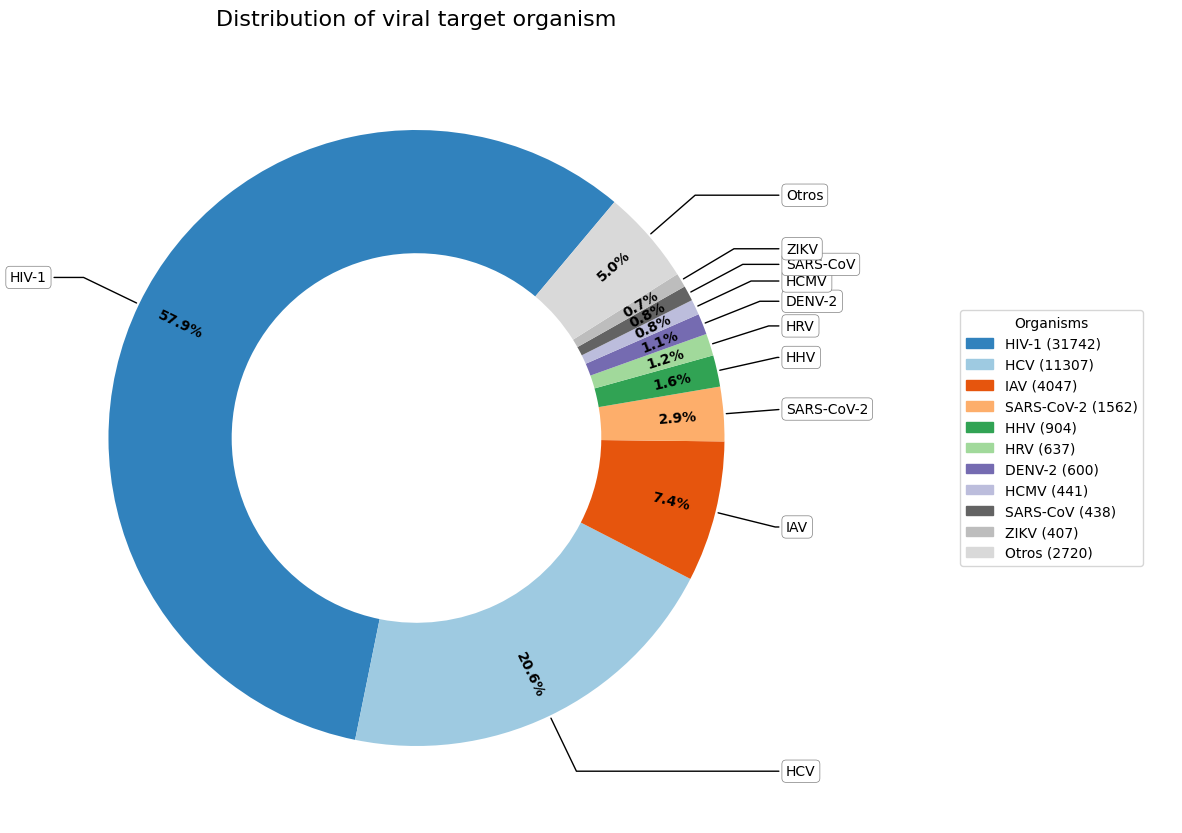

In [ ]:
#Order by 'count' and get the first 10 rows
top_10 = report_counts_CVC.nlargest(10, 'count_Org')
other = report_counts_CVC.iloc[10:]
other_sum = other['count_Org'].sum()

#Add a new row for "other" if there are additional organisms
if other_sum > 0:
    other_row = pd.DataFrame({'main_organism': ['Otros'], 'count_Org': [other_sum], 'acronym': ['Otros']})
    top_10 = pd.concat([top_10, other_row], ignore_index=True)

# Create a  subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [4, 1]})
fig.subplots_adjust(wspace=0.05)  # Adjust the space between subpots

#Main plot pie chart
colors = plt.cm.tab20c(np.linspace(0, 1, len(top_10['count_Org'])))
wedges, texts, autotexts = ax1.pie(top_10['count_Org'],
                                   wedgeprops=dict(width=0.4),
                                   startangle=50,
                                   colors=colors,
                                   autopct=lambda pct: f'{pct:.1f}%',
                                   pctdistance=0.85)

#Anotations in the graph
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=2, va="center")

distance = 1.2

#Put labels of percentaje
for autotext, wedge in zip(autotexts, wedges):
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    rotation = np.rad2deg(np.arctan2(y, x))  # Rotate the label
    if x < 0:
        rotation += 180
    autotext.set_rotation(rotation)
    autotext.set_color('black')
    autotext.set_weight('bold')
# add acronym labels
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})

    ax1.annotate(top_10['acronym'].iloc[i],
                 xy=(x, y),
                 xytext=(distance * np.sign(x), distance * y),
                 horizontalalignment=horizontalalignment, **kw)

 #Title of the main plot
ax1.set_title("Distribution of viral target organism", pad=20, fontsize=16)
#Leyends
legend_labels = [f'{acronym} ({count})' if acronym != 'Otros' else f'{acronym} ({other_sum})' for acronym, count in zip(top_10['acronym'], top_10['count_Org'])]
legend_colors = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(top_10))]
ax2.legend(legend_colors, legend_labels, title="Organisms", loc="center", fontsize=10)
ax2.axis('off')
plt.show()
#IBV','HRSV', 'SARS-CoV', 'HRV','SARS-CoV-2',

<ipython-input-62-2cf361c22996>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other['acronym'] = other['acronym'].astype(str)
<ipython-input-62-2cf361c22996>:111: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, -1, 0.95])


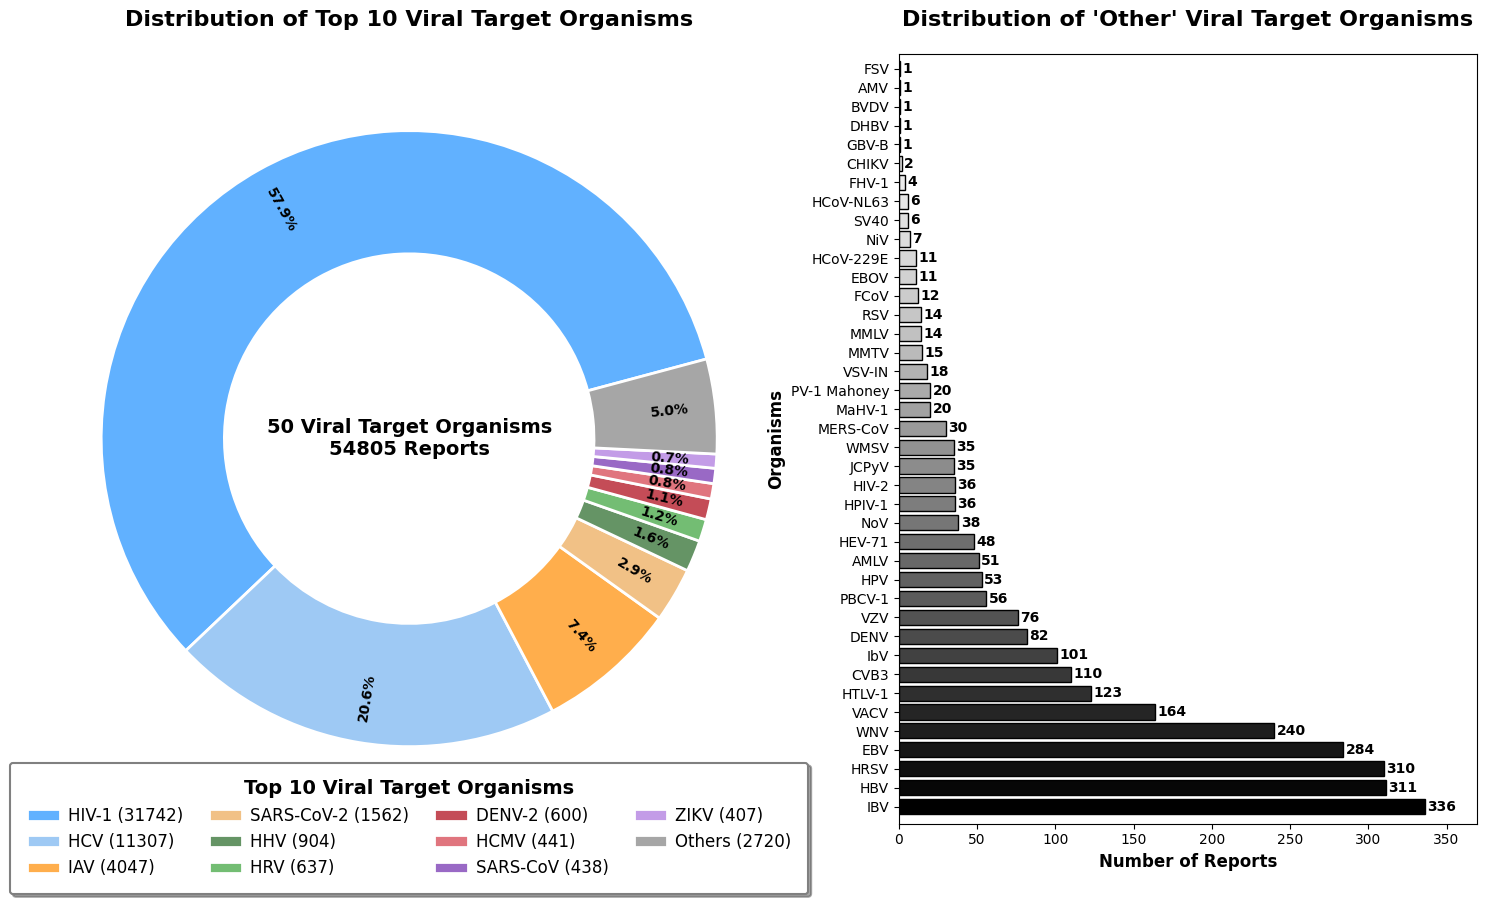

In [ ]:
from matplotlib.colors import to_rgba
import matplotlib.colors as mcolors
 def add_alpha(color, alpha):
    return mcolors.to_rgba(color, alpha=alpha)

 top_10 = report_counts_CVC.nlargest(10, 'count_Org')
other = report_counts_CVC.iloc[10:]
other_sum = other['count_Org'].sum()

 other['acronym'] = other['acronym'].astype(str)

 if other_sum > 0:
    other_row = pd.DataFrame({'main_organism': ['Others'], 'count_Org': [other_sum], 'acronym': ['Others']})
    top_10 = pd.concat([top_10, other_row], ignore_index=True)

 fig, axs = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={'width_ratios': [5, 3]})
fig.subplots_adjust(wspace=0.01)
 mycolors_alpha = ["#1E90FF", "#75b3f0",
                  "#FF8C00", "#eca753",
                  "#246724", "#38a138",
                  "#ac0010", "#d33b48",
                  "#6e2aad", "#aa73dd",
                  "#808080"
                 ]
#Convert colors to RGBA format with transparency
colors_rgba = [add_alpha(color, 0.7) for color in mycolors_alpha]

#Pie chart for the top 10 organisms
wedges, texts, autotexts = axs[0].pie(top_10['count_Org'],
                                   wedgeprops=dict(width=0.4, linewidth=2, edgecolor='white'),
                                   startangle=15,
                                   colors=colors_rgba,
                                   autopct=lambda pct: f'{pct:.1f}%', # Unidades de %
                                   pctdistance=0.85,
                                      )

#Position labels of percentage
for autotext, wedge in zip(autotexts, wedges):
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    rotation = np.rad2deg(np.arctan2(y, x))  # Rotar la etiqueta
    if x < 0:
        rotation += 180
    autotext.set_rotation(rotation)
    autotext.set_color('black')
    autotext.set_weight('semibold')
#Text in the center of the donut chart
total_reports = top_10['count_Org'].sum()
total_viral_organismo = len(report_counts_CVC['main_organism'])
axs[0].text(0, 0, f'{total_viral_organismo} Viral Target Organisms\n{total_reports} Reports',
         ha='center', va='center', fontsize=14, weight='semibold', color='black')

#Tittle of the main plot
axs[0].set_title("Distribution of Top 10 Viral Target Organisms", pad=20, fontsize=16, weight='bold')

#Leyend for the top 10 organisms at the bottom of the pie chart
legend_labels_top10 = [f'{acronym} ({count})' if acronym != 'Others' else f'{acronym} ({other_sum})' for acronym, count in zip(top_10['acronym'], top_10['count_Org'])]

#Create the leyend and adjust its appearance
legend = axs[0].legend(
    wedges,
    legend_labels_top10,
    title="Top 10 Viral Target Organisms",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.09),
    ncol=4,
    fontsize=12,
    frameon=True,  # Añadir un marco alrededor de la leyenda
    fancybox=True,  # Hacer el marco de la leyenda con esquinas redondeadas
    shadow=True,   # Añadir sombra al marco de la leyenda
    handletextpad=0.5,  # Espacio entre los manejadores y el texto
    borderpad=1,  # Espacio entre el contenido de la leyenda y su borde
    columnspacing=1.5  # Espacio entre las columnas
)

#Adjust the thickness and color of the legend frame
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('gray')

#Adjust the fontsize and style of the legend title
legend.get_title().set_fontsize(14)
legend.get_title().set_weight('bold')

#Create a color map from black to white
cmap = sns.color_palette("Greys_r", as_cmap=True) #cmap = sns.cm.icefire.reversed()
#Barplot to the organism inside "Others"
if other_sum > 0:
    colors_2 = cmap(np.linspace(0, 1, len(other)))
    bars = axs[1].barh(other['acronym'], other['count_Org'], color=colors_2, edgecolor='black')
    axs[1].set_xlabel('Number of Reports', fontsize=12, weight='bold')
    axs[1].set_ylabel('Organisms', fontsize=12, weight='bold')
    axs[1].set_title("Distribution of 'Other' Viral Target Organisms", pad=20, fontsize=16, weight='bold')

    #Adjust the thresholds of the y-axis to reduce the space at the top and bottom
    axs[1].set_ylim(-0.9, len(other) - 0.2)
    axs[1].set_xlim(0, max(other['count_Org']) * 1.1)

    #Add labels of count in the bars
    for bar in bars:
        axs[1].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width())}',
                    va='center', ha='left', color='black', fontsize=10, weight='bold')

plt.tight_layout(rect=[0, 0, -1, 0.95])
plt.show()

In [ ]:
from matplotlib.colors import to_rgba

def add_alpha(color, alpha):
    rgba = to_rgba(color)
    return rgba[:3] + (alpha,)

def plot_top_X_pie(dataframe, count_column, top=10,
                   x=20, y=10,
                   colors=None,
                   bar_chart_activate=True,
                   other_color="#808080"):
    if colors is None:
        colors = ["#1E90FF", "#75b3f0",
                  "#FF8C00", "#eca753",
                  "#246724", "#38a138",
                  "#ac0010", "#d33b48",
                  "#6e2aad", "#aa73dd"]

    #Transform colors to RGBA format with transparency
    colors_rgba = [add_alpha(color, 0.7) for color in colors]
    other_color_rgba = add_alpha(other_color, 0.7)

    #Order by count and get the first top rows
    top_n = dataframe.nlargest(top, count_column)
    other = dataframe.iloc[top:]
    other_sum = other[count_column].sum()

    #Ensure that the values in the 'acronym' column are strings
    other['acronym'] = other['acronym'].astype(str)

    #Add rows for "Others" if there are additional organisms
    if other_sum > 0:
        other_row = pd.DataFrame({'main_organism': ['Others'], count_column: [other_sum], 'acronym': ['Others']})
        top_n = pd.concat([top_n, other_row], ignore_index=True)

    #Add colors to "Others"
    if len(top_n) > top:
        colors_rgba.append(other_color_rgba)

    #Create  subplots
    fig, axs = plt.subplots(1, 2, figsize=(x,y), gridspec_kw={'width_ratios': [5, 3]})
    fig.subplots_adjust(wspace=0.01)  # Ajustar el espacio entre subplots

    #Main pie plot
    wedges, texts, autotexts = axs[0].pie(top_n[count_column],
                                          wedgeprops=dict(width=0.4, linewidth=2, edgecolor='white'),
                                          startangle=15,
                                          colors=colors_rgba,
                                          autopct=lambda pct: f'{pct:.1f}%',  # Unidades de %
                                          pctdistance=0.85)

     for autotext, wedge in zip(autotexts, wedges):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        rotation = np.rad2deg(np.arctan2(y, x))  # Rotar la etiqueta
        if x < 0:
            rotation += 180
        autotext.set_rotation(rotation)
        autotext.set_color('black')
        autotext.set_weight('semibold')

    total_reports = top_n[count_column].sum()
    total_viral_organisms = len(dataframe['main_organism'].unique())
    axs[0].text(0, 0, f'{total_viral_organisms} Viral Target Organisms\n{total_reports} Reports',
                ha='center', va='center', fontsize=14, weight='semibold', color='black')

    axs[0].set_title(f"Distribution of Top {top} Viral Target Organisms", pad=20, fontsize=16, weight='bold')

    legend_labels_top_n = [f'{acronym} ({count})' if acronym != 'Others' else f'{acronym} ({other_sum})' for acronym, count in zip(top_n['acronym'], top_n[count_column])]

    legend = axs[0].legend(
        wedges,
        legend_labels_top_n,
        title=f"Top {top} Viral Target Organisms",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.09),
        ncol=4,
        fontsize=12,
        frameon=True,  # Añadir un marco alrededor de la leyenda
        fancybox=True,  # Hacer el marco de la leyenda con esquinas redondeadas
        shadow=True,   # Añadir sombra al marco de la leyenda
        handletextpad=0.5,  # Espacio entre los manejadores y el texto
        borderpad=1,  # Espacio entre el contenido de la leyenda y su borde
        columnspacing=1.5  # Espacio entre las columnas
    )

    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_edgecolor('gray')

    legend.get_title().set_fontsize(14)
    legend.get_title().set_weight('bold')

    if bar_chart_activate:
        cmap = sns.color_palette("Greys_r", as_cmap=True)

        if other_sum > 0:
            colors_2 = [other_color_rgba] * len(other)  # Usar el color para "Others"
            bars = axs[1].barh(other['acronym'], other[count_column], color=colors_2, edgecolor='black')
            axs[1].set_xlabel('Number of Reports', fontsize=12, weight='bold')
            axs[1].set_ylabel('Organisms', fontsize=12, weight='bold')
            axs[1].set_title("Distribution of 'Other' Viral Target Organisms", pad=20, fontsize=16, weight='bold')

            axs[1].set_ylim(-0.9, len(other) - 0.2)
            axs[1].set_xlim(0, max(other[count_column]) * 1.1)

            for bar in bars:
                axs[1].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width())}',
                            va='center', ha='left', color='black', fontsize=10, weight='bold')
    else:
        axs[1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

<ipython-input-63-215dc93c1336>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other['acronym'] = other['acronym'].astype(str)


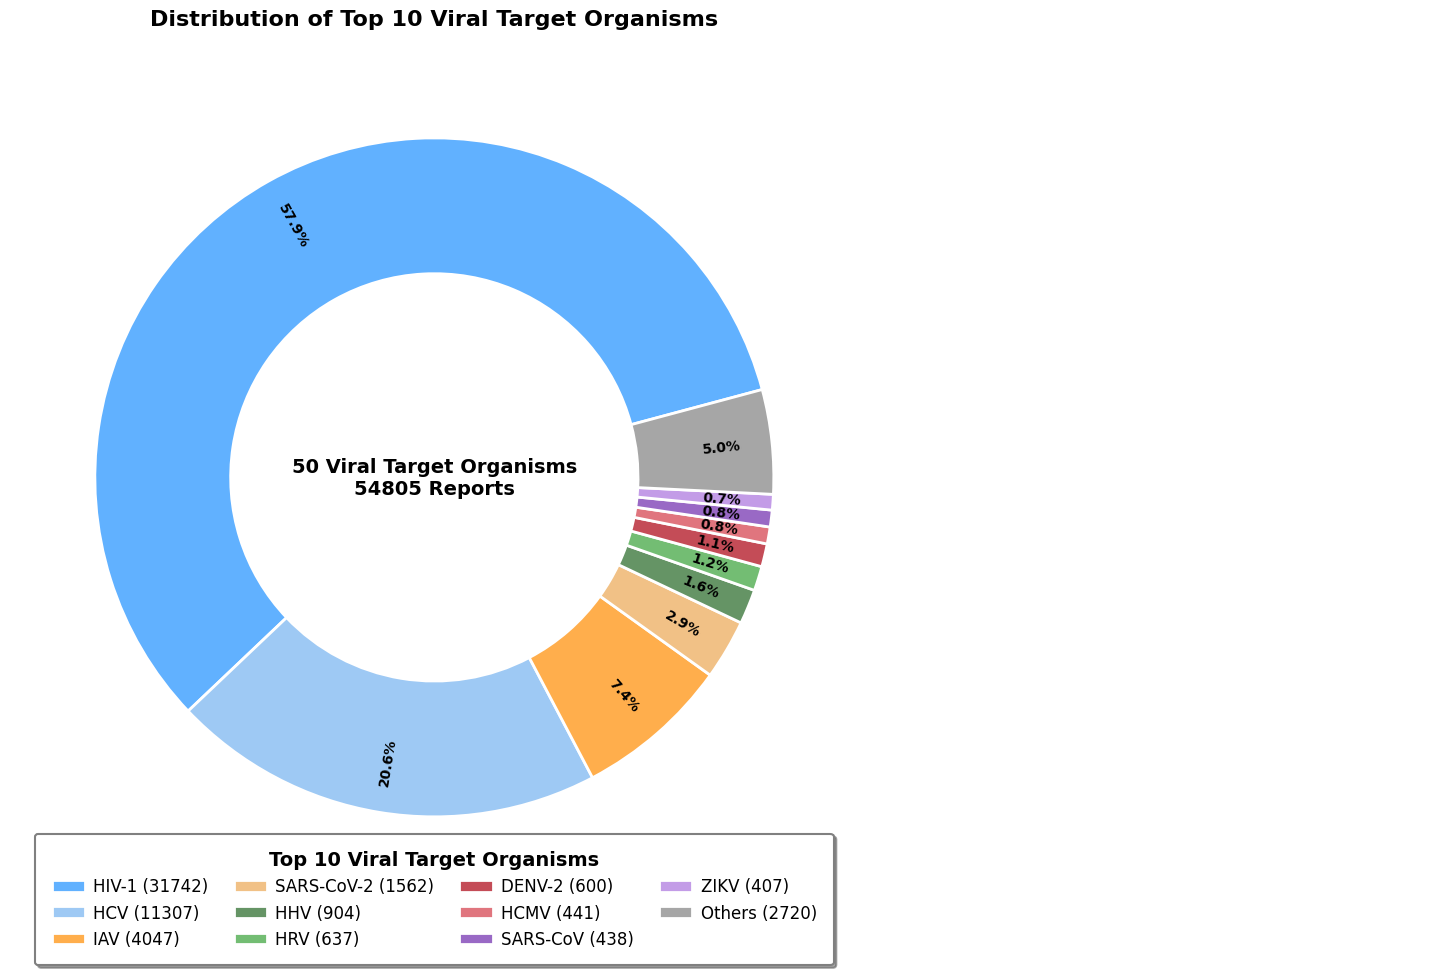

In [ ]:
plot_top_X_pie(report_counts_CVC, 'count_Org',
               top=10,
               x=15, y=10,
               bar_chart_activate=False,
               colors=["#1E90FF", "#75b3f0", "#FF8C00", "#eca753", "#246724",
                       "#38a138", "#ac0010", "#d33b48", "#6e2aad", "#aa73dd"],
               other_color="#808080")

<ipython-input-63-215dc93c1336>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other['acronym'] = other['acronym'].astype(str)


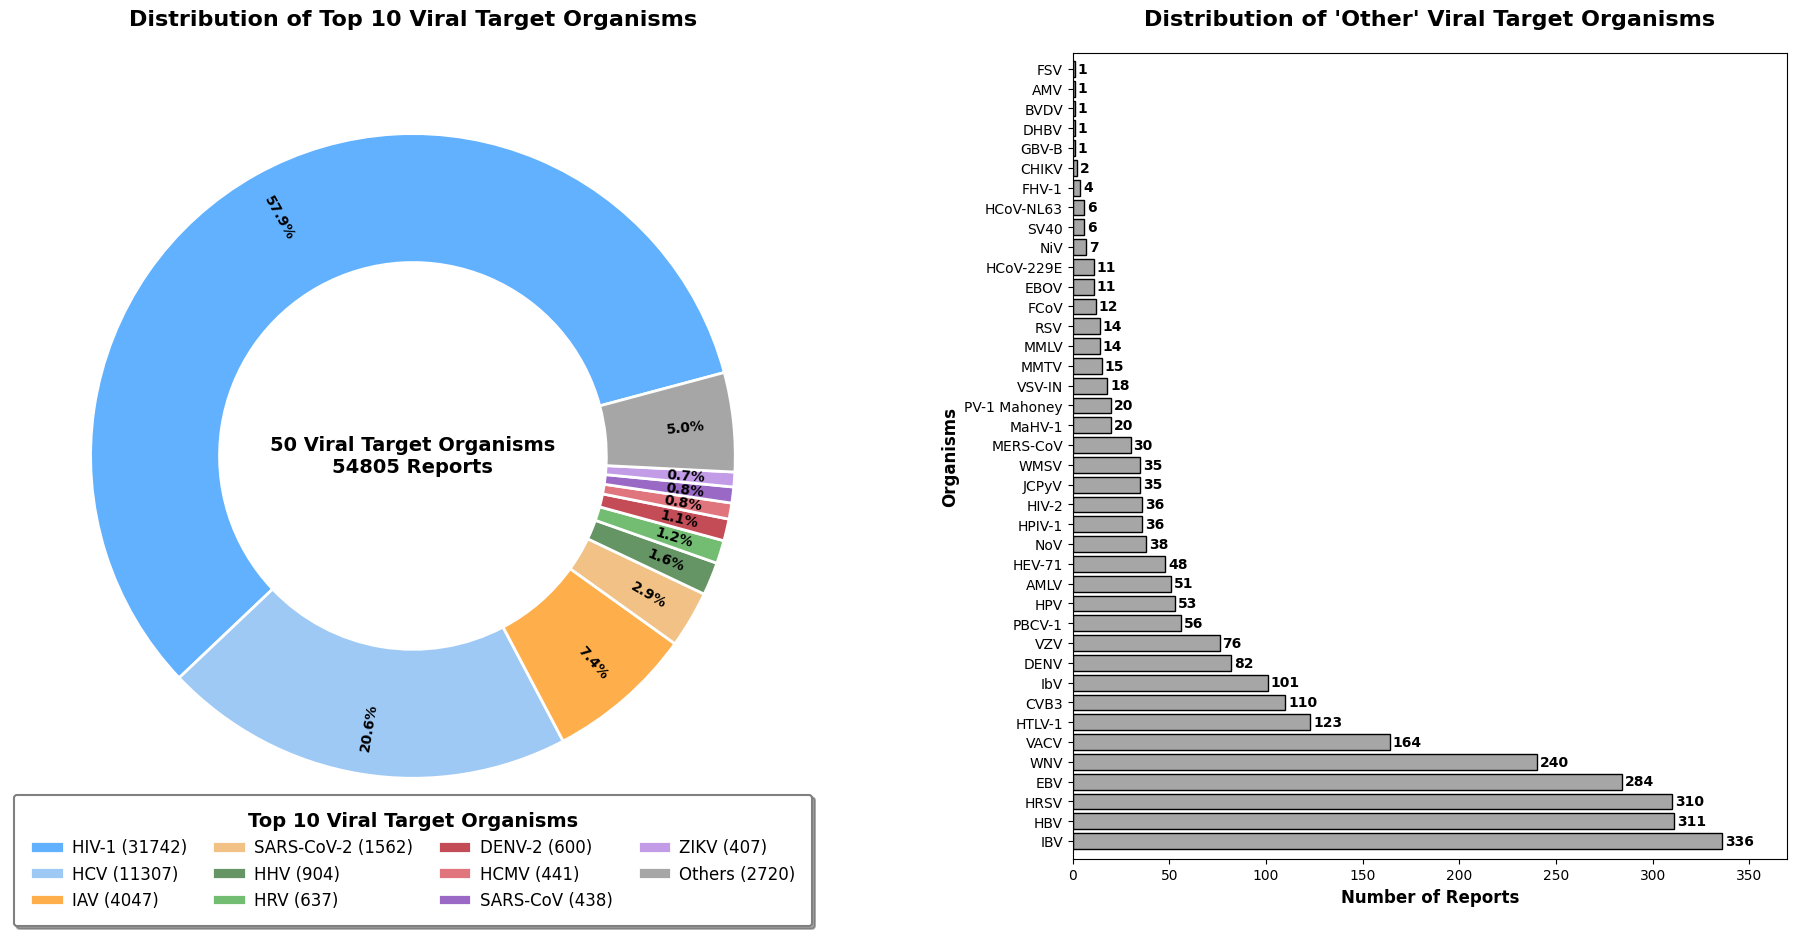

In [ ]:
plot_top_X_pie(report_counts_CVC,'count_Org',
               top=10,
               colors=["#1E90FF", "#75b3f0", "#FF8C00", "#eca753",
                       "#246724", "#38a138", "#ac0010", "#d33b48",
                       "#6e2aad", "#aa73dd"],
                other_color="#808080", bar_chart_activate=True)

## **1.4 SMILES standarization de SMILES**

In [ ]:
print(VirCom_1.columns)
VirCom_1[0:2]

Index(['activity_id', 'assay_chembl_id', 'assay_description',
       'canonical_smiles', 'document_chembl_id', 'document_journal',
       'ligand_efficiency', 'molecule_chembl_id', 'standard_units',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'units', 'value', 'cross_references', 'organism',
       'pref_name', 'species_group_flag', 'target_components', 'target_type',
       'tax_id', 'pIC50', 'main_organism', 'acronym', 'acronym_assigned',
       'count_Org', 'target', 'count_Tar', 'Focus_on'],
      dtype='object')


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,target_type,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,SINGLE PROTEIN,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,SINGLE PROTEIN,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp


In [ ]:
def _preprocess_mol(i, row):
    try:
        mol = dm.to_mol(row["canonical_smiles"], ordered = True)#Transform the molecule and keep the order of the atoms
        mol = dm.fix_mol(mol, largest_only = True)#Adjust the structure of the molecule to correct commun mistakes
        mol = dm.sanitize_mol(mol, sanifix = True, charge_neutral = False)#Sanitize the molecule ensure that will be chemical valid
         mol = dm.standardize_mol(
            mol,
            disconnect_metals = False,
            normalize = True,
            reionize = True,
            uncharge = False,
            stereo = True # Ensure proper reassignment of stereochemistry if missing
        )
        row["Canonical_SMILES_STD"] = dm.standardize_smiles(dm.to_smiles(mol, isomeric = True))  # Include stereochemistry
        return row
    except:
        row["Canonical_SMILES_STD"] = "error"
        return row

In [ ]:
VirCom_curated= dm.parallelized(_preprocess_mol, VirCom_1.iterrows(), arg_type = 'args', progress = True, total = len(VirCom_1))
VirCom_curated = pd.DataFrame(VirCom_curated)
print(f"total original compounds: {len(VirCom_1)}")
print(f"Total amount of compounds curated: {VirCom_curated[VirCom_curated['Canonical_SMILES_STD'] != 'error']['Canonical_SMILES_STD'].nunique()}")
print(f"total errors found: {(VirCom_curated['Canonical_SMILES_STD']=='error').sum()}")
print(f"The final shape of the database curated is {VirCom_curated.shape}")
print(VirCom_curated.shape)
VirCom_curated[0:2]

  0%|          | 0/54805 [00:00<?, ?it/s]

total original compounds: 54805
Total amount of compounds curated: 31564
total errors found: 25
The final shape of the database curated is (54805, 31)
(54805, 31)


,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on,Canonical_SMILES_STD
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...


In [ ]:
VirCom_curated = VirCom_curated[VirCom_curated["Canonical_SMILES_STD"] != 'error'].reset_index(drop = True)
VirCom_curated

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on,Canonical_SMILES_STD
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.80,...,385587,7.642065,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,385587,5.677919,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,385587,5.371577,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.00,...,211044,5.236572,influenza a virus,IAV,True,4047,RdRp,179,Resp,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.00,...,211044,4.619789,influenza a virus,IAV,True,4047,RdRp,179,Resp,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54775,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,268305,4.522879,bovine viral diarrhea virus,BVDV,True,1,RdRp,1,NoResp,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1
54776,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,NaN,CHEMBL377720,nM,30000.00,...,11866,4.522879,avian myeloblastosis virus,AMV,True,1,Reverse Transcriptase,1,NoResp,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1
54777,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,NaN,CHEMBL372357,nM,50000.00,...,39113,4.301030,hepatitis gb virus b,GBV-B,True,1,RdRp (NS5B),1,NoResp,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...
54778,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.00,...,11885,5.744727,fujinami sarcoma virus,FSV,True,1,Kinase,1,NoResp,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12


In [ ]:
VirCom_curated = VirCom_curated.astype(str)
VirCom_curated.to_excel(path_dataframe + '4_viralcompounds_curated_ChEMBL.xlsx')

### Read the DF

In [ ]:
'''path_dataframe= '/content/drive/MyDrive/Proyectos/Chemo-viral_space_of_natural_products/Files/DataFrames/'
VirCom_curated = pd.read_excel(path_dataframe + '4_viralcompounds_curated_ChEMBL.xlsx', index_col=0)'''

"path_dataframe= '/content/drive/MyDrive/Proyectos/Chemo-viral_space_of_natural_products/Files/DataFrames/'\nVirCom_curated = pd.read_excel(path_dataframe + '4_viralcompounds_curated_ChEMBL.xlsx', index_col=0)"

In [ ]:
VirCom_curated_pruebaSMILS = VirCom_curated.copy()

In [ ]:
PandasTools.AddMoleculeColumnToFrame(VirCom_curated_pruebaSMILS,'Canonical_SMILES_STD','Molecule',includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(VirCom_curated_pruebaSMILS,'canonical_smiles','Mol_prev',includeFingerprints=True)

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on,Canonical_SMILES_STD,Molecule,Mol_prev
0,18813618,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CHEMBL4270670,J Med Chem,"{'bei': '23.00', 'le': '0.45', 'lle': '11.22',...",CHEMBL222813,nM,22.8,...,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,,
1,18813612,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,CHEMBL4270670,J Med Chem,"{'bei': '11.62', 'le': '0.23', 'lle': '0.62', ...",CHEMBL4292761,nM,2099.33,...,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(SC3CC...,,
2,18813611,CHEMBL4276514,Inhibition of Influenza A virus A/duck/Guangdo...,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,CHEMBL4270670,J Med Chem,"{'bei': '11.51', 'le': '0.22', 'lle': '0.94', ...",CHEMBL4282553,nM,4250.33,...,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](NCc2ccc(Oc3cc...,,
3,22917334,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,CHEMBL4732130,Eur J Med Chem,"{'bei': '14.06', 'le': '0.26', 'lle': '2.79', ...",CHEMBL4743427,nM,5800.0,...,influenza a virus,IAV,True,4047,RdRp,179,Resp,Cc1cc(-c2ccccc2)nc2nc(C(=O)Nc3ccccc3C(N)=O)nn12,,
4,22917335,CHEMBL4735859,Inhibition of RdRP activity in Influenza A vir...,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,CHEMBL4732130,Eur J Med Chem,"{'bei': '18.92', 'le': '0.37', 'lle': '7.63', ...",CHEMBL1643,nM,24000.0,...,influenza a virus,IAV,True,4047,RdRp,179,Resp,NC(=O)c1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)n1,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54775,1676679,CHEMBL864671,Inhibitory activity against BVDV NS5b RNA poly...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,nan,CHEMBL377720,nM,30000.0,...,bovine viral diarrhea virus,BVDV,True,1,RdRp,1,NoResp,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,,
54776,1676680,CHEMBL864673,Inhibitory activity against AMV Reverse transc...,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,CHEMBL1149391,J Med Chem,nan,CHEMBL377720,nM,30000.0,...,avian myeloblastosis virus,AMV,True,1,Reverse Transcriptase,1,NoResp,O=C1/C(=C/c2ccc(Cl)cc2)SC(=S)N1NS(=O)(=O)c1ccccc1,,
54777,1679064,CHEMBL867035,Inhibitory activity against virus GBV-B polyme...,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,CHEMBL1148625,J Med Chem,nan,CHEMBL372357,nM,50000.0,...,hepatitis gb virus b,GBV-B,True,1,RdRp (NS5B),1,NoResp,O=c1c(C2=Nc3ccccc3S(=O)(=O)N2)c(O)c2cc(F)ccc2n...,,
54778,2202644,CHEMBL941408,Inhibition of Fujinami sarcoma virus pp130fps,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,CHEMBL1150213,J Nat Prod,"{'bei': '18.05', 'le': '0.34', 'lle': '4.05', ...",CHEMBL164,nM,1800.0,...,fujinami sarcoma virus,FSV,True,1,Kinase,1,NoResp,O=c1c(O)c(-c2cc(O)c(O)c(O)c2)oc2cc(O)cc(O)c12,,

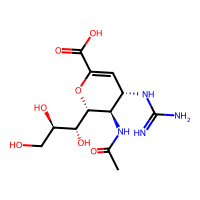
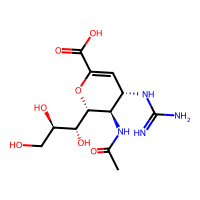
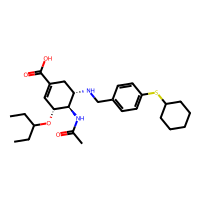
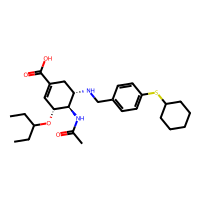
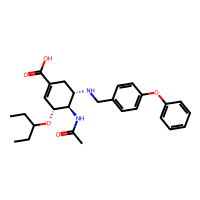
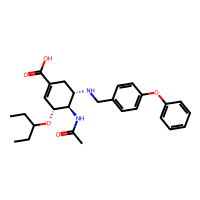
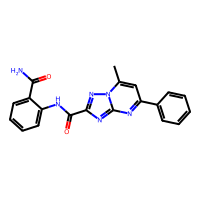
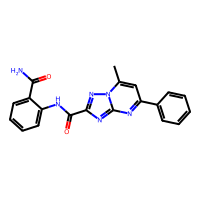
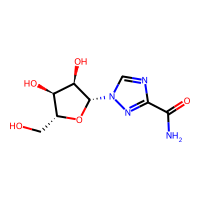
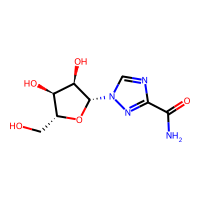
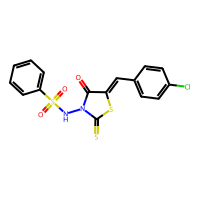
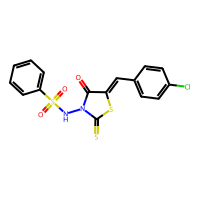
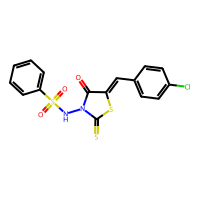
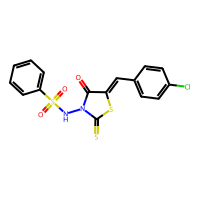
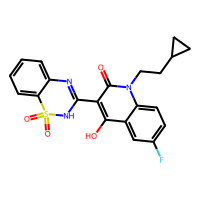
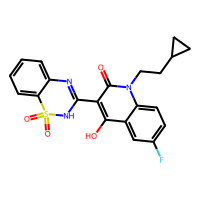
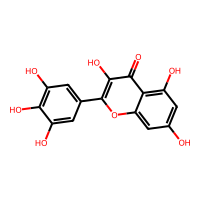
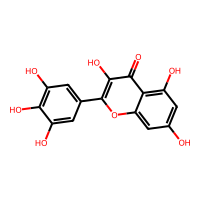
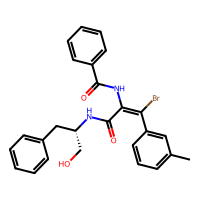
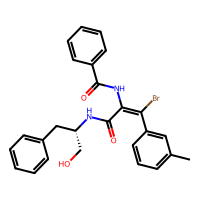

In [ ]:
VirCom_curated_pruebaSMILS

,Mol_prev,Molecule
27522,,
9278,,
11747,,
27482,,
9952,,
...,...,...
35736,,
35798,,
35796,,
35767,,

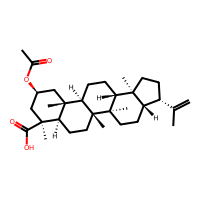
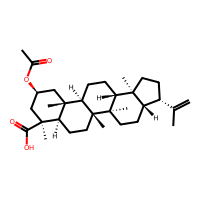
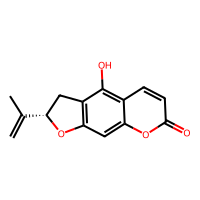
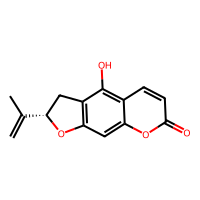
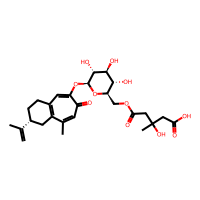
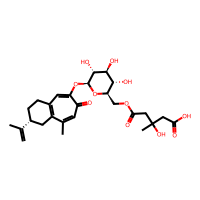
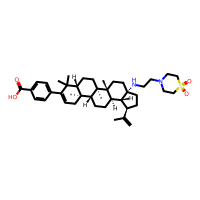
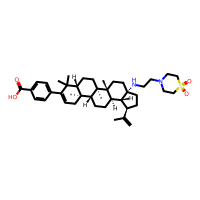
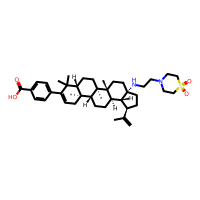
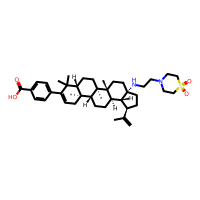
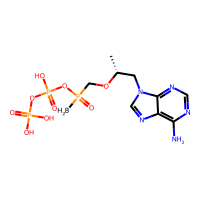
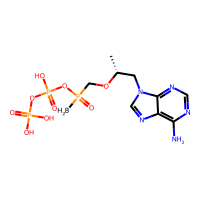
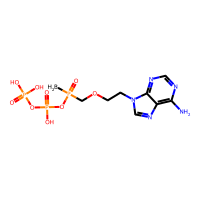
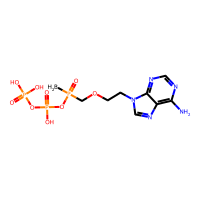
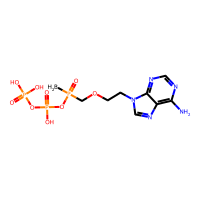
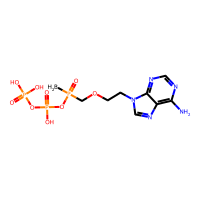
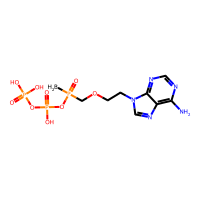
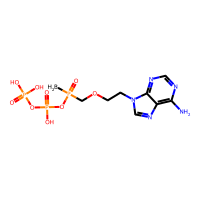
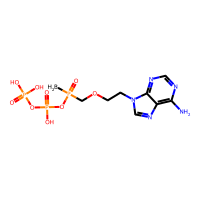
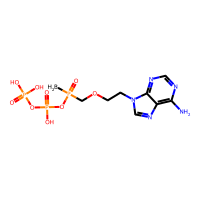

In [ ]:
df_sorted=VirCom_curated_pruebaSMILS.sort_values(by='Canonical_SMILES_STD', ascending=False)
df_sorted[['Mol_prev','Molecule' ]].tail(500)

## **1.5 Grouping of molecules**

In [ ]:
VirCom_curated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54780 entries, 0 to 54779
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   activity_id           54780 non-null  object
 1   assay_chembl_id       54780 non-null  object
 2   assay_description     54780 non-null  object
 3   canonical_smiles      54780 non-null  object
 4   document_chembl_id    54780 non-null  object
 5   document_journal      54780 non-null  object
 6   ligand_efficiency     54780 non-null  object
 7   molecule_chembl_id    54780 non-null  object
 8   standard_units        54780 non-null  object
 9   standard_value        54780 non-null  object
 10  target_chembl_id      54780 non-null  object
 11  target_organism       54780 non-null  object
 12  target_pref_name      54780 non-null  object
 13  units                 54780 non-null  object
 14  value                 54780 non-null  object
 15  cross_references      54780 non-null

In [ ]:
VirCom_curated = VirCom_curated.sort_values(by='pIC50', ascending=False)
VirCom_curated
#VirCom_curated[['standard_value','pIC50']][0:1]

,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,molecule_chembl_id,standard_units,standard_value,...,tax_id,pIC50,main_organism,acronym,acronym_assigned,count_Org,target,count_Tar,Focus_on,Canonical_SMILES_STD
24687,1517800,CHEMBL826984,Binding affinity against HIV-1 protease,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,CHEMBL1142730,J Med Chem,nan,CHEMBL1323,nM,0.0,...,11676,inf,human immunodeficiency virus 1,HIV-1,True,31742,Protease,9171,NoResp,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...
18383,18885381,CHEMBL4313194,Inhibition of HIV1 NL4-3 protease I50V/A71V mu...,CCC(CC)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@...,CHEMBL4311955,J Med Chem,"{'bei': '16.52', 'le': '0.32', 'lle': '6.36', ...",CHEMBL4570309,nM,0.102,...,11676,9.991399828238082,human immunodeficiency virus 1,HIV-1,True,31742,Protease,9171,NoResp,CCC(CC)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@...
40631,18477739,CHEMBL4183921,Inhibition of NS5A L31M mutant in HCV genotype...,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1ncc(-c2cc(F)c3...,CHEMBL4177770,J Med Chem,nan,CHEMBL4206595,nM,0.102,...,3052230,9.991399828238082,hepatitis c virus,HCV,True,11307,NS5Apro,2713,NoResp,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1ncc(-c2cc(F)c3...
39288,17784903,CHEMBL3888894,Luciferase Assay: The Huh-7 cells transfected ...,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1ncc(-c2ccc(-c3...,CHEMBL3886877,nan,"{'bei': '10.37', 'le': '0.19', 'lle': '1.11', ...",CHEMBL3970571,nM,0.103,...,3052230,9.987162775294827,hepatitis c virus,HCV,True,11307,NS5Apro,2713,NoResp,COC(=O)N[C@H](C(=O)N1CCC[C@H]1c1ncc(-c2ccc(-c3...
39278,17784913,CHEMBL3888894,Luciferase Assay: The Huh-7 cells transfected ...,COC(=O)NC(C(=O)N1CCCC1c1cc(=O)c2cc(-c3ccc(-c4c...,CHEMBL3886877,nan,"{'bei': '10.97', 'le': '0.20', 'lle': '0.99', ...",CHEMBL3897376,nM,0.103,...,3052230,9.987162775294827,hepatitis c virus,HCV,True,11307,NS5Apro,2713,NoResp,COC(=O)NC(C(=O)N1CCCC1c1cc(=O)c2cc(-c3ccc(-c4c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2457,2211486,CHEMBL986926,Inhibition of influenza virus neuraminidase,CC(C)N(CCc1ccccn1)C(=O)N1C[C@@H](N)[C@@H](C(=O...,CHEMBL1149825,Eur J Med Chem,nan,CHEMBL459838,nM,1299870237.39,...,382835,-0.11390000000046654,influenza a virus,IAV,True,4047,Neuraminidase,3168,Resp,CC(C)N(CCc1ccccn1)C(=O)N1C[C@@H](N)[C@@H](C(=O...
31984,605638,CHEMBL859312,Inhibitory activity was determined against HIV...,CC(C)[C@H](NC(=O)[C@H](NCc1ccccc1)[C@H](O)[C@H...,CHEMBL1128211,J Med Chem,nan,CHEMBL342293,nM,1235947433.44,...,11676,-0.0919999999984151,human immunodeficiency virus 1,HIV-1,True,31742,Protease,9171,NoResp,CC(C)[C@H](NC(=O)[C@H](NCc1ccccc1)[C@H](O)[C@H...
17526,12416038,CHEMBL3062687,Inhibition of Human immunodeficiency virus 1 i...,O=C(O)/C(O)=C/C(=O)c1ccc2c(c1)c(=O)c(C(=O)O)cn...,CHEMBL3044682,Med Chem Res,nan,CHEMBL2236597,nM,1089933497.03,...,11676,-0.03740000000116856,human immunodeficiency virus 1,HIV-1,True,31742,Integrase,7663,NoResp,O=C(O)/C(O)=C/C(=O)c1ccc2c(c1)c(=O)c(C(=O)O)cn...
17221,12450081,CHEMBL3055360,Inhibition of Human immunodeficiency virus 1 i...,O=C(O)/C(O)=C/C(=O)c1cc2ccccc2n1Cc1ccccc1,CHEMBL3045301,Med Chem Res,nan,CHEMBL2262610,nM,1000000000.0,...,11676,-0.0,human immunodeficiency virus 1,HIV-1,True,31742,Integrase,7663,NoResp,O=C(O)/C(O)=C/C(=O)c1cc2ccccc2n1Cc1ccccc1


In [ ]:
#Grouped the dataframe and aggregate the elements converting them to strings before joining them
#Aggregation considering groups from molecules > organisms > targets
grouped_df_try_1 = VirCom_curated.groupby(['molecule_chembl_id', 'acronym', 'target']).agg(lambda x: ' - '.join(x.astype(str)))
grouped_df_try_1 = grouped_df_try_1.reset_index()
print(len(grouped_df_try_1))
grouped_df_try_1.head(2)
#molecule_chembl_id: 31797 ;  #molecule_chembl_id, target_organism: 34178 -->34058

33851


,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,...,target_components,target_type,tax_id,pIC50,main_organism,acronym_assigned,count_Org,count_Tar,Focus_on,Canonical_SMILES_STD
0,CHEMBL100034,HIV-1,Protease,861959,CHEMBL769369,Inhibition of HIV-1 Protease.,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...,CHEMBL1126824,J Med Chem,"{'bei': '11.41', 'le': '0.21', 'lle': '4.14', ...",...,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,6.8996294548824375,human immunodeficiency virus 1,True,31742,9171,NoResp,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...
1,CHEMBL100039,HIV-1,Protease,833875,CHEMBL769369,Inhibition of HIV-1 Protease.,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...,CHEMBL1126824,J Med Chem,"{'bei': '13.19', 'le': '0.25', 'lle': '4.79', ...",...,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,7.886056647693163,human immunodeficiency virus 1,True,31742,9171,NoResp,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...


In [ ]:
def remove_duplicates(cell):
    if pd.isna(cell):
        return cell
    else:
         items = cell.split(' - ') #Divided the cell in a list considering the "-"
         unique_items = list(set(items)) #Convert the list in a group in order to drop duplicates and then made a list
         return ' - '.join(unique_items) #Joined the elements in a list

columns_to_process = ['molecule_chembl_id', 'assay_description', 'document_chembl_id',
                      'document_journal', 'target_chembl_id', 'target_organism', 'tax_id',
                      'target_pref_name', 'cross_references', 'organism', 'pref_name',
                    'species_group_flag','target_components', 'target_type','Canonical_SMILES_STD','main_organism', 'acronym',
                      'count_Org', 'count_Tar', 'target','Focus_on' ]

for column in columns_to_process:
    grouped_df_try_1[column] = grouped_df_try_1[column].apply(remove_duplicates)

print(grouped_df_try_1.shape)

(33851, 31)


In [ ]:
grouped_df_try_1[0:3]

,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,canonical_smiles,document_chembl_id,document_journal,ligand_efficiency,...,target_components,target_type,tax_id,pIC50,main_organism,acronym_assigned,count_Org,count_Tar,Focus_on,Canonical_SMILES_STD
0,CHEMBL100034,HIV-1,Protease,861959,CHEMBL769369,Inhibition of HIV-1 Protease.,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...,CHEMBL1126824,J Med Chem,"{'bei': '11.41', 'le': '0.21', 'lle': '4.14', ...",...,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,6.8996294548824375,human immunodeficiency virus 1,True,31742,9171,NoResp,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...
1,CHEMBL100039,HIV-1,Protease,833875,CHEMBL769369,Inhibition of HIV-1 Protease.,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...,CHEMBL1126824,J Med Chem,"{'bei': '13.19', 'le': '0.25', 'lle': '4.79', ...",...,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,7.886056647693163,human immunodeficiency virus 1,True,31742,9171,NoResp,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...
2,CHEMBL100040,HIV-1,Protease,883951,CHEMBL695235,Inhibitory activity against HIV-1 protease,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2SCC[C@@H]2CN1C[C@...,CHEMBL1128092,Bioorg Med Chem Lett,nan,...,"[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,9.698970004336019,human immunodeficiency virus 1,True,31742,9171,NoResp,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2SCC[C@@H]2CN1C[C@...


In [ ]:
grouped_df_try_1 = grouped_df_try_1.drop(columns=['canonical_smiles',
                                                  'units','value',
                                                  'species_group_flag','organism', 'pref_name', 'acronym_assigned'])
print(grouped_df_try_1.shape)
grouped_df_try_1[0:3]

(33851, 24)


,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,cross_references,target_components,target_type,tax_id,pIC50,main_organism,count_Org,count_Tar,Focus_on,Canonical_SMILES_STD
0,CHEMBL100034,HIV-1,Protease,861959,CHEMBL769369,Inhibition of HIV-1 Protease.,CHEMBL1126824,J Med Chem,"{'bei': '11.41', 'le': '0.21', 'lle': '4.14', ...",nM,...,"[{'xref_id': 'Q72874', 'xref_name': None, 'xre...","[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,6.8996294548824375,human immunodeficiency virus 1,31742,9171,NoResp,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...
1,CHEMBL100039,HIV-1,Protease,833875,CHEMBL769369,Inhibition of HIV-1 Protease.,CHEMBL1126824,J Med Chem,"{'bei': '13.19', 'le': '0.25', 'lle': '4.79', ...",nM,...,"[{'xref_id': 'Q72874', 'xref_name': None, 'xre...","[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,7.886056647693163,human immunodeficiency virus 1,31742,9171,NoResp,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...
2,CHEMBL100040,HIV-1,Protease,883951,CHEMBL695235,Inhibitory activity against HIV-1 protease,CHEMBL1128092,Bioorg Med Chem Lett,nan,nM,...,"[{'xref_id': 'Q72874', 'xref_name': None, 'xre...","[{'accession': 'Q72874', 'component_descriptio...",SINGLE PROTEIN,11676,9.698970004336019,human immunodeficiency virus 1,31742,9171,NoResp,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2SCC[C@@H]2CN1C[C@...


In [ ]:
grouped_df_try_1['length_pIC50'] = grouped_df_try_1['pIC50'].apply(lambda x: len(x.split(' - ')))
grouped_df_try_1['First_pIC50'] = grouped_df_try_1['pIC50'].apply(lambda x: x.split(' - ')[0])
grouped_df_try_1['Last_pIC50'] = grouped_df_try_1['pIC50'].apply(lambda x: x.split(' - ')[-1])
grouped_df_try_2 = grouped_df_try_1.sort_values(by='length_pIC50', ascending=False)
grouped_df_try_2.iloc[0:5]

,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,tax_id,pIC50,main_organism,count_Org,count_Tar,Focus_on,Canonical_SMILES_STD,length_pIC50,First_pIC50,Last_pIC50
31843,CHEMBL57,HIV-1,Reverse Transcriptase,443905 - 19224357 - 3114761 - 317801 - 317798 ...,CHEMBL804227 - CHEMBL4395644 - CHEMBL1073715 -...,Inhibition of HIV1 recombinant reverse transcr...,CHEMBL2040821 - CHEMBL1144363 - CHEMBL1140132 ...,Bioorg Med Chem Lett - J Nat Prod - ACS Med Ch...,"nan - nan - {'bei': '31.71', 'le': '0.58', 'll...",nM - nM - nM - nM - nM - nM - uM - nM - nM - n...,...,11676,8.886056647693163 - 8.721246399047171 - 8.4436...,human immunodeficiency virus 1,31742,13198,NoResp,Cc1ccnc2c1NC(=O)c1cccnc1N2C1CC1,383,8.886056647693163,2.612432220582811
8625,CHEMBL223228,HIV-1,Reverse Transcriptase,15734434 - 6280258 - 5157484 - 6280284 - 51574...,CHEMBL3626332 - CHEMBL1805968 - CHEMBL1661187 ...,Inhibition of reverse transcriptase E138K muta...,CHEMBL3045881 - CHEMBL1144398 - CHEMBL1153492 ...,Bioorg Med Chem Lett - ACS Med Chem Lett - Med...,"{'bei': '30.98', 'le': '0.64', 'lle': '5.71', ...",nM - nM - nM - nM - nM - nM - nM - uM - nM - n...,...,11676,9.779891911959945 - 9.522878745280337 - 9.5086...,human immunodeficiency virus 1,31742,13198,NoResp,O=C1Nc2ccc(Cl)cc2[C@@](C#CC2CC2)(C(F)(F)F)O1,290,9.779891911959945,10.040958607678906
8613,CHEMBL222813,IAV,Neuraminidase,3527776 - 6383033 - 3341420 - 13932871 - 13932...,CHEMBL1274484 - CHEMBL1839500 - CHEMBL1167423 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL1134303 - CHEMBL4425127 - CHEMBL3817747 ...,Bioorg Med Chem Lett - Eur J Med Chem - Medche...,"{'bei': '29.48', 'le': '0.58', 'lle': '13.38',...",nM - 10'-4umol/L - nM - nM - nM - nM - nM - nM...,...,504904 - 440390 - 382835 - 381518 - 385580 - 3...,9.795880017344075 - 9.7281583934635 - 9.698970...,influenza a virus,4047,3168,Resp,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,181,9.795880017344075,10.221848749616356
12396,CHEMBL308954,HIV-1,Reverse Transcriptase,5157496 - 18769384 - 5158573 - 18769536 - 5158...,CHEMBL1661163 - CHEMBL4267922 - CHEMBL1661188 ...,Inhibition of reverse transcriptase E138K muta...,CHEMBL5042530 - CHEMBL3120159 - CHEMBL4152200 ...,Bioorg Med Chem Lett - ACS Med Chem Lett - Eur...,"{'bei': '21.19', 'le': '0.45', 'lle': '4.50', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,11676,9.221848749616356 - 8.920818753952375 - 8.8860...,human immunodeficiency virus 1,31742,13198,NoResp,Cc1cc(C#N)cc(C)c1Oc1nc(Nc2ccc(C#N)cc2)nc(N)c1Br,140,9.221848749616356,5.187086643357144
1282,CHEMBL1229,IAV,Neuraminidase,2947997 - 2947996 - 8059690 - 2948009 - 139446...,CHEMBL1041520 - CHEMBL1041523 - CHEMBL1958757 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL4130469 - CHEMBL1134303 - CHEMBL3739372 ...,Bioorg Med Chem Lett - J Nat Prod - Eur J Med ...,"{'bei': '31.36', 'le': '0.61', 'lle': '8.51', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,365124 - 381516 - 440390 - 382835 - 266827 - 2...,9.795880017344075 - 9.721246399047171 - 9.6989...,influenza a virus,4047,3168,Resp,CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@...,110,9.795880017344075,10.0


In [ ]:
nan1= grouped_df_try_2[grouped_df_try_2['First_pIC50']=='nan']
nan2= grouped_df_try_2[grouped_df_try_2['Last_pIC50']=='nan']
print(len(nan1), len(nan2))

0 0


In [ ]:
grouped_df_try_2[['target_pref_name']][0:2]

,target_pref_name
31843,Reverse transcriptase - Human immunodeficiency...
8625,Reverse transcriptase - Human immunodeficiency...


## **1.6 Clasificación de pIC50**
#### IC50 Values
- **Potent Inhibitor**: IC50 ≤ 100 nM  (0.1 (µM))
- **Moderate Inhibitor**: 100 nM ≤ IC50 1 µM
- **Weak Inhibitor**: 1 µM < IC50 ≤ 10 µM
- **Unknown**: 10 µM < IC50 ≤ 20 µM
- **No Activity**: IC50 > 20 µM


#### pIC50 Values
- **Potent Inhibitor**: pIC50 ≥ 7
- **Moderate Inhibitor**: 6 ≤ pIC50 < 7
- **Weak Inhibitor**: 5 ≤ pIC50 < 6
- **Unknown**: 4.5 ≤ pIC50 < 5
- **No Activity**: pIC50 < 4.5


- **Inhibitor**: pIC50 ≥5 (IC50≤10 µM)
- **Unknown**: 4.7 ≤ pIC50 < 5 (IC50≤10 µM)
- **No Activity**: pIC50 < 4.7 (IC50 > 20 µM)


In [ ]:
prueba= grouped_df_try_1[['pIC50']][20:40].copy()
prueba # considerar distribución, Q2

,pIC50
20,7.522878745280337 - 7.522878745280337 - 6.6382...
21,8.044793462458058 - 8.044793462458058 - 6.2160...
22,6.958607314841775
23,6.0 - 6.0
24,6.991399828238083
25,6.6020599913279625 - 6.236572006437063
26,3.721246399047171
27,4.096910013008056
28,5.619788758288394 - 5.619788758288394 - -0.380...
29,4.214670164989233 - 4.214670164989233


In [ ]:
# Function to convert hyphen-separated string to list of floats
def split_to_floats(pic50_str):
    try:
        return [float(val.strip()) for val in pic50_str.split(' - ')]
    except ValueError:
        return []
# Function to classify each molecule based on pIC50 values
def classify_molecule(pic50_list):
    classifications = []
    for value in pic50_list:
        if value >= 5:
            classifications.append('Inhibitor')
        elif 4.7 <= value < 5:
            classifications.append('Unknown')
        elif value < 4.7:
            classifications.append('No_Activity')
        else:
            classifications.append('Unknown')
    return classifications
def overall_classification(classifications):
    unique_classifications = set(classifications)
    if len(unique_classifications) == 1:
        return unique_classifications.pop()
    else:
        return 'Mixed'

In [ ]:
# Apply the function to the pIC50 column to generate a list of pIC50 values
prueba['pIC50_list'] = prueba['pIC50'].apply(split_to_floats)
prueba

,pIC50,pIC50_list
20,7.522878745280337 - 7.522878745280337 - 6.6382...,"[7.522878745280337, 7.522878745280337, 6.63827..."
21,8.044793462458058 - 8.044793462458058 - 6.2160...,"[8.044793462458058, 8.044793462458058, 6.21609..."
22,6.958607314841775,[6.958607314841775]
23,6.0 - 6.0,"[6.0, 6.0]"
24,6.991399828238083,[6.991399828238083]
25,6.6020599913279625 - 6.236572006437063,"[6.6020599913279625, 6.236572006437063]"
26,3.721246399047171,[3.721246399047171]
27,4.096910013008056,[4.096910013008056]
28,5.619788758288394 - 5.619788758288394 - -0.380...,"[5.619788758288394, 5.619788758288394, -0.3802..."
29,4.214670164989233 - 4.214670164989233,"[4.214670164989233, 4.214670164989233]"


In [ ]:
'''Inhibitor: pIC50 ≥5 (IC50≤10 µM)
Unknown: 4.7 ≤ pIC50 < 5 (IC50≤10 µM)
No Activity: pIC50 < 4.7 (IC50 > 20 µM)'''
# Apply the classification function to each row
prueba['Classification'] = prueba['pIC50_list'].apply(classify_molecule)
prueba

,pIC50,pIC50_list,Classification
20,7.522878745280337 - 7.522878745280337 - 6.6382...,"[7.522878745280337, 7.522878745280337, 6.63827...","[Inhibitor, Inhibitor, Inhibitor]"
21,8.044793462458058 - 8.044793462458058 - 6.2160...,"[8.044793462458058, 8.044793462458058, 6.21609...","[Inhibitor, Inhibitor, Inhibitor]"
22,6.958607314841775,[6.958607314841775],[Inhibitor]
23,6.0 - 6.0,"[6.0, 6.0]","[Inhibitor, Inhibitor]"
24,6.991399828238083,[6.991399828238083],[Inhibitor]
25,6.6020599913279625 - 6.236572006437063,"[6.6020599913279625, 6.236572006437063]","[Inhibitor, Inhibitor]"
26,3.721246399047171,[3.721246399047171],[No_Activity]
27,4.096910013008056,[4.096910013008056],[No_Activity]
28,5.619788758288394 - 5.619788758288394 - -0.380...,"[5.619788758288394, 5.619788758288394, -0.3802...","[Inhibitor, Inhibitor, No_Activity]"
29,4.214670164989233 - 4.214670164989233,"[4.214670164989233, 4.214670164989233]","[No_Activity, No_Activity]"


In [ ]:
prueba['Overall_Classification'] = prueba['Classification'].apply(overall_classification)
prueba

,pIC50,pIC50_list,Classification,Overall_Classification
20,7.522878745280337 - 7.522878745280337 - 6.6382...,"[7.522878745280337, 7.522878745280337, 6.63827...","[Inhibitor, Inhibitor, Inhibitor]",Inhibitor
21,8.044793462458058 - 8.044793462458058 - 6.2160...,"[8.044793462458058, 8.044793462458058, 6.21609...","[Inhibitor, Inhibitor, Inhibitor]",Inhibitor
22,6.958607314841775,[6.958607314841775],[Inhibitor],Inhibitor
23,6.0 - 6.0,"[6.0, 6.0]","[Inhibitor, Inhibitor]",Inhibitor
24,6.991399828238083,[6.991399828238083],[Inhibitor],Inhibitor
25,6.6020599913279625 - 6.236572006437063,"[6.6020599913279625, 6.236572006437063]","[Inhibitor, Inhibitor]",Inhibitor
26,3.721246399047171,[3.721246399047171],[No_Activity],No_Activity
27,4.096910013008056,[4.096910013008056],[No_Activity],No_Activity
28,5.619788758288394 - 5.619788758288394 - -0.380...,"[5.619788758288394, 5.619788758288394, -0.3802...","[Inhibitor, Inhibitor, No_Activity]",Mixed
29,4.214670164989233 - 4.214670164989233,"[4.214670164989233, 4.214670164989233]","[No_Activity, No_Activity]",No_Activity


In [ ]:
grouped_df_try_1['pIC50_list'] = grouped_df_try_1['pIC50'].apply(split_to_floats)
grouped_df_try_1['Classification'] = grouped_df_try_1['pIC50_list'].apply(classify_molecule)
grouped_df_try_1['Overall_Classification'] = grouped_df_try_1['Classification'].apply(overall_classification)
grouped_df_try_1['First_pIC50'] = grouped_df_try_1['pIC50'].apply(lambda x: x.split(' - ')[0])
grouped_df_try_1['Last_pIC50'] = grouped_df_try_1['pIC50'].apply(lambda x: x.split(' - ')[-1])

grouped_df_try_1=grouped_df_try_1.drop(columns=['pIC50'])
print((grouped_df_try_1.shape))
grouped_df_try_1.to_excel(path_dataframe+'5_viralcompounds_Curated_Grouped_Classification_ChEMBL.xlsx')
grouped_df_try_1[0:5]

(33851, 29)


,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,count_Org,count_Tar,Focus_on,Canonical_SMILES_STD,length_pIC50,First_pIC50,Last_pIC50,pIC50_list,Classification,Overall_Classification
0,CHEMBL100034,HIV-1,Protease,861959,CHEMBL769369,Inhibition of HIV-1 Protease.,CHEMBL1126824,J Med Chem,"{'bei': '11.41', 'le': '0.21', 'lle': '4.14', ...",nM,...,31742,9171,NoResp,CCCCNC(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc1ccccc1)N...,1,6.8996294548824375,6.8996294548824375,[6.8996294548824375],[Inhibitor],Inhibitor
1,CHEMBL100039,HIV-1,Protease,833875,CHEMBL769369,Inhibition of HIV-1 Protease.,CHEMBL1126824,J Med Chem,"{'bei': '13.19', 'le': '0.25', 'lle': '4.79', ...",nM,...,31742,9171,NoResp,CC(C)CCN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)[C@H]...,1,7.886056647693163,7.886056647693163,[7.886056647693163],[Inhibitor],Inhibitor
2,CHEMBL100040,HIV-1,Protease,883951,CHEMBL695235,Inhibitory activity against HIV-1 protease,CHEMBL1128092,Bioorg Med Chem Lett,nan,nM,...,31742,9171,NoResp,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2SCC[C@@H]2CN1C[C@...,1,9.698970004336019,9.698970004336019,[9.698970004336019],[Inhibitor],Inhibitor
3,CHEMBL100048,HIV-1,Protease,1190703,CHEMBL689316,In vitro inhibition of HIV-1 protease.,CHEMBL1128633,Bioorg Med Chem Lett,"{'bei': '14.62', 'le': '0.31', 'lle': '6.24', ...",nM,...,31742,9171,NoResp,CC(C)(C)NC(=O)[C@@H]1C[C@@H]2SCC[C@@H]2CN1C[C@...,1,8.769551078621726,8.769551078621726,[8.769551078621726],[Inhibitor],Inhibitor
4,CHEMBL100054,HIV-1,Reverse Transcriptase,295256,CHEMBL803376,Inhibitory activity against human immunodefici...,CHEMBL1135496,J Med Chem,nan,uM,...,31742,13198,NoResp,CCOC(=O)c1cc(NC(=S)OC(C)C)ccc1Cl,1,7.00436480540245,7.00436480540245,[7.00436480540245],[Inhibitor],Inhibitor


### Classification considering percentajes

#### Read the df

In [ ]:
path_dataframe= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
grouped_df_try_1 = pd.read_excel(path_dataframe+'5_viralcompounds_Curated_Grouped_Classification_ChEMBL.xlsx',
                                 index_col=0)

In [ ]:
#Create a temporal column with the length of each entry in 'Classification'
grouped_df_try_1['Classification_length'] = grouped_df_try_1['Classification'].apply(len)
grouped_df_try_2 = grouped_df_try_1.sort_values(by='Classification_length', ascending=False).reset_index(drop=True)
#grouped_df_try_2.drop(columns=['Classification_length'], inplace=True)
grouped_df_try_2[:2]

,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,count_Tar,Focus_on,Canonical_SMILES_STD,length_pIC50,First_pIC50,Last_pIC50,pIC50_list,Classification,Overall_Classification,Classification_length
0,CHEMBL57,HIV-1,Reverse Transcriptase,443905 - 19224357 - 3114761 - 317801 - 317798 ...,CHEMBL804227 - CHEMBL4395644 - CHEMBL1073715 -...,Inhibition of HIV1 recombinant reverse transcr...,CHEMBL2040821 - CHEMBL1144363 - CHEMBL1140132 ...,Bioorg Med Chem Lett - J Nat Prod - ACS Med Ch...,"nan - nan - {'bei': '31.71', 'le': '0.58', 'll...",nM - nM - nM - nM - nM - nM - uM - nM - nM - n...,...,13198,NoResp,Cc1ccnc2c1NC(=O)c1cccnc1N2C1CC1,383,8.886057,2.612432,"[8.886056647693163, 8.721246399047171, 8.44369...","['Inhibitor', 'Inhibitor', 'Inhibitor', 'Inhib...",Mixed,5081
1,CHEMBL223228,HIV-1,Reverse Transcriptase,15734434 - 6280258 - 5157484 - 6280284 - 51574...,CHEMBL3626332 - CHEMBL1805968 - CHEMBL1661187 ...,Inhibition of reverse transcriptase E138K muta...,CHEMBL3045881 - CHEMBL1144398 - CHEMBL1153492 ...,Bioorg Med Chem Lett - ACS Med Chem Lett - Med...,"{'bei': '30.98', 'le': '0.64', 'lle': '5.71', ...",nM - nM - nM - nM - nM - nM - nM - uM - nM - n...,...,13198,NoResp,O=C1Nc2ccc(Cl)cc2[C@@](C#CC2CC2)(C(F)(F)F)O1,290,9.779892,10.040959,"[9.779891911959945, 9.522878745280337, 9.50863...","['Inhibitor', 'Inhibitor', 'Inhibitor', 'Inhib...",Mixed,3784


In [ ]:
grouped_df_try_2.Overall_Classification.value_counts()

,count
Overall_Classification,
Inhibitor,22676
No_Activity,7617
Mixed,2059
Unknown,1499


In [ ]:
grouped_df_try_2[5:6]['pIC50_list']
#Drop CHEMBL1323 from the dataframe in excel

,pIC50_list
5,"[9.744727494896694, 9.657577319177793, 9.50863..."


In [ ]:
test = grouped_df_try_2.copy()
test = test[['molecule_chembl_id','acronym','target','main_organism', 'pIC50_list']]
test['pIC50'] = test['pIC50_list'].apply(lambda x: eval(x) if isinstance(x, str) else x)
#Change the type of "object" to "list"
test

,molecule_chembl_id,acronym,target,main_organism,pIC50_list,pIC50
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,"[8.886056647693163, 8.721246399047171, 8.44369...","[8.886056647693163, 8.721246399047171, 8.44369..."
1,CHEMBL223228,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,"[9.779891911959945, 9.522878745280337, 9.50863...","[9.779891911959945, 9.522878745280337, 9.50863..."
2,CHEMBL222813,IAV,Neuraminidase,influenza a virus,"[9.795880017344075, 9.7281583934635, 9.6989700...","[9.795880017344075, 9.7281583934635, 9.6989700..."
3,CHEMBL308954,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,"[9.221848749616356, 8.920818753952375, 8.88605...","[9.221848749616356, 8.920818753952375, 8.88605..."
4,CHEMBL1229,IAV,Neuraminidase,influenza a virus,"[9.795880017344075, 9.721246399047171, 9.69897...","[9.795880017344075, 9.721246399047171, 9.69897..."
...,...,...,...,...,...,...
33846,CHEMBL133016,HRV,Protease,human rhinovirus,[4.958607314841775],[4.958607314841775]
33847,CHEMBL405942,VACV,Kinase,vaccinia virus,[4.853871964321762],[4.853871964321762]
33848,CHEMBL3195965,HIV-1,gp160,human immunodeficiency virus 1,[4.714442690992226],[4.714442690992226]
33849,CHEMBL3196491,HIV-1,gp160,human immunodeficiency virus 1,[4.889410289700751],[4.889410289700751]


In [ ]:
test = test.drop(columns=['pIC50_list'])
#Explode the column pIC50_list
test_exploded = test.explode('pIC50')
test_exploded['pIC50'] = test_exploded['pIC50'].astype(float)

# Function to classify each pIC50 value
def classify_value(pIC50_value):
    if pIC50_value >= 5:
        return 'Inhibitor'
    elif pIC50_value < 4.7:
        return 'No_Activity'
    else:
        return 'Unknown'

#Applyed the function to each value in the 'pIC50' column after the explosion
test_exploded['Classification'] = test_exploded['pIC50'].apply(classify_value)
test_exploded

,molecule_chembl_id,acronym,target,main_organism,pIC50,Classification
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,8.886057,Inhibitor
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,8.721246,Inhibitor
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,8.443697,Inhibitor
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,7.698970,Inhibitor
0,CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,7.585027,Inhibitor
...,...,...,...,...,...,...
33846,CHEMBL133016,HRV,Protease,human rhinovirus,4.958607,Unknown
33847,CHEMBL405942,VACV,Kinase,vaccinia virus,4.853872,Unknown
33848,CHEMBL3195965,HIV-1,gp160,human immunodeficiency virus 1,4.714443,Unknown
33849,CHEMBL3196491,HIV-1,gp160,human immunodeficiency virus 1,4.889410,Unknown


In [ ]:
def classify_row_considering_uniques(row, ):
      if row['%_Inhibitor'] ==100:
          return 'Inhibitor'
      elif row['%_No_Activity'] ==100:
          return 'No_Activity'
      elif row['%_Unknown'] ==100:
          return 'Unknown'
      else:
          return 'Mixed'
#Function to classify according to percentages
def classify_row_considering_percentages(row, threshold=70):
      if row['%_Inhibitor'] > threshold:
          return 'Inhibitor'
      elif row['%_No_Activity'] > threshold:
          return 'No_Activity'
      elif row['%_Unknown'] > threshold:
          return 'Unknown'
      else:
          return 'Mixed'
def applyed_clasification(df, threshold=70, min_value = 5):
  #Group and calculate the percentajes
  grouped_df = df.groupby(['molecule_chembl_id', 'acronym',	'target','main_organism',
                              'Classification']).size().unstack(fill_value=0)
  grouped_df['Total'] = grouped_df.sum(axis=1) #Total sum per row

  #Percentajes calculus of each category
  grouped_df['%_Inhibitor'] = np.round(grouped_df.get('Inhibitor', 0) * 100 / grouped_df['Total'], 2)
  grouped_df['%_No_Activity'] = np.round(grouped_df.get('No_Activity', 0) * 100 / grouped_df['Total'], 2)
  grouped_df['%_Unknown'] = np.round(grouped_df.get('Unknown', 0) * 100 / grouped_df['Total'], 2)
  grouped_df = grouped_df.sort_values(by='Total', ascending=False)
  #Classify
  grouped_df_minor_than_5 = grouped_df[grouped_df['Total'] <= min_value].copy()
  grouped_df_others = grouped_df[grouped_df['Total'] > min_value].copy()

  grouped_df_others['Final_Classification'] = grouped_df_others.apply(classify_row_considering_percentages, axis=1, threshold=threshold)
  grouped_df_minor_than_5['Final_Classification'] = grouped_df_minor_than_5.apply(classify_row_considering_uniques, axis=1)

  grouped_df = pd.concat([grouped_df_minor_than_5, grouped_df_others])
  grouped_df = grouped_df.sort_values(by='Total', ascending=False)
  return grouped_df

test_exploded_90= applyed_clasification(test_exploded, 90, min_value=5)
test_exploded_90

,,,Classification,Inhibitor,No_Activity,Unknown,Total,%_Inhibitor,%_No_Activity,%_Unknown,Final_Classification
molecule_chembl_id,acronym,target,main_organism,,,,,,,,
CHEMBL57,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,284,75,24,383,74.15,19.58,6.27,Mixed
CHEMBL223228,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,283,7,0,290,97.59,2.41,0.00,Inhibitor
CHEMBL222813,IAV,Neuraminidase,influenza a virus,179,2,0,181,98.90,1.10,0.00,Inhibitor
CHEMBL308954,HIV-1,Reverse Transcriptase,human immunodeficiency virus 1,140,0,0,140,100.00,0.00,0.00,Inhibitor
CHEMBL1229,IAV,Neuraminidase,influenza a virus,100,6,4,110,90.91,5.45,3.64,Inhibitor
...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL431655,HIV-1,Protease,human immunodeficiency virus 1,1,0,0,1,100.00,0.00,0.00,Inhibitor
CHEMBL431684,HIV-1,Protease,human immunodeficiency virus 1,1,0,0,1,100.00,0.00,0.00,Inhibitor
CHEMBL502561,HCV,RdRp,hepatitis c virus,1,0,0,1,100.00,0.00,0.00,Inhibitor


In [ ]:
test_exploded_90.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 33851 entries, ('CHEMBL57', 'HIV-1', 'Reverse Transcriptase', 'human immunodeficiency virus 1') to ('CHEMBL5077453', 'HBV', 'Capsid protein', 'hepatitis b virus')
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Inhibitor             33851 non-null  int64  
 1   No_Activity           33851 non-null  int64  
 2   Unknown               33851 non-null  int64  
 3   Total                 33851 non-null  int64  
 4   %_Inhibitor           33851 non-null  float64
 5   %_No_Activity         33851 non-null  float64
 6   %_Unknown             33851 non-null  float64
 7   Final_Classification  33851 non-null  object 
dtypes: float64(3), int64(4), object(1)
memory usage: 3.5+ MB


In [ ]:
test_exploded_80= applyed_clasification(test_exploded, 80, min_value=5)
test_exploded_70= applyed_clasification(test_exploded, 70, min_value=5)

In [ ]:
df_90 = pd.DataFrame(test_exploded_90.Final_Classification.value_counts())
df_80 = pd.DataFrame(test_exploded_80.Final_Classification.value_counts())
df_70 = pd.DataFrame(test_exploded_70.Final_Classification.value_counts())
df_old = pd.DataFrame(grouped_df_try_2.Overall_Classification.value_counts())

df_thresholds = pd.concat([df_old, df_90, df_80, df_70], axis=1)
df_thresholds.columns = ['old','90%', '80%', '70%']
df_thresholds

,old,90%,80%,70%
Inhibitor,22676,22692,22746,22770
No_Activity,7617,7617,7630,7642
Mixed,2059,2043,1976,1940
Unknown,1499,1499,1499,1499


In [ ]:
def genereta_a_pivot_table(df,
                           index_col = ['main_organism', 'acronym', 'target'],
                           column_class='Overall_Classification',
                           limit=100):
  pivot_table = df.pivot_table(index=index_col,
                              columns=column_class,
                              aggfunc='size',
                              fill_value=0)
  pivot_table['Total'] = pivot_table.sum(axis=1)
  pivot_table = pivot_table.sort_values(by='Total', ascending=False)
  filtered_table = pivot_table[(pivot_table['Inhibitor'] >= limit) &
                                 (pivot_table['No_Activity'] >= limit)]
  num_targets = len(filtered_table)
  print(f"Cantidad de targets con al menos {limit} moléculas clasificadas como 'Inhibitor' y 'No_Activity': {num_targets}")
  return pivot_table, filtered_table
old_table, _ = genereta_a_pivot_table(grouped_df_try_2, limit=30)
_ #considerando limite de 90 moléculas unicas para cada categoria


Cantidad de targets con al menos 30 moléculas clasificadas como 'Inhibitor' y 'No_Activity': 24


Overall_Classification                                                            Inhibitor  \
main_organism                                   acronym    target                             
human immunodeficiency virus 1                  HIV-1      Protease                    5774   
                                                           Reverse Transcriptase       4330   
                                                           Integrase                   1831   
hepatitis c virus                               HCV        RdRp (NS5B)                 1134   
                                                           RdRp                        1323   
                                                           NS3-4Apro                   1211   
                                                           NS3pro                      1060   
influenza a virus                               IAV        Neuraminidase                717   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                         650   
human immunodeficiency virus 1                  HIV-1      gp160                        181   
human rhinovirus                                HRV        Protease                     298   
dengue virus 2                                  DENV-2     NS3pro                       204   
influenza a virus                               IAV        Polymerase (PA)              151   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                          77   
influenza b virus                               IBV        Neuraminidase                130   
human herpesvirus                               HHV        LANA                          67   
                                                           Kinase                       103   
human cytomegalovirus                           HCMV       Protease                     114   
human immunodeficiency virus 1                  HIV-1      RRE                           75   
west nile virus                                 WNV        NS3pro                       115   
human immunodeficiency virus 1                  HIV-1      TAT protein                   51   
                                                           Capsid protein                60   
zika virus                                      ZIKV       NS2B-3pro                     60   
infectious bronchitis virus                     IbV        Mpro                          44   

Overall_Classification                                                            Mixed  \
main_organism                                   acronym    target                         
human immunodeficiency virus 1                  HIV-1      Protease                 112   
                                                           Reverse Transcriptase    635   
                                                           Integrase                617   
hepatitis c virus                               HCV        RdRp (NS5B)              143   
                                                           RdRp                      12   
                                                           NS3-4Apro                 47   
                                                           NS3pro                     9   
influenza a virus                               IAV        Neuraminidase            168   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                      18   
human immunodeficiency virus 1                  HIV-1      gp160                     41   
human rhinovirus                                HRV        Protease                  33   
dengue virus 2                                  DENV-2     NS3pro                    17   
influenza a virus                               IAV        Polymerase (PA)            6   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                      22   
influenza b virus                               IBV        Neuraminidase 

In [ ]:
table_80, _= genereta_a_pivot_table(test_exploded_80,column_class='Final_Classification', limit=30)
_

Cantidad de targets con al menos 30 moléculas clasificadas como 'Inhibitor' y 'No_Activity': 24


Final_Classification                                                              Inhibitor  \
main_organism                                   acronym    target                             
human immunodeficiency virus 1                  HIV-1      Protease                    5777   
                                                           Reverse Transcriptase       4359   
                                                           Integrase                   1838   
hepatitis c virus                               HCV        RdRp (NS5B)                 1140   
                                                           RdRp                        1323   
                                                           NS3-4Apro                   1214   
                                                           NS3pro                      1060   
influenza a virus                               IAV        Neuraminidase                733   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                         651   
human immunodeficiency virus 1                  HIV-1      gp160                        182   
human rhinovirus                                HRV        Protease                     298   
dengue virus 2                                  DENV-2     NS3pro                       204   
influenza a virus                               IAV        Polymerase (PA)              151   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                          77   
influenza b virus                               IBV        Neuraminidase                132   
human herpesvirus                               HHV        LANA                          67   
                                                           Kinase                       103   
human cytomegalovirus                           HCMV       Protease                     114   
human immunodeficiency virus 1                  HIV-1      RRE                           75   
west nile virus                                 WNV        NS3pro                       115   
human immunodeficiency virus 1                  HIV-1      TAT protein                   51   
                                                           Capsid protein                60   
zika virus                                      ZIKV       NS2B-3pro                     60   
infectious bronchitis virus                     IbV        Mpro                          44   

Final_Classification                                                              Mixed  \
main_organism                                   acronym    target                         
human immunodeficiency virus 1                  HIV-1      Protease                 109   
                                                           Reverse Transcriptase    599   
                                                           Integrase                608   
hepatitis c virus                               HCV        RdRp (NS5B)              137   
                                                           RdRp                      12   
                                                           NS3-4Apro                 44   
                                                           NS3pro                     9   
influenza a virus                               IAV        Neuraminidase            151   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                      17   
human immunodeficiency virus 1                  HIV-1      gp160                     40   
human rhinovirus                                HRV        Protease                  33   
dengue virus 2                                  DENV-2     NS3pro                    17   
influenza a virus                               IAV        Polymerase (PA)            6   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                      22   
influenza b virus                               IBV        Neuraminidase 

In [ ]:
table_70, _= genereta_a_pivot_table(test_exploded_70, column_class='Final_Classification', limit=30)
table_70

Cantidad de targets con al menos 30 moléculas clasificadas como 'Inhibitor' y 'No_Activity': 24


Final_Classification                                                  Inhibitor  \
main_organism                     acronym target                                  
human immunodeficiency virus 1    HIV-1   Protease                         5777   
                                          Reverse Transcriptase            4375   
                                          Integrase                        1841   
hepatitis c virus                 HCV     RdRp (NS5B)                      1140   
                                          RdRp                             1323   
...                                                                         ...   
                                          NS3 helicase                        1   
human herpesvirus                 HHV     Phosphotransferase (pul97)          0   
hepatitis gb virus b              GBV-B   RdRp (NS5B)                         0   
human respiratory syncytial virus HRSV    M2 proton channel                   1   
fujinami sarcoma virus            FSV     Kinase                              1   

Final_Classification                                                  Mixed  \
main_organism                     acronym target                              
human immunodeficiency virus 1    HIV-1   Protease                      109   
                                          Reverse Transcriptase         576   
                                          Integrase                     603   
hepatitis c virus                 HCV     RdRp (NS5B)                   137   
                                          RdRp                           12   
...                                                                     ...   
                                          NS3 helicase                    0   
human herpesvirus                 HHV     Phosphotransferase (pul97)      1   
hepatitis gb virus b              GBV-B   RdRp (NS5B)                     0   
human respiratory syncytial virus HRSV    M2 proton channel               0   
fujinami sarcoma virus            FSV     Kinase                          0   

Final_Classification                                                  No_Activity  \
main_organism                     acronym target                                    
human immunodeficiency virus 1    HIV-1   Protease                            734   
                                          Reverse Transcriptase              1289   
                                          Integrase                          1697   
hepatitis c virus                 HCV     RdRp (NS5B)                         318   
                                          RdRp                                168   
...                                                                           ...   
                                          NS3 helicase                          0   
human herpesvirus                 HHV     Phosphotransferase (pul97)            0   
hepatitis gb virus b              GBV-B   RdRp (NS5B)                           1   
human respiratory syncytial virus HRSV    M2 proton channel                     0   
fujinami sarcoma virus            FSV     Kinase                                0   

Final_Classification                                                  Unknown  \
main_organism                     acronym target                                
human immunodeficiency virus 1    HIV-1   Protease                         89   
                                          Reverse Transcriptase           244   
                                          Integrase                       124   
hepatitis c virus                 HCV     RdRp (NS5B)                      99   
                                          RdRp                             51   
...                                                                       ...   
                                          NS3 helicase                      0   
human herpesvirus                 HHV     Phosphotransfer

In [ ]:
table_90, _= genereta_a_pivot_table(test_exploded_90, column_class='Final_Classification', limit=30)
_

Cantidad de targets con al menos 30 moléculas clasificadas como 'Inhibitor' y 'No_Activity': 24


Final_Classification                                                              Inhibitor  \
main_organism                                   acronym    target                             
human immunodeficiency virus 1                  HIV-1      Protease                    5774   
                                                           Reverse Transcriptase       4335   
                                                           Integrase                   1833   
hepatitis c virus                               HCV        RdRp (NS5B)                 1137   
                                                           RdRp                        1323   
                                                           NS3-4Apro                   1212   
                                                           NS3pro                      1060   
influenza a virus                               IAV        Neuraminidase                721   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                         650   
human immunodeficiency virus 1                  HIV-1      gp160                        181   
human rhinovirus                                HRV        Protease                     298   
dengue virus 2                                  DENV-2     NS3pro                       204   
influenza a virus                               IAV        Polymerase (PA)              151   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                          77   
influenza b virus                               IBV        Neuraminidase                130   
human herpesvirus                               HHV        LANA                          67   
                                                           Kinase                       103   
human cytomegalovirus                           HCMV       Protease                     114   
human immunodeficiency virus 1                  HIV-1      RRE                           75   
west nile virus                                 WNV        NS3pro                       115   
human immunodeficiency virus 1                  HIV-1      TAT protein                   51   
                                                           Capsid protein                60   
zika virus                                      ZIKV       NS2B-3pro                     60   
infectious bronchitis virus                     IbV        Mpro                          44   

Final_Classification                                                              Mixed  \
main_organism                                   acronym    target                         
human immunodeficiency virus 1                  HIV-1      Protease                 112   
                                                           Reverse Transcriptase    630   
                                                           Integrase                615   
hepatitis c virus                               HCV        RdRp (NS5B)              140   
                                                           RdRp                      12   
                                                           NS3-4Apro                 46   
                                                           NS3pro                     9   
influenza a virus                               IAV        Neuraminidase            164   
severe acute respiratory syndrome coronavirus 2 SARS-CoV-2 Mpro                      18   
human immunodeficiency virus 1                  HIV-1      gp160                     41   
human rhinovirus                                HRV        Protease                  33   
dengue virus 2                                  DENV-2     NS3pro                    17   
influenza a virus                               IAV        Polymerase (PA)            6   
severe acute respiratory syndrome coronavirus   SARS-CoV   Mpro                      22   
influenza b virus                               IBV        Neuraminidase 

In [ ]:
test_exploded_80_a = test_exploded_80.reset_index() #Recover the MultiIndex
#Made a merge
merged_df = pd.merge(grouped_df_try_2,test_exploded_80_a, on=['molecule_chembl_id', 'acronym', 'target', 'main_organism'], how='left')
merged_df

,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,Overall_Classification,Classification_length,Inhibitor,No_Activity,Unknown,Total,%_Inhibitor,%_No_Activity,%_Unknown,Final_Classification
0,CHEMBL57,HIV-1,Reverse Transcriptase,443905 - 19224357 - 3114761 - 317801 - 317798 ...,CHEMBL804227 - CHEMBL4395644 - CHEMBL1073715 -...,Inhibition of HIV1 recombinant reverse transcr...,CHEMBL2040821 - CHEMBL1144363 - CHEMBL1140132 ...,Bioorg Med Chem Lett - J Nat Prod - ACS Med Ch...,"nan - nan - {'bei': '31.71', 'le': '0.58', 'll...",nM - nM - nM - nM - nM - nM - uM - nM - nM - n...,...,Mixed,5081,284,75,24,383,74.15,19.58,6.27,Mixed
1,CHEMBL223228,HIV-1,Reverse Transcriptase,15734434 - 6280258 - 5157484 - 6280284 - 51574...,CHEMBL3626332 - CHEMBL1805968 - CHEMBL1661187 ...,Inhibition of reverse transcriptase E138K muta...,CHEMBL3045881 - CHEMBL1144398 - CHEMBL1153492 ...,Bioorg Med Chem Lett - ACS Med Chem Lett - Med...,"{'bei': '30.98', 'le': '0.64', 'lle': '5.71', ...",nM - nM - nM - nM - nM - nM - nM - uM - nM - n...,...,Mixed,3784,283,7,0,290,97.59,2.41,0.00,Inhibitor
2,CHEMBL222813,IAV,Neuraminidase,3527776 - 6383033 - 3341420 - 13932871 - 13932...,CHEMBL1274484 - CHEMBL1839500 - CHEMBL1167423 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL1134303 - CHEMBL4425127 - CHEMBL3817747 ...,Bioorg Med Chem Lett - Eur J Med Chem - Medche...,"{'bei': '29.48', 'le': '0.58', 'lle': '13.38',...",nM - 10'-4umol/L - nM - nM - nM - nM - nM - nM...,...,Mixed,2357,179,2,0,181,98.90,1.10,0.00,Inhibitor
3,CHEMBL308954,HIV-1,Reverse Transcriptase,5157496 - 18769384 - 5158573 - 18769536 - 5158...,CHEMBL1661163 - CHEMBL4267922 - CHEMBL1661188 ...,Inhibition of reverse transcriptase E138K muta...,CHEMBL5042530 - CHEMBL3120159 - CHEMBL4152200 ...,Bioorg Med Chem Lett - ACS Med Chem Lett - Eur...,"{'bei': '21.19', 'le': '0.45', 'lle': '4.50', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Inhibitor,1820,140,0,0,140,100.00,0.00,0.00,Inhibitor
4,CHEMBL1229,IAV,Neuraminidase,2947997 - 2947996 - 8059690 - 2948009 - 139446...,CHEMBL1041520 - CHEMBL1041523 - CHEMBL1958757 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL4130469 - CHEMBL1134303 - CHEMBL3739372 ...,Bioorg Med Chem Lett - J Nat Prod - Eur J Med ...,"{'bei': '31.36', 'le': '0.61', 'lle': '8.51', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Mixed,1434,100,6,4,110,90.91,5.45,3.64,Inhibitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33846,CHEMBL133016,HRV,Protease,1144386,CHEMBL763742,Micro molar potency to inhibit human cytomegal...,CHEMBL1130262,J Med Chem,"{'bei': '9.10', 'le': '0.17', 'lle': '3.12', '...",nM,...,Unknown,11,0,0,1,1,0.00,0.00,100.00,Unknown
33847,CHEMBL405942,VACV,Kinase,2124382,CHEMBL938331,Activity of Vaccinia virus WR thymidine kinase...,CHEMBL1145474,Antimicrob Agents Chemother,NaN,nM,...,Unknown,11,0,0,1,1,0.00,0.00,100.00,Unknown
33848,CHEMBL3195965,HIV-1,gp160,5572679,CHEMBL1613762,PUBCHEM_BIOASSAY: uHTS fluorescence assay for ...,CHEMBL1201862,NaN,"{'bei': '10.36', 'le': '0.20', 'lle': '-0.01',...",nM,...,Unknown,11,0,0,1,1,0.00,0.00,100.00,Unknown
33849,CHEMBL3196491,HIV-1,gp160,5571833,CHEMBL1613762,PUBCHEM_BIOASSAY: uHTS fluorescence assay for ...,CHEMBL1201862,NaN,"{'bei': '10.17', 'le': '0.20', 'lle': '1.35', ...",nM,...,Unknown,11,0,0,1,1,0.00,0.00,100.00,Unknown


## 1.6 Focus on respiratory

In [ ]:
grouped_df_try_1.columns

Index(['molecule_chembl_id', 'acronym', 'target', 'activity_id',
       'assay_chembl_id', 'assay_description', 'document_chembl_id',
       'document_journal', 'ligand_efficiency', 'standard_units',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'cross_references', 'target_components',
       'target_type', 'tax_id', 'main_organism', 'count_Org', 'count_Tar',
       'Focus_on', 'Canonical_SMILES_STD', 'length_pIC50', 'First_pIC50',
       'Last_pIC50', 'pIC50_list', 'Classification', 'Overall_Classification',
       'Classification_length'],
      dtype='object')

In [ ]:
#For old use: grouped_df_try_1
VirComFocusOnRespiratory = merged_df[merged_df['Focus_on']=='Resp']
VirComFocusOnRespiratory = VirComFocusOnRespiratory.sort_values(by='length_pIC50', ascending=False).reset_index(drop=True)
print(f'Cantidad de móleculas enfocadas en virus respiratorios: {len(VirComFocusOnRespiratory)}')
print('Prev: 7480 reportes y 24 blancos únicos')
VirComFocusOnRespiratory

Cantidad de móleculas enfocadas en virus respiratorios: 4521
Prev: 7480 reportes y 24 blancos únicos


,molecule_chembl_id,acronym,target,activity_id,assay_chembl_id,assay_description,document_chembl_id,document_journal,ligand_efficiency,standard_units,...,Overall_Classification,Classification_length,Inhibitor,No_Activity,Unknown,Total,%_Inhibitor,%_No_Activity,%_Unknown,Final_Classification
0,CHEMBL222813,IAV,Neuraminidase,3527776 - 6383033 - 3341420 - 13932871 - 13932...,CHEMBL1274484 - CHEMBL1839500 - CHEMBL1167423 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL1134303 - CHEMBL4425127 - CHEMBL3817747 ...,Bioorg Med Chem Lett - Eur J Med Chem - Medche...,"{'bei': '29.48', 'le': '0.58', 'lle': '13.38',...",nM - 10'-4umol/L - nM - nM - nM - nM - nM - nM...,...,Mixed,2357,179,2,0,181,98.90,1.10,0.00,Inhibitor
1,CHEMBL1229,IAV,Neuraminidase,2947997 - 2947996 - 8059690 - 2948009 - 139446...,CHEMBL1041520 - CHEMBL1041523 - CHEMBL1958757 ...,Inhibition of Influenza A virus (A/duck/Laos/2...,CHEMBL4130469 - CHEMBL1134303 - CHEMBL3739372 ...,Bioorg Med Chem Lett - J Nat Prod - Eur J Med ...,"{'bei': '31.36', 'le': '0.61', 'lle': '8.51', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Mixed,1434,100,6,4,110,90.91,5.45,3.64,Inhibitor
2,CHEMBL674,IAV,Neuraminidase,19080701 - 13932882 - 13932879 - 13932877 - 13...,CHEMBL4363628 - CHEMBL3124128 - CHEMBL3124126 ...,Inhibition of Influenza A virus A/Anhui/2005(H...,CHEMBL4364245 - CHEMBL4425127 - CHEMBL3817747 ...,Bioorg Med Chem Lett - Eur J Med Chem - Medche...,"{'bei': '35.02', 'le': '0.68', 'lle': '9.15', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Mixed,1122,84,2,0,86,97.67,2.33,0.00,Inhibitor
3,CHEMBL466246,IAV,Neuraminidase,5086875 - 5086874 - 5086870 - 5086871 - 508777...,CHEMBL1634261 - CHEMBL1634260 - CHEMBL1634256 ...,Inhibition of Influenza A virus (A/Yokohama/67...,CHEMBL1629572 - CHEMBL3232942,Antimicrob Agents Chemother - Bioorg Med Chem,"{'bei': '25.67', 'le': '0.51', 'lle': '11.81',...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Inhibitor,572,44,0,0,44,100.00,0.00,0.00,Inhibitor
4,CHEMBL467058,IAV,Neuraminidase,5086838 - 5086837 - 5086836 - 5086841 - 508683...,CHEMBL1634412 - CHEMBL1634411 - CHEMBL1634410 ...,Inhibition of Influenza A virus (A/Wyoming/03/...,CHEMBL1629572,Antimicrob Agents Chemother,"{'bei': '15.67', 'le': '0.31', 'lle': '7.42', ...",nM - nM - nM - nM - nM - nM - nM - nM - nM - n...,...,Inhibitor,455,35,0,0,35,100.00,0.00,0.00,Inhibitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,CHEMBL495228,IAV,Neuraminidase,2191414,CHEMBL975051,Inhibition of Influenza A virus neuraminidase,CHEMBL1157162,Bioorg Med Chem,"{'bei': '17.05', 'le': '0.33', 'lle': '2.77', ...",nM,...,Inhibitor,13,1,0,0,1,100.00,0.00,0.00,Inhibitor
4517,CHEMBL501838,IAV,Neuraminidase,2194091,CHEMBL975051,Inhibition of Influenza A virus neuraminidase,CHEMBL1157162,Bioorg Med Chem,"{'bei': '24.84', 'le': '0.48', 'lle': '5.87', ...",nM,...,Inhibitor,13,1,0,0,1,100.00,0.00,0.00,Inhibitor
4518,CHEMBL5188555,SARS-CoV-2,PLP,24819103,CHEMBL5139911,Inhibition of recombinant SARS-CoV-2 papain-li...,CHEMBL5137028,J Med Chem,"{'bei': '11.44', 'le': '0.21', 'lle': '2.46', ...",nM,...,Inhibitor,13,1,0,0,1,100.00,0.00,0.00,Inhibitor
4519,CHEMBL495226,IAV,Neuraminidase,2194078,CHEMBL975051,Inhibition of Influenza A virus neuraminidase,CHEMBL1157162,Bioorg Med Chem,"{'bei': '22.75', 'le': '0.43', 'lle': '3.56', ...",nM,...,Inhibitor,13,1,0,0,1,100.00,0.00,0.00,Inhibitor


In [ ]:
unique_target_names_general = grouped_df_try_1['target'].unique()
print(len(unique_target_names_general))
unique_target_names_general #prev 44, prev 57, final 66

66


array(['Protease', 'Reverse Transcriptase', 'Integrase', 'Neuraminidase',
       'gp', 'Kinase', 'RdRp', 'Reductase', 'NS3-4Apro', 'E2 protein',
       'Mpro', 'NS3pro', 'TAT protein', 'Endonuclease', 'RdRp (NS5B)',
       'Hemagglutinin', 'NS5Apro', 'MTase', 'Polymerase (PA)',
       'BH3-Bak peptide', '3Cpro', 'PLP', 'Core protein', 'RRE', 'gp160',
       'Hydroxylase', 'M2 proton channel', 'LANA', 'IRES', 'Vif',
       'MTase (NSP14)', 'Spike glycoprotein', 'Capsid protein',
       'US28 protein', 'NS3 helicase', 'Phospholipase f13 (p37)',
       'Nuclear Antigen 1', 'ZTA protein', 'Glycosylase', 'LTAg',
       'Polymerase (PB2)', 'E6 protein', 'NS2B-3pro', 'Helicase (NSP13)',
       'gp41', 'Hemagglutinin-neuraminidase', 'Helicase-Primase',
       'Helicase', 'VP16 protein', 'DNA Polymerase', 'gpG', 'NS4B',
       'Fusion glycoprotein F0', 'Synthase', 'Phosphotransferase (pul97)',
       'gp70', 'DPPIV', 'Nucleocapsid/TAT protein',
       'Mayor capsid protein (L1)', 'Protease (NS4

In [ ]:
unique_target_names = VirComFocusOnRespiratory['target_pref_name'].unique()
print(len(unique_target_names))
unique_target_names #prev 24, 23, 30

29


array(['Neuraminidase', 'Replicase polyprotein 1ab',
       'Influenza virus A matrix protein M2 - Matrix protein 2',
       'VP1 capsid protein', 'Human rhinovirus A protease',
       'Polymerase acidic protein',
       'PA/PB1 - Polymerase acidic protein /RNA-directed RNA polymerase catalytic subunit',
       'SARS coronavirus 3C-like proteinase', 'Fusion glycoprotein F0',
       'Influenza virus A matrix protein M2', 'PA/PB1',
       'Spike glycoprotein', 'PA/PB1 - RNA-directed RNA polymerase',
       'Matrix protein 2', 'Hemagglutinin', 'Nucleoprotein',
       'Polymerase basic protein 2',
       'Spike glycoprotein/Angiotensin-converting enzyme 2 - Spike glycoprotein',
       'SARS coronavirus 3C-like proteinase - Replicase polyprotein 1ab',
       'Influenza A virus Hemagglutinin', 'Hemagglutinin-neuraminidase',
       'Glycoprotein G', 'Genome polyprotein',
       'RNA-directed RNA polymerase',
       'Polymerase acidic protein /RNA-directed RNA polymerase catalytic subunit',
  

In [ ]:
VirComFocusOnRespiratory[['acronym','target','pIC50_list','length_pIC50','Overall_Classification']][0:20]

,acronym,target,pIC50_list,length_pIC50,Overall_Classification
0,IAV,Neuraminidase,"[9.795880017344075, 9.7281583934635, 9.6989700...",181,Mixed
1,IAV,Neuraminidase,"[9.795880017344075, 9.721246399047171, 9.69897...",110,Mixed
2,IAV,Neuraminidase,"[9.958607314841775, 9.920818753952375, 9.85387...",86,Mixed
3,IAV,Neuraminidase,"[8.88941028970075, 8.809668301829708, 8.782516...",44,Inhibitor
4,IAV,Neuraminidase,"[7.406713932979542, 7.33161408331, 7.247183568...",35,Inhibitor
5,IAV,Neuraminidase,"[9.522878745280337, 9.522878745280337, 9.39794...",24,Inhibitor
6,IAV,Neuraminidase,"[9.823908740944319, 9.721246399047171, 9.50863...",21,Mixed
7,SARS-CoV-2,Mpro,"[9.102372908709558, 8.522878745280337, 8.52287...",20,Inhibitor
8,IAV,Neuraminidase,"[5.346787486224656, 5.328827157284917, 5.19246...",18,Mixed
9,IAV,Neuraminidase,"[6.552841968657781, 5.939302159646388, 5.58335...",18,Mixed


In [ ]:
 print("Max length_pIC50:", VirComFocusOnRespiratory['length_pIC50'].max())
print("Uniques clasifications:", VirComFocusOnRespiratory['Overall_Classification'].unique())

mixed = VirComFocusOnRespiratory[VirComFocusOnRespiratory['Overall_Classification'] == 'Mixed']
inhibitor = VirComFocusOnRespiratory[VirComFocusOnRespiratory['Overall_Classification'] == 'Inhibitor']
unknown = VirComFocusOnRespiratory[VirComFocusOnRespiratory['Overall_Classification'] == 'Unknown']
no_activity = VirComFocusOnRespiratory[VirComFocusOnRespiratory['Overall_Classification'] == 'No_Activity']
print(f"| Mixed: {len(mixed)} | Inhibitor: {len(inhibitor)} | No_Activity: {len(no_activity)} | Unknown: {len(unknown)}")



Max length_pIC50: 181
Uniques clasifications: ['Mixed' 'Inhibitor' 'No_Activity' 'Unknown']
| Mixed: 306 | Inhibitor: 2784 | No_Activity: 1208 | Unknown: 223


In [ ]:
VirComFocusOnRespiratory.columns
print(VirComFocusOnRespiratory.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   molecule_chembl_id      4521 non-null   object 
 1   acronym                 4521 non-null   object 
 2   target                  4521 non-null   object 
 3   activity_id             4521 non-null   object 
 4   assay_chembl_id         4521 non-null   object 
 5   assay_description       4521 non-null   object 
 6   document_chembl_id      4521 non-null   object 
 7   document_journal        4517 non-null   object 
 8   ligand_efficiency       3992 non-null   object 
 9   standard_units          4521 non-null   object 
 10  standard_value          4521 non-null   object 
 11  target_chembl_id        4521 non-null   object 
 12  target_organism         4521 non-null   object 
 13  target_pref_name        4521 non-null   object 
 14  cross_references        4521 non-null   

In [ ]:
VirComFocusOnRespiratory.to_excel(path_dataframe+'7_viralcompound_focusedOnResp_complete_VERSION_2.xlsx')

In [ ]:
VirComFocusOnRespiratory[-40:-20].Classification_length

,Classification_length
4481,13
4482,13
4483,13
4484,13
4485,13
4486,13
4487,13
4488,13
4489,13
4490,13


In [ ]:

report_counts_FocusedOnResp = VirComFocusOnRespiratory[['molecule_chembl_id','main_organism','acronym','target','Inhibitor','No_Activity','Unknown','Final_Classification']].value_counts().reset_index()
print(f'Cantidad de blancos moleculares: {len(report_counts_FocusedOnResp)}')
total_molecules_reported = report_counts_FocusedOnResp['count'].sum()
print(f'Cantidad de moléculas reportadas: {total_molecules_reported}')

report_counts_FocusedOnResp = report_counts_FocusedOnResp.sort_values(by='Inhibitor', ascending=False).reset_index(drop=True)
report_counts_FocusedOnResp

Cantidad de blancos moleculares: 4521
Cantidad de moléculas reportadas: 4521


,molecule_chembl_id,main_organism,acronym,target,Inhibitor,No_Activity,Unknown,Final_Classification,count
0,CHEMBL222813,influenza a virus,IAV,Neuraminidase,179,2,0,Inhibitor,1
1,CHEMBL1229,influenza a virus,IAV,Neuraminidase,100,6,4,Inhibitor,1
2,CHEMBL674,influenza a virus,IAV,Neuraminidase,84,2,0,Inhibitor,1
3,CHEMBL466246,influenza a virus,IAV,Neuraminidase,44,0,0,Inhibitor,1
4,CHEMBL467058,influenza a virus,IAV,Neuraminidase,35,0,0,Inhibitor,1
...,...,...,...,...,...,...,...,...,...
4516,CHEMBL308831,influenza b virus,IBV,Neuraminidase,0,1,0,No_Activity,1
4517,CHEMBL3092162,influenza a virus,IAV,Neuraminidase,0,1,0,No_Activity,1
4518,CHEMBL3092164,influenza a virus,IAV,Neuraminidase,0,1,0,No_Activity,1
4519,CHEMBL3092165,influenza a virus,IAV,Neuraminidase,0,1,0,No_Activity,1


#### MODI document

In [ ]:
VirComFocusOnRespiratory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   molecule_chembl_id      4521 non-null   object 
 1   acronym                 4521 non-null   object 
 2   target                  4521 non-null   object 
 3   activity_id             4521 non-null   object 
 4   assay_chembl_id         4521 non-null   object 
 5   assay_description       4521 non-null   object 
 6   document_chembl_id      4521 non-null   object 
 7   document_journal        4517 non-null   object 
 8   ligand_efficiency       3992 non-null   object 
 9   standard_units          4521 non-null   object 
 10  standard_value          4521 non-null   object 
 11  target_chembl_id        4521 non-null   object 
 12  target_organism         4521 non-null   object 
 13  target_pref_name        4521 non-null   object 
 14  cross_references        4521 non-null   

In [ ]:
#| Mixed: 304 | Inhibitor: 2787 | No_Activity: 1212 | Unknown: 223
focusedOnResp = VirComFocusOnRespiratory[['main_organism', 'acronym', 'target','Canonical_SMILES_STD','First_pIC50','Last_pIC50',
                                          'Inhibitor','No_Activity','Unknown',
                                          'Final_Classification']]
#focusedOnResp.to_excel(path_dataframe+'6_viralcompound_focusedOnResp_VERSION_2.xlsx')
focusedOnResp

,main_organism,acronym,target,Canonical_SMILES_STD,First_pIC50,Last_pIC50,Inhibitor,No_Activity,Unknown,Final_Classification
0,influenza a virus,IAV,Neuraminidase,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,9.795880,10.221849,179,2,0,Inhibitor
1,influenza a virus,IAV,Neuraminidase,CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@...,9.795880,10.000000,100,6,4,Inhibitor
2,influenza a virus,IAV,Neuraminidase,CCC(CC)O[C@@H]1C=C(C(=O)O)C[C@H](N)[C@H]1NC(C)=O,9.958607,10.000000,84,2,0,Inhibitor
3,influenza a virus,IAV,Neuraminidase,CO[C@@H]([C@@H]1OC(C(=O)O)=C[C@H](NC(=N)N)[C@H...,8.889410,5.508638,44,0,0,Inhibitor
4,influenza a virus,IAV,Neuraminidase,CCCCCCCC(=O)OC[C@@H](O)[C@@H](OC)[C@@H]1OC(C(=...,7.406714,5.931814,35,0,0,Inhibitor
...,...,...,...,...,...,...,...,...,...,...
4516,influenza a virus,IAV,Neuraminidase,COC(=O)c1cc([N+](=O)[O-])c(NC(C)=O)cc1OCCC(C)C,5.528708,5.528708,1,0,0,Inhibitor
4517,influenza a virus,IAV,Neuraminidase,CC(=O)Nc1cc(OC(C)C)c(C(=O)O)cc1NC(=N)N,7.309804,7.309804,1,0,0,Inhibitor
4518,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,PLP,CN(Cc1cn(C2C3=C(OC2(C)C)c2ccccc2C(=O)C3=O)nn1)...,5.657577,5.657577,1,0,0,Inhibitor
4519,influenza a virus,IAV,Neuraminidase,COC(=O)c1ccc(NC(C)=O)cc1OC1CCCC1,6.309804,6.309804,1,0,0,Inhibitor


In [ ]:
focusedOnResp.Final_Classification.value_counts()

,count
Final_Classification,
Inhibitor,2805
No_Activity,1211
Mixed,282
Unknown,223


## **1.7 Figure**

In [ ]:
path_dataframe= '/content/drive/MyDrive/Proyectos/antivirals_machine_learning/Files/DataFrames/'
focusedOnResp = pd.read_excel(path_dataframe+'6_viralcompound_focusedOnResp_VERSION_2.xlsx', index_col=0)
report_counts_FocusedOnResp = focusedOnResp[['main_organism','acronym','target']].value_counts().reset_index()
print(f'Cantidad de blancos moleculares: {len(report_counts_FocusedOnResp)}')

total_molecules_reported = report_counts_FocusedOnResp['count'].sum()
print(f'Cantidad de moléculas reportadas: {total_molecules_reported}')

print(focusedOnResp.shape)
report_counts_FocusedOnResp[0:3]

Cantidad de blancos moleculares: 32
Cantidad de moléculas reportadas: 4521
(4521, 10)


,main_organism,acronym,target,count
0,influenza a virus,IAV,Neuraminidase,1314
1,severe acute respiratory syndrome coronavirus 2,SARS-CoV-2,Mpro,875
2,human rhinovirus,HRV,Protease,445


## Figure 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba, to_rgb
from matplotlib.patches import ConnectionPatch

def add_alpha(color, alpha):
    rgba = to_rgba(color)
    return rgba[:3] + (alpha,)

def create_color_gradient(base_color, n):
    """Crea una lista de colores degradados desde el color base hasta blanco."""
    if n == 1:
        return [base_color]
    base_rgb = np.array(to_rgb(base_color))
    white_rgb = np.array([1, 1, 1])
    colors = [base_rgb + (white_rgb - base_rgb) * i / (n - 0.2) for i in range(n)]
    return [tuple(color) + (0.5,) for color in colors]

def subplots_mosaic(dataframe, count_column, top=10, colors=None, bar_chart_activate=True, other_color="#808080"):
    if colors is None:
        colors = ["#1E90FF", "#75b3f0", "#FF8C00", "#eca753", "#246724", "#38a138", "#ac0010", "#d33b48", "#6e2aad", "#aa73dd"]

    colors_rgba = [add_alpha(color, 0.7) for color in colors]
    other_color_rgba = add_alpha(other_color, 0.7)

    top_n = dataframe.groupby('acronym')[count_column].sum().nlargest(top).reset_index()
    other = dataframe[~dataframe['acronym'].isin(top_n['acronym'])]
    other_sum = other[count_column].sum()

    if other_sum > 0:
        other_row = pd.DataFrame({'acronym': ['Others'], count_column: [other_sum]})
        top_n = pd.concat([top_n, other_row], ignore_index=True)
        colors_rgba.append(other_color_rgba)

    fig, ax = plt.subplots(figsize=(15, 10))

    wedges, texts, autotexts = ax.pie(top_n[count_column], radius=0.7,
                                      wedgeprops=dict(width=0.3, linewidth=0.1, edgecolor='white'),
                                      startangle=15, colors=colors_rgba, autopct=lambda pct: f'{pct:.1f}%', pctdistance=0.75)

    for autotext, wedge in zip(autotexts, wedges):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        rotation = np.rad2deg(np.arctan2(y, x))
        if x < 0:
            rotation += 180
        autotext.set_rotation(rotation)
        autotext.set_color('black')
        autotext.set_weight('semibold')

         target_text = autotext.get_text().split()[0]
        for w, t in zip(wedges, texts):
            if t.get_text().startswith(target_text):
                mid_rad = (w.theta2 - w.theta1) / 2.0 + w.theta1
                x = 1.1 * w.r * np.cos(np.deg2rad(mid_rad))
                y = 1.1 * w.r * np.sin(np.deg2rad(mid_rad))
                t.set_position((x, y))
                t.set_horizontalalignment('center')
                t.set_verticalalignment('center')
                t.set_color('black')
                t.set_fontsize(10)
                t.set_weight('semibold')

    total_reports = top_n[count_column].sum()
    total_viral_organisms = len(dataframe['main_organism'].unique())
    total_viral_targets = len(dataframe['target'])

    ax.text(0, 0, f'{total_viral_organisms} Viral Organisms\n{total_viral_targets} Targets \n{total_reports} Reports',
            ha='center', va='center', fontsize=14, weight='semibold', color='black')
    ax.set_title(f"Distribution of Top {top} Viral Target Organisms", pad=20, fontsize=16, weight='bold')

    legend_labels_top_n = [f'{acronym}: {count}' if acronym != 'Others' else f'{acronym}: {other_sum}' for acronym,
                           count in zip(top_n['acronym'], top_n[count_column])]
    legend = ax.legend(wedges, legend_labels_top_n, title=f"Top {top} Viral Target Organisms",
                       loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=12,
                       frameon=True, fancybox=True, shadow=True, handletextpad=0.5, borderpad=1, columnspacing=1.5)
    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_edgecolor('gray')
    legend.get_title().set_fontsize(14)
    legend.get_title().set_weight('bold')

    outer_data, outer_labels, outer_colors = [], [], []
    for i, row in top_n.iterrows():
        organism = row['acronym']
        if organism != 'Others':
            target_data = dataframe[dataframe['acronym'] == organism]
            gradient_colors = create_color_gradient(colors_rgba[i % len(colors_rgba)], len(target_data))
            for j, (target, count) in enumerate(zip(target_data['target'], target_data[count_column])):
                outer_data.append(count)
                outer_labels.append(f"{target} ({count})")
                outer_colors.append(gradient_colors[j])
        else:
            outer_data.append(other_sum)
            outer_labels.append('Others')
            outer_colors.append(colors_rgba[i % len(colors_rgba)])

    wedges2, texts2, autotexts2 = ax.pie(outer_data, radius=1, labels=outer_labels, pctdistance=0.9,
                                         colors=outer_colors, wedgeprops=dict(width=0.3, linewidth=0.1, edgecolor='white'),
                                         startangle=15, labeldistance=1.1, autopct=lambda pct: f'{pct:.1f}%')

    for autotext, wedge in zip(autotexts2, wedges2):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        rotation = np.rad2deg(np.arctan2(y, x))
        if x < 0:
            rotation += 180
        autotext.set_rotation(rotation)
        autotext.set_color('black')
        autotext.set_weight('semibold')

    plt.tight_layout()
    plt.show()

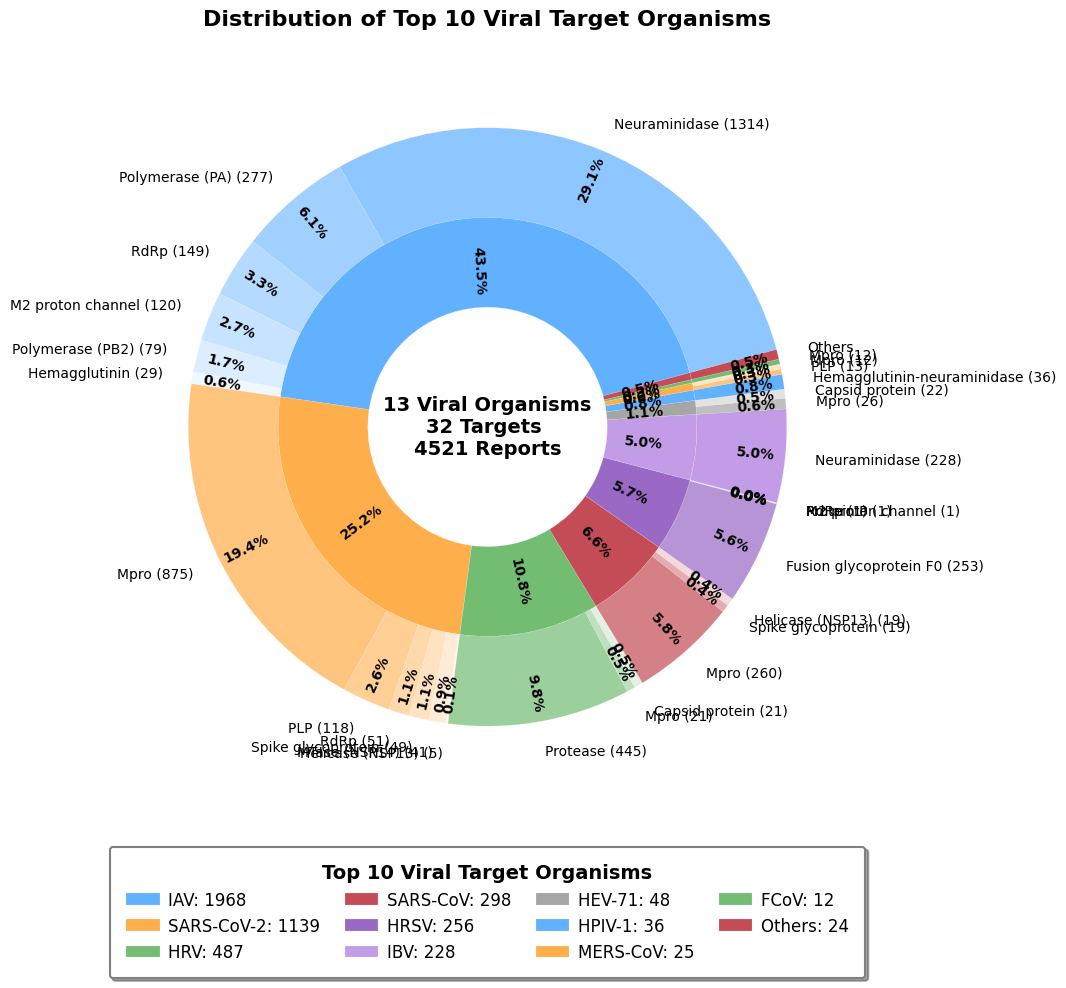

In [ ]:
subplots_mosaic(report_counts_FocusedOnResp,'count',
                top=10,
                colors=["#1E90FF", "#FF8C00",
                        "#38a138", "#ac0010",
                       "#6e2aad", "#aa73dd"],
                other_color="#808080",)

##Figure 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba, to_rgb
from matplotlib.patches import ConnectionPatch

def add_alpha(color, alpha):
    rgba = to_rgba(color)
    return rgba[:3] + (alpha,)

def create_color_gradient(base_color, n):
    """
    Made a list of colors from the base color to white.
    """
    if n == 1:
        return [base_color]
    base_rgb = np.array(to_rgb(base_color))
    white_rgb = np.array([1, 1, 1])
    colors = [base_rgb + (white_rgb - base_rgb) * i / (n - 0.2) for i in range(n)]
    return [tuple(color) + (0.5,) for color in colors]

def subplots_mosaic(dataframe, count_column, top=10, colors=None,
                    label_positions=None, bar_chart_activate=True, other_color="#808080"):
    if colors is None:
        colors = ["#1E90FF", "#75b3f0", "#FF8C00", "#eca753", "#246724", "#38a138", "#ac0010", "#d33b48", "#6e2aad", "#aa73dd"]

    colors_rgba = [add_alpha(color, 0.7) for color in colors]
    other_color_rgba = add_alpha(other_color, 0.7)

    top_n = dataframe.groupby('acronym')[count_column].sum().nlargest(top).reset_index()
    other = dataframe[~dataframe['acronym'].isin(top_n['acronym'])]
    other_sum = other[count_column].sum()

    if other_sum > 0:
        other_row = pd.DataFrame({'acronym': ['Others'], count_column: [other_sum]})
        top_n = pd.concat([top_n, other_row], ignore_index=True)
        colors_rgba.append(other_color_rgba)

    fig, ax = plt.subplots(figsize=(15, 10))

    wedges, texts, autotexts = ax.pie(top_n[count_column], radius=0.7,
                                      wedgeprops=dict(width=0.3, linewidth=0.1, edgecolor='white'),
                                      startangle=15, colors=colors_rgba, autopct=lambda pct: f'{pct:.1f}%', pctdistance=0.75)

    for autotext, wedge in zip(autotexts, wedges):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        rotation = np.rad2deg(np.arctan2(y, x))
        if x < 0:
            rotation += 180
        autotext.set_rotation(rotation)
        autotext.set_fontsize(8.5)

        autotext.set_color('black')
        autotext.set_weight('semibold')

         target_text = autotext.get_text().split()[0]
        for w, t in zip(wedges, texts):
            if t.get_text().startswith(target_text):
                mid_rad = (w.theta2 - w.theta1) / 2.0 + w.theta1
                x = 1.1 * w.r * np.cos(np.deg2rad(mid_rad))
                y = 1.1 * w.r * np.sin(np.deg2rad(mid_rad))
                con = ConnectionPatch(xyA=(-0.4, 0), coordsA=ax.transData,
                                      xyB=(x, y), coordsB=ax.transData, arrowstyle="->", color="black")
                ax.add_artist(con)
                t.set_position((x, y))
                t.set_horizontalalignment('center')
                t.set_verticalalignment('center')
                t.set_color('black')
                t.set_fontsize(10)
                t.set_weight('semibold')

    total_reports = top_n[count_column].sum()
    total_viral_organisms = len(dataframe['main_organism'].unique())
    total_viral_targets = len(dataframe['target'])

    ax.text(0, 0, f'{total_viral_organisms} Viral Organisms\n{total_viral_targets} Targets \n{total_reports} Reports',
            ha='center', va='center', fontsize=14, weight='semibold', color='black')
    ax.set_title(f"Distribution of Viral Target Organisms", pad=20, fontsize=16, weight='bold')

    legend_labels_top_n = [f'{acronym}: {count}' if acronym != 'Others' else f'{acronym}: {other_sum}' for acronym,
                           count in zip(top_n['acronym'], top_n[count_column])]
    legend = ax.legend(wedges, legend_labels_top_n, title=f"Simbology",
                       loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize=12,
                       frameon=True, fancybox=True, shadow=True, handletextpad=0.5, borderpad=1, columnspacing=1.5)
    legend.get_frame().set_linewidth(1.5)
    legend.get_frame().set_edgecolor('gray')
    legend.get_title().set_fontsize(12)
    legend.get_title().set_weight('bold')

    outer_data, outer_labels, outer_colors = [], [], []
    for i, row in top_n.iterrows():
        organism = row['acronym']
        if organism != 'Others':
            target_data = dataframe[dataframe['acronym'] == organism]
            gradient_colors = create_color_gradient(colors_rgba[i % len(colors_rgba)], len(target_data))
            for j, (target, count) in enumerate(zip(target_data['target'], target_data[count_column])):
                outer_data.append(count)
                outer_labels.append(f"{target} ({count})")
                outer_colors.append(gradient_colors[j])
        else:
            outer_data.append(other_sum)
            outer_labels.append('Others')
            outer_colors.append(colors_rgba[i % len(colors_rgba)])

     if len(outer_labels) != len(outer_data):
        raise ValueError("Número incorrecto de etiquetas exteriores")

    wedges2, texts2, autotexts2 = ax.pie(outer_data, radius=1, labels=outer_labels,
                                         colors=outer_colors,
                                         wedgeprops=dict(width=0.3, linewidth=0.1, edgecolor='white'),
                                         startangle=15,
                                         rotatelabels=False,
                                         labeldistance=1.1, pctdistance=0.85,
                                         autopct=lambda pct: f'{pct:.1f}%')

     labels_outer = ax.texts[len(wedges):]  # Texts corresponding to outer labels
     if label_positions:
        for label in labels_outer:
            text = label.get_text()
            if text in label_positions:
                position = label_positions[text]
                if position == 'none':
                    label.set_color('none')
                else:
                    label.set_position(position)

     for autotext, wedge in zip(autotexts2, wedges2):
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        rotation = np.rad2deg(np.arctan2(y, x))
        if x < 0:
            rotation += 180
        autotext.set_rotation(rotation)
        autotext.set_color('black')
        autotext.set_weight('semibold')
        autotext.set_fontsize(8.5)

    plt.tight_layout()
    plt.show()
    return plt


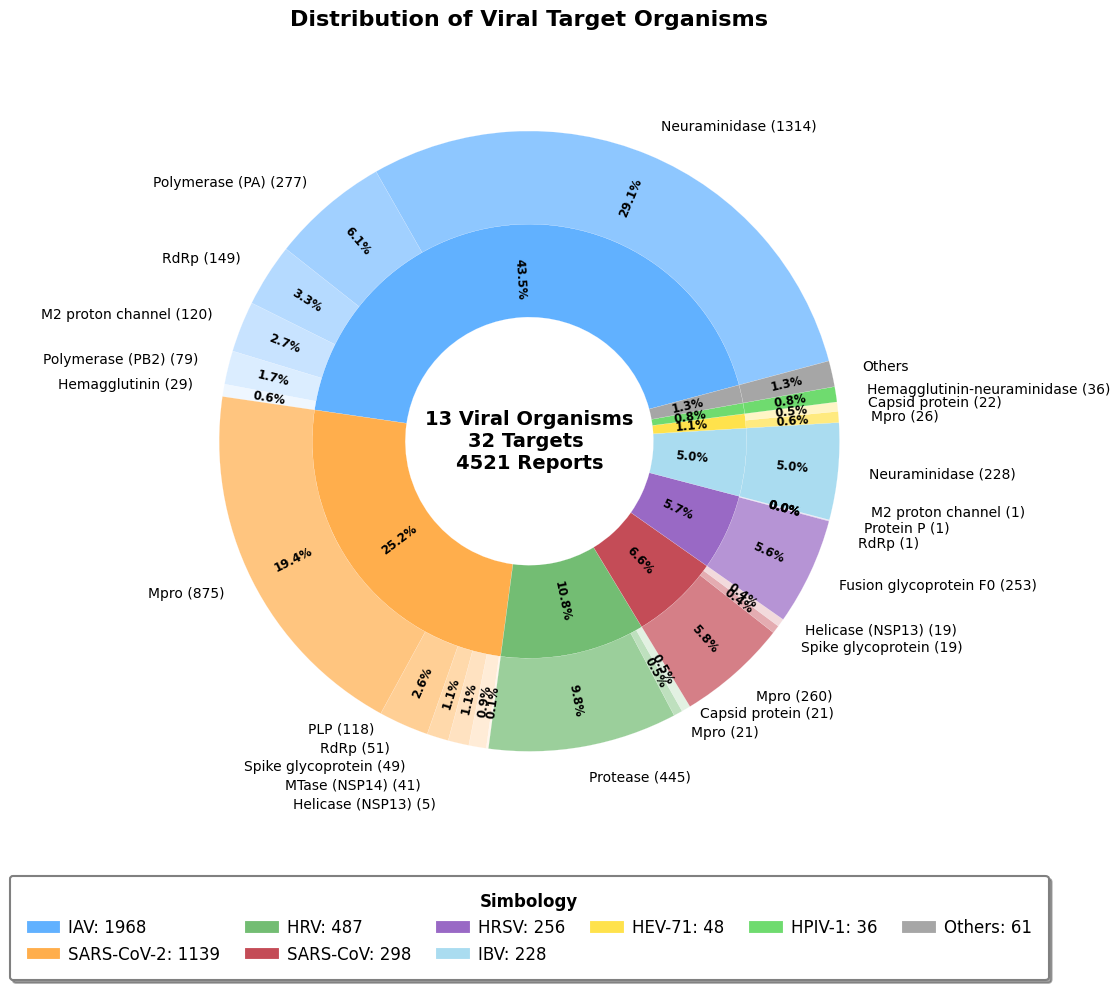

<Figure size 640x480 with 0 Axes>

In [ ]:
label_positions = {
        'PLP (118)': (-0.5, -0.93), #x,y
        'RdRp (51)': (-0.45, -0.99),
        'Spike glycoprotein (49)': (-0.4, -1.05),
        'MTase (NSP14) (41)': (-0.35, -1.11),
        'Helicase (NSP13) (5)': (-0.3, -1.17),
        'Mpro (21)': (0.52, -0.94),
        'Capsid protein (21)': (0.55, -0.88),
        'Helicase (NSP13) (19)': (0.89, -0.61),
        'M2 proton channel (1)': (1.10, -0.23),
        'Protein P (1)': (1.08, -0.28),
        'RdRp (1)': (1.06, -0.33),
        'Mpro (26)': (1.10, 0.08),
        '0.6%': 'none'
}
plt = subplots_mosaic(dataframe = report_counts_FocusedOnResp,
                count_column ='count',
                top=8,
                label_positions = label_positions,
                colors = ["#1E90FF", "#FF8C00", "#38a138", "#ac0010","#6e2aad",
                       '#87CEEB','#FFD700',"#32CD32","#808080"],
                other_color="#808080",
                )
plt.savefig('test.pdf', format='pdf', dpi=300.0)
#additional_colors = ["#FFD700", "#FF1493", "#32CD32", "#9370DB", "#FF6347"]

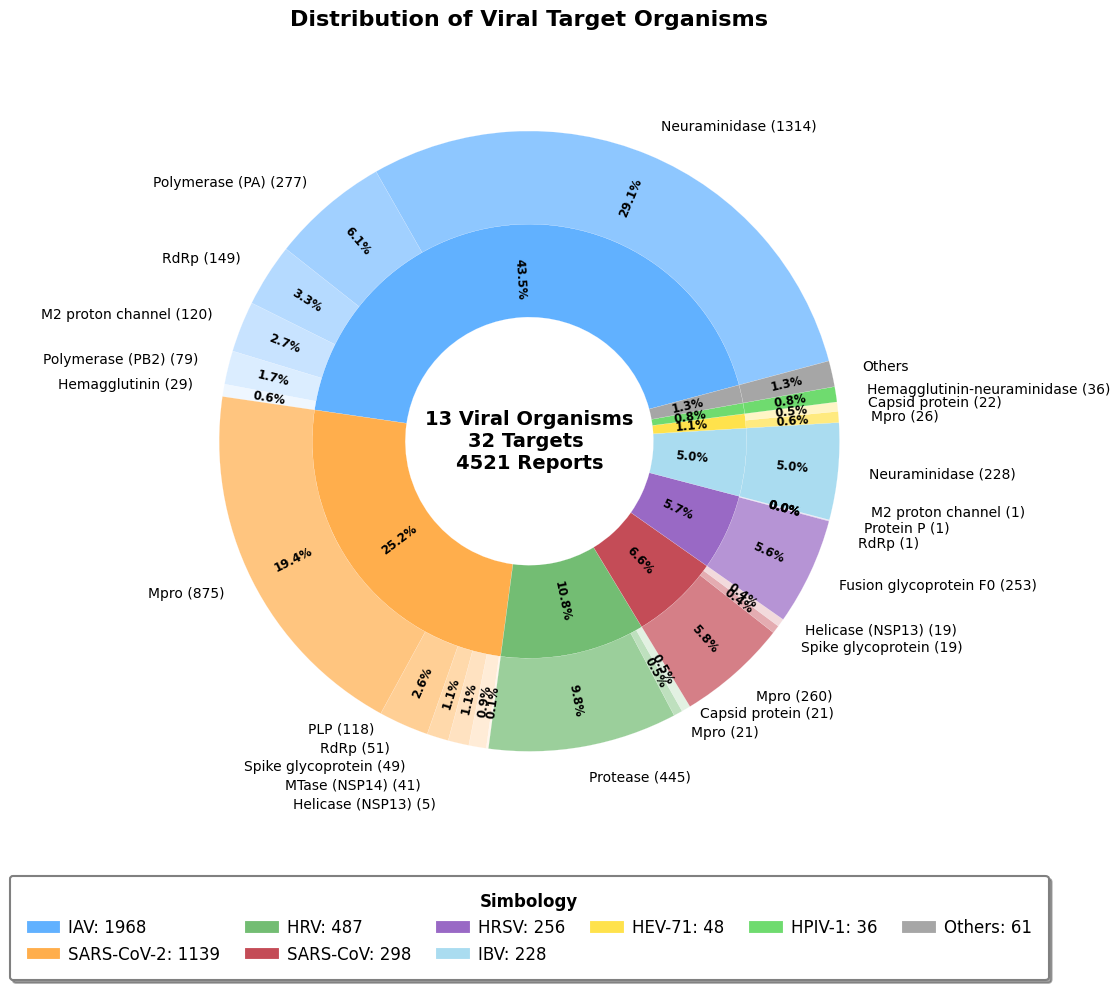

In [ ]:
label_positions = {
        'PLP (118)': (-0.5, -0.93), #x,y
        'RdRp (51)': (-0.45, -0.99),
        'Spike glycoprotein (49)': (-0.4, -1.05),
        'MTase (NSP14) (41)': (-0.35, -1.11),
        'Helicase (NSP13) (5)': (-0.3, -1.17),
        'Mpro (21)': (0.52, -0.94),
        'Capsid protein (21)': (0.55, -0.88),
        'Helicase (NSP13) (19)': (0.89, -0.61),
        'M2 proton channel (1)': (1.10, -0.23),
        'Protein P (1)': (1.08, -0.28),
        'RdRp (1)': (1.06, -0.33),
        'Mpro (26)': (1.10, 0.08),
        '0.6%': 'none'
}
subplots_mosaic(dataframe = report_counts_FocusedOnResp,
                count_column ='count',
                top=8,
                label_positions = label_positions,
                colors = ["#1E90FF", "#FF8C00", "#38a138", "#ac0010","#6e2aad",
                       '#87CEEB','#FFD700',"#32CD32","#808080"],
                other_color="#808080",
                )
#additional_colors = ["#FFD700", "#FF1493", "#32CD32", "#9370DB", "#FF6347"]

<ipython-input-72-b89fdfd98da5>:13: UserWarning: 
The palette list has fewer values (7) than needed (13) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


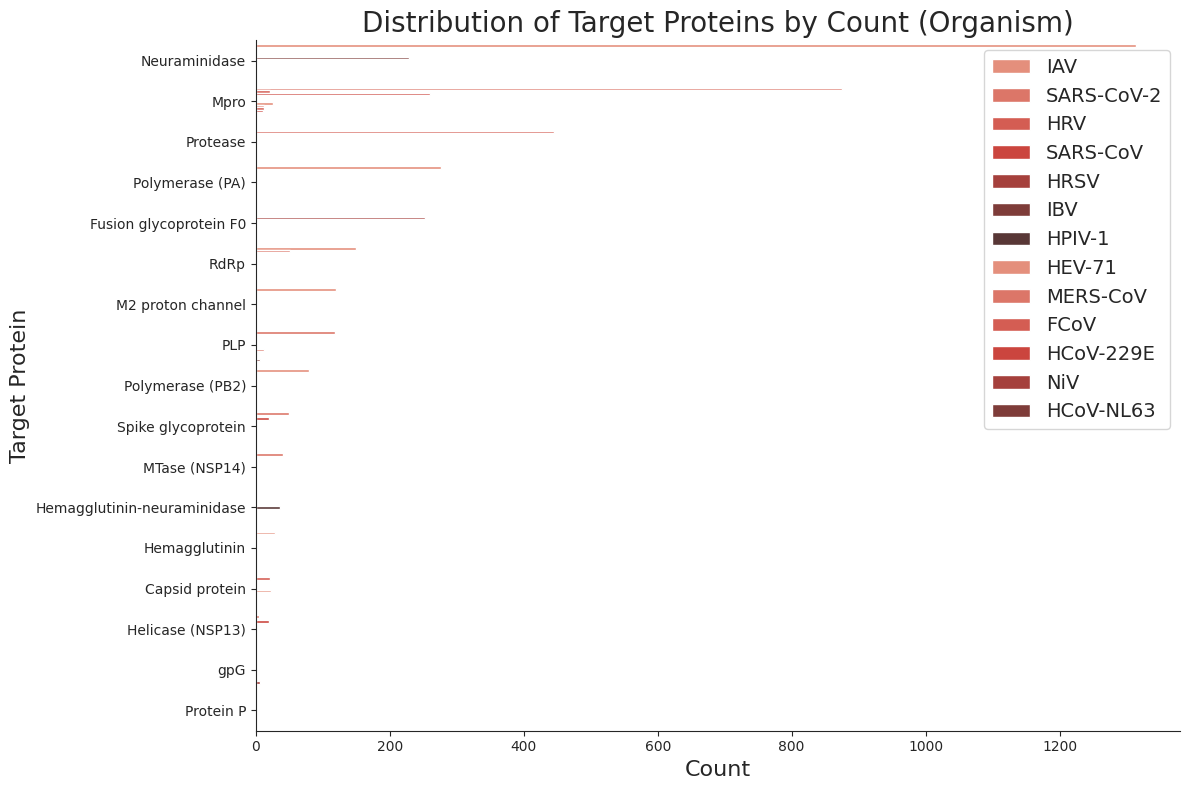

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

title = "Distribution of Target Proteins by Count (Organism)"

sns.set_style('ticks')
fig, ax = plt.subplots(figsize=(12, 8))

ax = sns.barplot(
    data=report_counts_FocusedOnResp,
    x="count",  # X-axis should represent count
    y="target",  # Y-axis should represent target names (categorical)
    hue="acronym",  # Color based on organism
    palette=sns.color_palette("Reds_d", n_colors=7, desat=1)
)

ax.set_xlabel("Count", fontsize=16)
ax.set_ylabel("Target Protein", fontsize=16)
ax.set_title(title, fontsize=20)

ax.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.show()